In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import tensorflow as tf
from sklearn.preprocessing import StandardScaler

In [20]:
# Load by file name
R2502_2503 = pd.read_pickle("R2502_2503.pkl")
R2503_2502 = pd.read_pickle("R2503_2502.pkl")
R2503_2504 = pd.read_pickle("R2503_2504.pkl")
R2504_2503 = pd.read_pickle("R2504_2503.pkl")
R2502_2504 = pd.read_pickle("R2502_2504.pkl")
R2504_2502 = pd.read_pickle("R2504_2502.pkl")

F2504 = pd.read_pickle("2504.pkl")

In [21]:
from pathlib import Path

# 1) Does a directory exist?
base = Path("/home/seismic/AxialFetch/MJ03F-B")
print(base, "→", base.exists(), "(dir)" if base.is_dir() else "(not a dir)")

# 2) Does one specific file exist?
f = base / "MJ03F-B2022DIFF-PRESS-15min.txt"
print(f, "→", f.exists())

# 3) Quick sweep over a pattern
for p in base.glob("MJ03F-B*DIFF-PRESS-15min.txt"):
    print("found:", p.name)

/home/seismic/AxialFetch/MJ03F-B → True (dir)
/home/seismic/AxialFetch/MJ03F-B/MJ03F-B2022DIFF-PRESS-15min.txt → True
found: MJ03F-B2023DIFF-PRESS-15min.txt
found: MJ03F-B2022DIFF-PRESS-15min.txt
found: MJ03F-B2021DIFF-PRESS-15min.txt
found: MJ03F-B2020DIFF-PRESS-15min.txt
found: MJ03F-B2019DIFF-PRESS-15min.txt
found: MJ03F-B2018DIFF-PRESS-15min.txt
found: MJ03F-B2017DIFF-PRESS-15min.txt
found: MJ03F-B2024DIFF-PRESS-15min.txt


Rows in df_pressure: 994


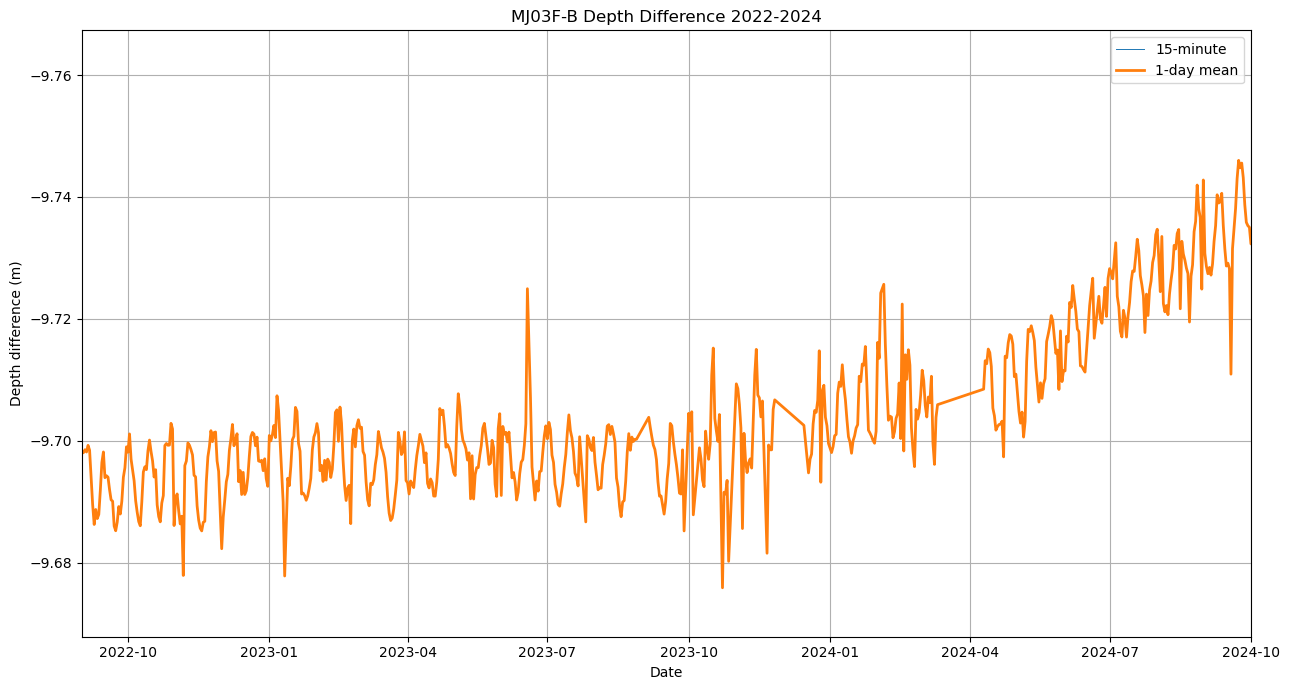

In [22]:
# MJ03F-B depth / pressure processing
# ----------------------------------
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

base_path = Path("/home/seismic/AxialFetch/MJ03F-B")
years     = range(2022, 2025)      # 2022-2024
factor    = 0.67                   # pressure-to-depth conversion

def load_series(years, suffix):
    """Read MJ03F-B DIFF-PRESS files (comma OR whitespace delimited)."""
    frames = []

    for yr in years:
        f = base_path / f"MJ03F-B{yr}DIFF-PRESS-{suffix}.txt"
        if not f.exists():
            continue

        # ---- peek at first line to decide the delimiter -----------------
        with open(f, "r") as fh:
            first_line = fh.readline()

        comma = "," in first_line
        read_opts = dict(
            comment="#",
            engine="python",          # tolerant, handles weird rows
            on_bad_lines="skip"       # silently drop malformed lines
        )

        if comma:
            df = pd.read_csv(f, **read_opts)
            # pick the known columns
            date_col      = df.columns[0]                       # e.g. 'date_1day'
            pressure_col  = (
                "pressure_diff_mean"
                if "pressure_diff_mean" in df.columns
                else df.columns[-1]                             # last numeric col
            )
            df = df[[date_col, pressure_col]]
            df.columns = ["time", "pressure_diff"]
        else:
            # whitespace version: two numeric cols after the date
            df = pd.read_csv(
                f,
                delim_whitespace=True,
                header=None,
                names=["time", "pressure_diff"],
                **read_opts,
            )

        # ---- type conversions & cleanup -------------------------------
        df["time"] = pd.to_datetime(df["time"], format="%Y/%m/%d",
                                    errors="coerce", utc=True)
        df["pressure_diff"] = pd.to_numeric(df["pressure_diff"],
                                            errors="coerce")
        df.dropna(subset=["time", "pressure_diff"], inplace=True)
        frames.append(df)

    if not frames:
        raise FileNotFoundError(f"No DIFF-PRESS-{suffix} data found.")
    return pd.concat(frames, ignore_index=True).sort_values("time")

# ----------------------------------------------------------------------
df_15min = load_series(years, "15min")
df_1day  = load_series(years, "1daymeans")

df_15min["depth_m"] = df_15min["pressure_diff"] * factor
df_1day ["depth_m"] = df_1day ["pressure_diff"] * factor

# minimalist (time, pressure) DF
df_pressure = df_1day[["time", "pressure_diff"]]

print("Rows in df_pressure:", len(df_pressure))   # sanity check

# ----------------------------------------------------------------------
# quick plot
plt.figure(figsize=(13, 7))
plt.plot(df_15min["time"], df_15min["depth_m"],
         label="15-minute", linewidth=0.7)
plt.plot(df_1day["time"],  df_1day["depth_m"],
         label="1-day mean", linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel("Date")
plt.ylabel("Depth difference (m)")
plt.title("MJ03F-B Depth Difference 2022-2024")
plt.xlim(pd.Timestamp(2022, 9, 1, tz="UTC"),
         pd.Timestamp(2024, 10, 1, tz="UTC"))
#plt.ylim(-14.55, -14.45)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

del df_1day

Rows in df_pressure: 994


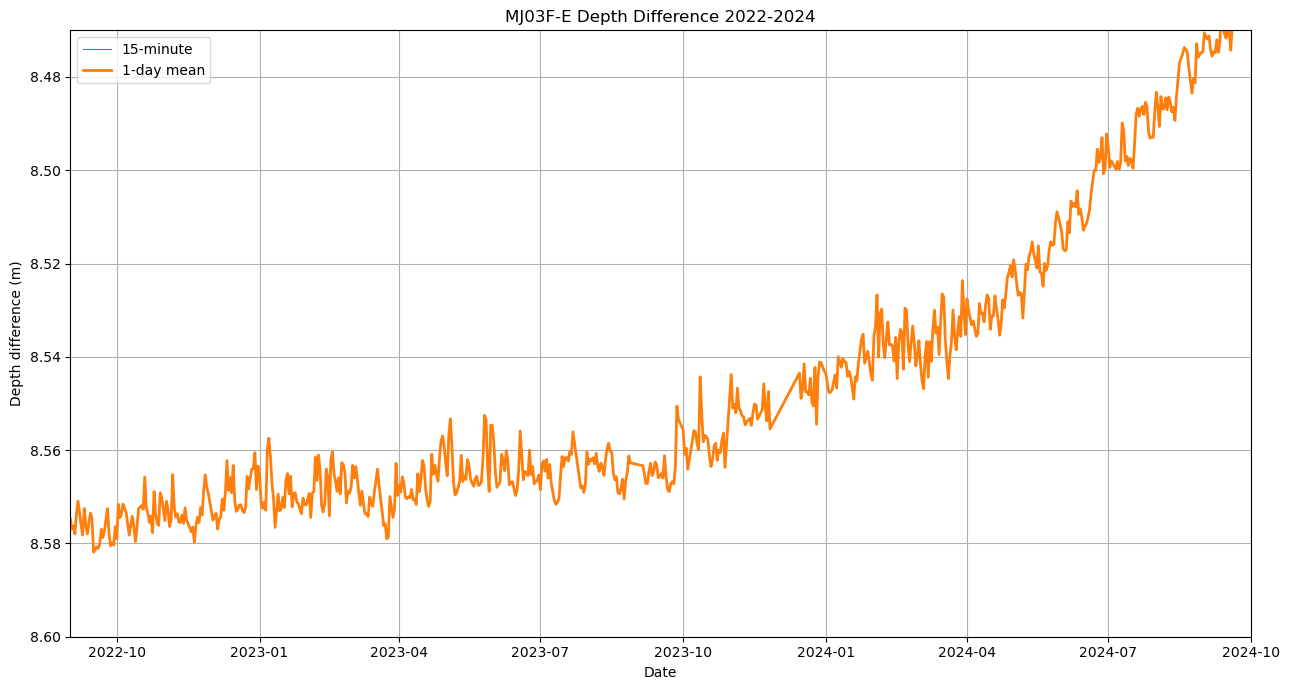

In [23]:
# MJ03F-B depth / pressure processing
# ----------------------------------
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

base_path = Path("/home/seismic/AxialFetch/MJ03F-E")
years     = range(2022, 2025)      # 2022-2024
factor    = 0.67                   # pressure-to-depth conversion

def load_series(years, suffix):
    """Read MJ03F-E DIFF-PRESS files (comma OR whitespace delimited)."""
    frames = []

    for yr in years:
        f = base_path / f"MJ03F-E{yr}DIFF-PRESS-{suffix}.txt"
        if not f.exists():
            continue

        # ---- peek at first line to decide the delimiter -----------------
        with open(f, "r") as fh:
            first_line = fh.readline()

        comma = "," in first_line
        read_opts = dict(
            comment="#",
            engine="python",          # tolerant, handles weird rows
            on_bad_lines="skip"       # silently drop malformed lines
        )

        if comma:
            df = pd.read_csv(f, **read_opts)
            # pick the known columns
            date_col      = df.columns[0]                       # e.g. 'date_1day'
            pressure_col  = (
                "pressure_diff_mean"
                if "pressure_diff_mean" in df.columns
                else df.columns[-1]                             # last numeric col
            )
            df = df[[date_col, pressure_col]]
            df.columns = ["time", "pressure_diff"]
        else:
            # whitespace version: two numeric cols after the date
            df = pd.read_csv(
                f,
                delim_whitespace=True,
                header=None,
                names=["time", "pressure_diff"],
                **read_opts,
            )

        # ---- type conversions & cleanup -------------------------------
        df["time"] = pd.to_datetime(df["time"], format="%Y/%m/%d",
                                    errors="coerce", utc=True)
        df["pressure_diff"] = pd.to_numeric(df["pressure_diff"],
                                            errors="coerce")
        df.dropna(subset=["time", "pressure_diff"], inplace=True)
        frames.append(df)

    if not frames:
        raise FileNotFoundError(f"No DIFF-PRESS-{suffix} data found.")
    return pd.concat(frames, ignore_index=True).sort_values("time")

# ----------------------------------------------------------------------
df_15min = load_series(years, "15min")
df_1day  = load_series(years, "1daymeans")

df_15min["depth_m"] = df_15min["pressure_diff"] * factor
df_1day ["depth_m"] = df_1day ["pressure_diff"] * factor

# minimalist (time, pressure) DF
df_pressure1 = df_1day[["time", "pressure_diff"]]

print("Rows in df_pressure:", len(df_pressure))   # sanity check

# ----------------------------------------------------------------------
# quick plot
plt.figure(figsize=(13, 7))
plt.plot(df_15min["time"], df_15min["depth_m"],
         label="15-minute", linewidth=0.7)
plt.plot(df_1day["time"],  df_1day["depth_m"],
         label="1-day mean", linewidth=2)
plt.gca().invert_yaxis()
plt.xlabel("Date")
plt.ylabel("Depth difference (m)")
plt.title("MJ03F-E Depth Difference 2022-2024")
plt.xlim(pd.Timestamp(2022, 9, 1, tz="UTC"),
         pd.Timestamp(2024, 10, 1, tz="UTC"))
plt.ylim(8.6, 8.47)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [24]:
import pandas as pd

# ------------------------------------------------------------------
# 1) helper → convert any table to a clean UTC-indexed Series
# ------------------------------------------------------------------
def to_series(df, time_col, value_col, fmt=None):
    s = (
        df[[time_col, value_col]]
        .assign(**{time_col: lambda d: pd.to_datetime(
            d[time_col], format=fmt, utc=True)})
        .set_index(time_col)[value_col]
        .astype(float)
        .sort_index()
        .loc[lambda x: ~x.index.duplicated(keep="first")]
    )
    return s

# ------------------------------------------------------------------
# 2) build the master grid from R2503_2504  (distance d1)
# ------------------------------------------------------------------
d1 = to_series(R2503_2502, "Record Time", "Moving Average")

df_var = d1.to_frame("d1")   # index = time, one column so far

# ------------------------------------------------------------------
# 3) prepare the other source series
# ------------------------------------------------------------------
# pressure difference p1 (comes from df_pressure)
p1 = (
    df_pressure.assign(time=pd.to_datetime(df_pressure["time"], utc=True))
               .set_index("time")["pressure_diff"]
               .astype(float)
               .sort_index()
               .loc[lambda x: ~x.index.duplicated(keep="first")]
)

p2 = (
    df_pressure1.assign(time=pd.to_datetime(df_pressure1["time"], utc=True))
               .set_index("time")["pressure_diff"]
               .astype(float)
               .sort_index()
               .loc[lambda x: ~x.index.duplicated(keep="first")]
)

# distance opposite direction d2
d2 = to_series(R2502_2503, "Record Time", "Moving Average")
d3 = to_series(R2502_2504, "Record Time", "Moving Average")
d4 = to_series(R2504_2502, "Record Time", "Moving Average")
d5 = to_series(R2503_2504, "Record Time", "Moving Average")
d6 = to_series(R2504_2503, "Record Time", "Moving Average")

# corrected pressure p2
p3 = to_series(F2504, "DateTime", "Corrected Pressure (kPa)")

In [25]:
# ------------------------------------------------------------------
# 4) interpolate everything onto the master grid
# ------------------------------------------------------------------
def onto_master(source, master_index):
    union = source.reindex(master_index.union(source.index))
    filled = union.interpolate("time")
    return filled.reindex(master_index)

df_var["p1"] = onto_master(p1, df_var.index)
df_var["d2"] = onto_master(d2, df_var.index)
df_var["p2"] = onto_master(p2, df_var.index)
df_var["p3"] = onto_master(p3, df_var.index)
df_var["d3"] = onto_master(d3, df_var.index)
df_var["d4"] = onto_master(d4, df_var.index)
df_var["d5"] = onto_master(d5, df_var.index)
df_var["d6"] = onto_master(d6, df_var.index)

# optional order
df_var = df_var[["p1", "p2", "p3", "d1", "d2", "d3", "d4", "d5", "d6"]]

# reset index so 'time' is a normal column
df_var = df_var.reset_index().rename(columns={"index": "time"})


In [26]:
df_var

,Record Time,p1,p2,p3,d1,d2,d3,d4,d5,d6
0,2022-08-31 16:30:00+00:00,-14.473325,12.798701,NaN,326040.851099,326043.196346,NaN,NaN,NaN,NaN
1,2022-08-31 20:30:00+00:00,-14.474228,12.798320,NaN,326042.074706,326043.122188,NaN,NaN,NaN,NaN
2,2022-09-01 00:30:00+00:00,-14.475012,12.798056,NaN,326042.952243,326043.228790,NaN,NaN,NaN,NaN
3,2022-09-01 04:30:00+00:00,-14.474961,12.798623,NaN,326042.056167,326043.241768,NaN,NaN,NaN,NaN
4,2022-09-01 08:30:00+00:00,-14.474909,12.799189,NaN,326040.257835,326042.430359,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
4378,2024-09-04 04:30:00+00:00,-14.519708,12.644389,15560.114308,326033.502558,326036.154024,164218.532886,164218.675543,176562.927257,176562.287512
4379,2024-09-04 08:30:00+00:00,-14.519395,12.645143,15560.299788,326033.381872,326036.201798,164218.516700,164218.663592,176562.951289,176562.319780
4380,2024-09-04 12:30:00+00:00,-14.519082,12.645898,15560.229376,326033.309222,326036.249573,164218.478109,164218.625528,176562.956069,176562.318533
4381,2024-09-04 16:30:00+00:00,-14.518769,12.646652,15560.194736,326033.322913,326036.285403,164218.462730,164218.607748,176562.848136,176562.212994


In [42]:
# =============================================================================
# PINN RESIDUAL MODEL WITH PRESSURE‐TO‐BASELINE FEATURE ENGINEERING
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, pathlib

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from statsmodels.tsa.seasonal import STL

# -----------------------------------------------------------------------------
# 0) LOAD, FILTER & CLEAN df_var
# -----------------------------------------------------------------------------
df_var = df_var.dropna().reset_index(drop=True)
df_var['Record Time'] = pd.to_datetime(df_var['Record Time'], utc=True)
cutoff = pd.Timestamp(2022, 9, 7, tz='UTC')
df_var = df_var[df_var['Record Time'] >= cutoff].reset_index(drop=True)

# build working DataFrame
df = pd.DataFrame({
    'time': df_var['Record Time'],
    'p1':   df_var['p1'],
    'p2':   df_var['p2'],
    'p3':   df_var['p3'],
    'r_WE': df_var['d1'],
    'r_EW': df_var['d2'],
    'r_EC': df_var['d3'],
    'r_CE': df_var['d4'],
    'r_WC': df_var['d5'],
    'r_CW': df_var['d6'],
})
Y_cols = ['r_WE','r_EW','r_WC','r_CW','r_CE','r_EC']

# -----------------------------------------------------------------------------
# 1) TREND + STL SEASONAL DECOMPOSITION
# -----------------------------------------------------------------------------
t0 = df['time'].min()
df['t_days'] = (df['time'] - t0).dt.total_seconds() / 86400.0

trend  = pd.DataFrame(index=df.index, columns=Y_cols, dtype=float)
season = pd.DataFrame(index=df.index, columns=Y_cols, dtype=float)
resid  = pd.DataFrame(index=df.index, columns=Y_cols, dtype=float)

for name in Y_cols:
    # linear trend
    coeffs      = np.polyfit(df['t_days'], df[name], 1)
    trend[name] = np.polyval(coeffs, df['t_days'])
    # STL seasonal (approx. monthly)
    detr        = df[name] - trend[name]
    stl         = STL(detr, period=int(365/12), robust=True).fit()
    season[name] = stl.seasonal
    resid[name]  = stl.resid

# -----------------------------------------------------------------------------
# 2) FEATURE ENGINEERING (incl. your pressure‐to‐baseline hints)
# -----------------------------------------------------------------------------
df_feat = df.copy()
# attach residual targets
for name in Y_cols:
    df_feat[f"{name}_resid"] = resid[name]

# seasonal phase
omega = 2 * np.pi / 365.25
df_feat['sin1'] = np.sin(omega * df_feat['t_days'])
df_feat['cos1'] = np.cos(omega * df_feat['t_days'])

# lags of pressures
for lag in (1,2,3):
    for p in ['p1','p2','p3']:
        df_feat[f"{p}_l{lag}"] = df_feat[p].shift(lag)

# your new features: pressure weighted by baseline relevance
df_feat['p2_CE'] = df_feat['p2']
df_feat['p2_EC'] = df_feat['p2']
df_feat['p1_CW'] = df_feat['p1']
df_feat['p1_WE'] = df_feat['p1']
df_feat['p1_EW'] = df_feat['p1']
df_feat['p2_EW'] = df_feat['p2']

# drop any NaNs from lagging
df_feat.dropna(inplace=True)
df_feat.reset_index(drop=True, inplace=True)

# assemble arrays
feature_cols = (
    ['p1','p2','p3','sin1','cos1','t_days']
  + [f"{p}_l{lag}"   for p in ['p1','p2','p3'] for lag in (1,2,3)]
  + ['p2_CE','p2_EC','p1_CW','p1_WE','p1_EW','p2_EW']
)
X_raw       = df_feat[feature_cols].astype('float32').values
y_resid_raw = df_feat[[f"{n}_resid" for n in Y_cols]].astype('float32').values

# align trend/season/full truth
idx          = df_feat.index
y_trend      = trend.loc[idx].values
Y_season     = season.loc[idx].values
Y_true_full  = df.loc[idx, Y_cols].values
t_val        = df_feat['time'].values

# -----------------------------------------------------------------------------
# 3) SCALE & FULL‐SERIES SETUP
# -----------------------------------------------------------------------------
scaler_x = StandardScaler().fit(X_raw)
X        = scaler_x.transform(X_raw)

scaler_y = StandardScaler().fit(y_resid_raw)
y_resid  = scaler_y.transform(y_resid_raw)

# -----------------------------------------------------------------------------
# 4) BUILD & TRAIN PINN
# -----------------------------------------------------------------------------
inputs       = layers.Input(shape=(X.shape[1],))
h            = layers.Dense(128, activation='relu')(inputs)
h            = layers.Dense(64,  activation='relu')(h)
y_resid_pred = layers.Dense(len(Y_cols), activation='linear')(h)

model = models.Model(inputs, y_resid_pred)

def pinn_loss(y_true, y_pred):
    # data fit
    L_mse = K.mean(K.square(y_true - y_pred))
    # symmetry
    CE, EC = y_pred[:,4], y_pred[:,5]
    CW, WC = y_pred[:,3], y_pred[:,2]
    L_sym  = K.mean(K.square(CE-EC) + K.square(CW-WC))
    # derivative closure: ΔR_CE + ΔR_CW ≈ ΔR_EW
    EW_diff = y_pred[1:,1] - y_pred[:-1,1]
    CE_diff = y_pred[1:,4] - y_pred[:-1,4]
    CW_diff = y_pred[1:,3] - y_pred[:-1,3]
    L_clo  = K.mean(K.square(CE_diff + CW_diff - EW_diff))
    # combine
    return 10.0*L_mse + 0.1*L_sym + 0.1*L_clo

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss=pinn_loss)

# train full series as one batch for temporal consistency
model.fit(X, y_resid, epochs=300, batch_size=len(X), verbose=1)

# -----------------------------------------------------------------------------
# 5) PREDICT & RECONSTRUCT FULL SERIES
# -----------------------------------------------------------------------------
resid_pred    = model.predict(X)
Y_pred_full  = y_trend + Y_season + scaler_y.inverse_transform(resid_pred)

# -----------------------------------------------------------------------------
# 6) EVALUATE
# -----------------------------------------------------------------------------
print("Validation metrics (PINN full‐series):")
for i, name in enumerate(Y_cols):
    r2   = r2_score(Y_true_full[:,i], Y_pred_full[:,i])
    rmse = mean_squared_error(Y_true_full[:,i], Y_pred_full[:,i], squared=False)
    print(f"{name}: R²={r2:.3f}, RMSE={rmse:.3f} m")



Epoch 1/300
1/1 [==============================] - 1s 578ms/step - loss: 12.5087
Epoch 2/300
1/1 [==============================] - 0s 5ms/step - loss: 11.6379
Epoch 3/300
1/1 [==============================] - 0s 5ms/step - loss: 11.0181
Epoch 4/300
1/1 [==============================] - 0s 5ms/step - loss: 10.6082
Epoch 5/300
1/1 [==============================] - 0s 6ms/step - loss: 10.3637
Epoch 6/300
1/1 [==============================] - 0s 6ms/step - loss: 10.2302
Epoch 7/300
1/1 [==============================] - 0s 5ms/step - loss: 10.1596
Epoch 8/300
1/1 [==============================] - 0s 5ms/step - loss: 10.1152
Epoch 9/300
1/1 [==============================] - 0s 5ms/step - loss: 10.0791
Epoch 10/300
1/1 [==============================] - 0s 5ms/step - loss: 10.0457
Epoch 11/300
1/1 [==============================] - 0s 4ms/step - loss: 10.0131
Epoch 12/300
1/1 [==============================] - 0s 5ms/step - loss: 9.9814
Epoch 13/300
1/1 [==============================

1/1 [==============================] - 0s 4ms/step - loss: 8.7580
Epoch 105/300
1/1 [==============================] - 0s 4ms/step - loss: 8.7444
Epoch 106/300
1/1 [==============================] - 0s 5ms/step - loss: 8.7313
Epoch 107/300
1/1 [==============================] - 0s 5ms/step - loss: 8.7183
Epoch 108/300
1/1 [==============================] - 0s 5ms/step - loss: 8.7052
Epoch 109/300
1/1 [==============================] - 0s 5ms/step - loss: 8.6916
Epoch 110/300
1/1 [==============================] - 0s 5ms/step - loss: 8.6782
Epoch 111/300
1/1 [==============================] - 0s 5ms/step - loss: 8.6652
Epoch 112/300
1/1 [==============================] - 0s 5ms/step - loss: 8.6522
Epoch 113/300
1/1 [==============================] - 0s 4ms/step - loss: 8.6389
Epoch 114/300
1/1 [==============================] - 0s 5ms/step - loss: 8.6259
Epoch 115/300
1/1 [==============================] - 0s 5ms/step - loss: 8.6129
Epoch 116/300
1/1 [==============================] - 0

1/1 [==============================] - 0s 4ms/step - loss: 7.5023
Epoch 207/300
1/1 [==============================] - 0s 5ms/step - loss: 7.4890
Epoch 208/300
1/1 [==============================] - 0s 4ms/step - loss: 7.4757
Epoch 209/300
1/1 [==============================] - 0s 5ms/step - loss: 7.4644
Epoch 210/300
1/1 [==============================] - 0s 4ms/step - loss: 7.4515
Epoch 211/300
1/1 [==============================] - 0s 5ms/step - loss: 7.4384
Epoch 212/300
1/1 [==============================] - 0s 5ms/step - loss: 7.4263
Epoch 213/300
1/1 [==============================] - 0s 5ms/step - loss: 7.4150
Epoch 214/300
1/1 [==============================] - 0s 4ms/step - loss: 7.4016
Epoch 215/300
1/1 [==============================] - 0s 4ms/step - loss: 7.3887
Epoch 216/300
1/1 [==============================] - 0s 4ms/step - loss: 7.3763
Epoch 217/300
1/1 [==============================] - 0s 5ms/step - loss: 7.3637
Epoch 218/300
1/1 [==============================] - 0

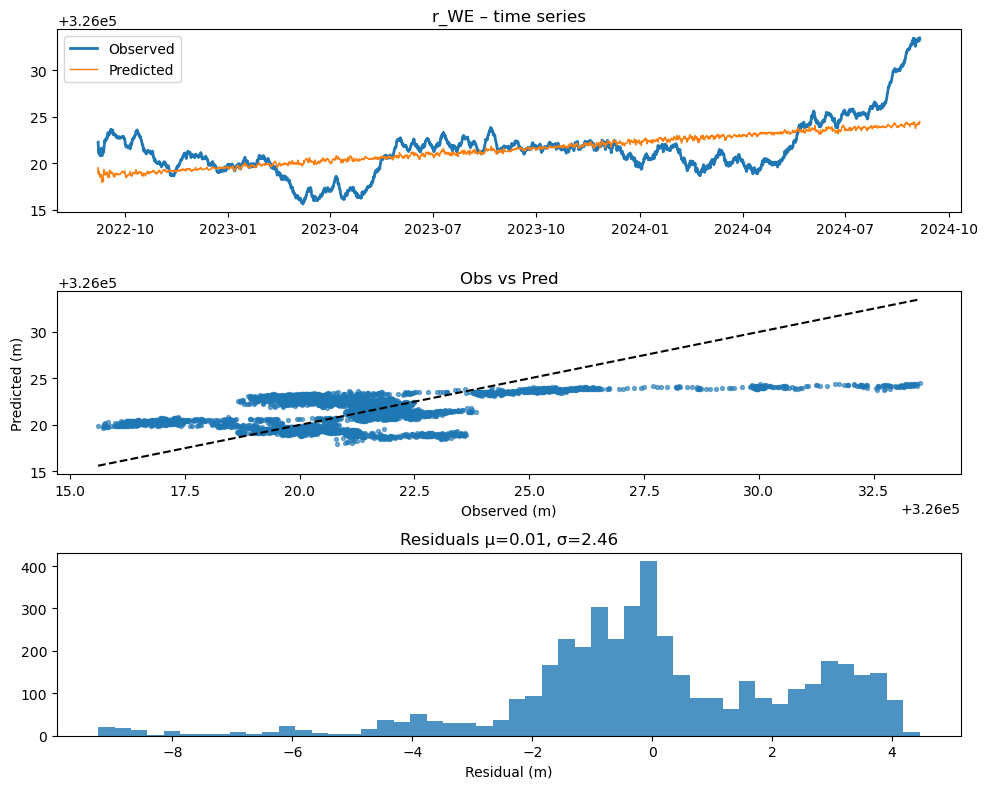

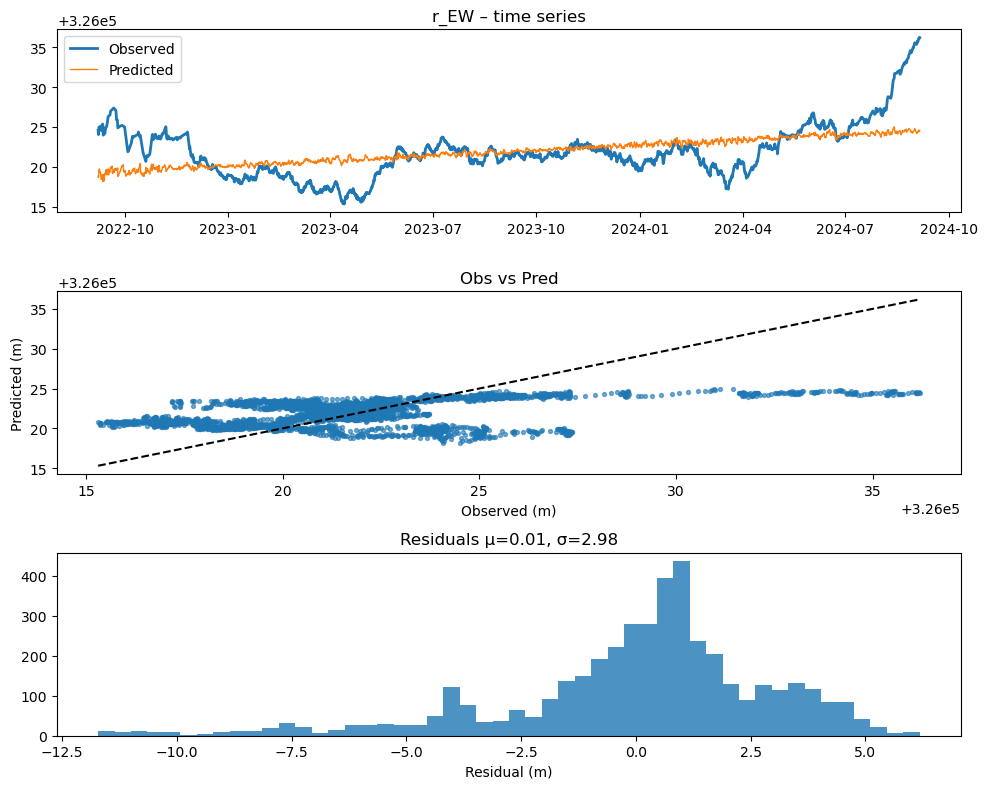

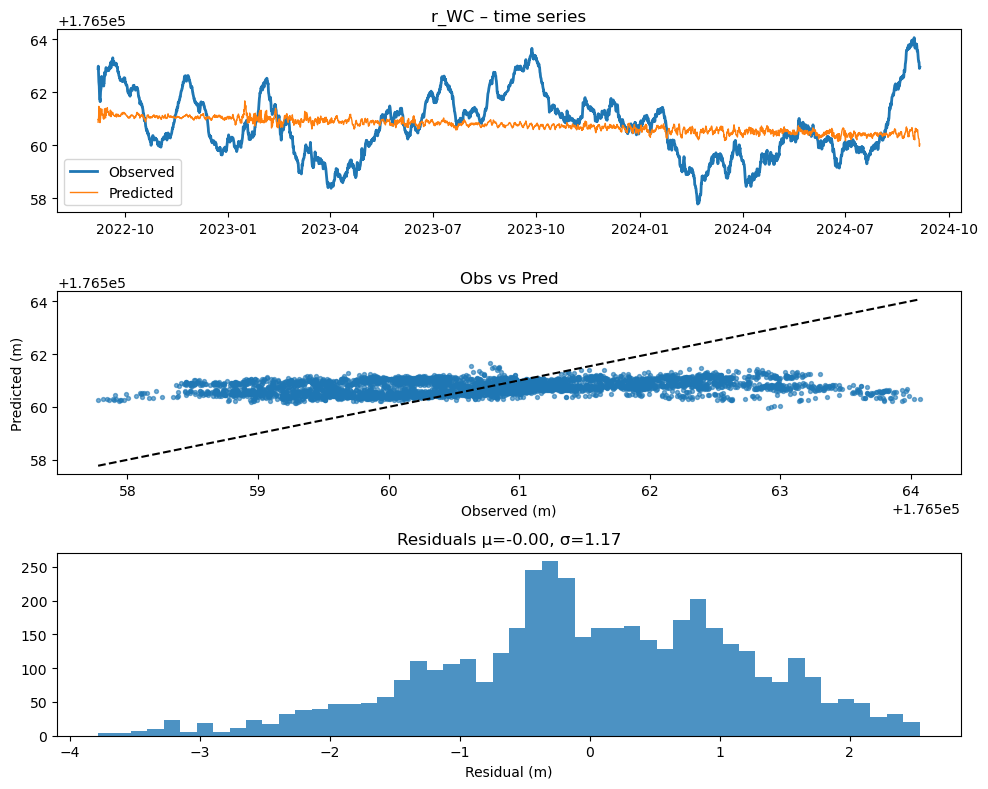

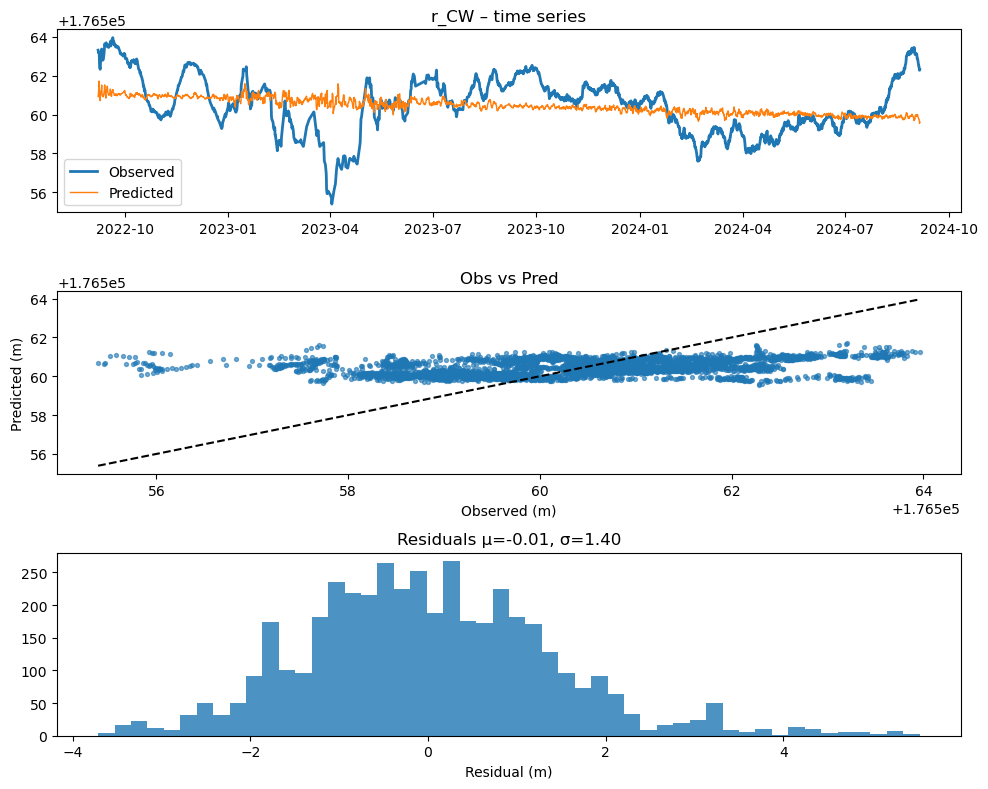

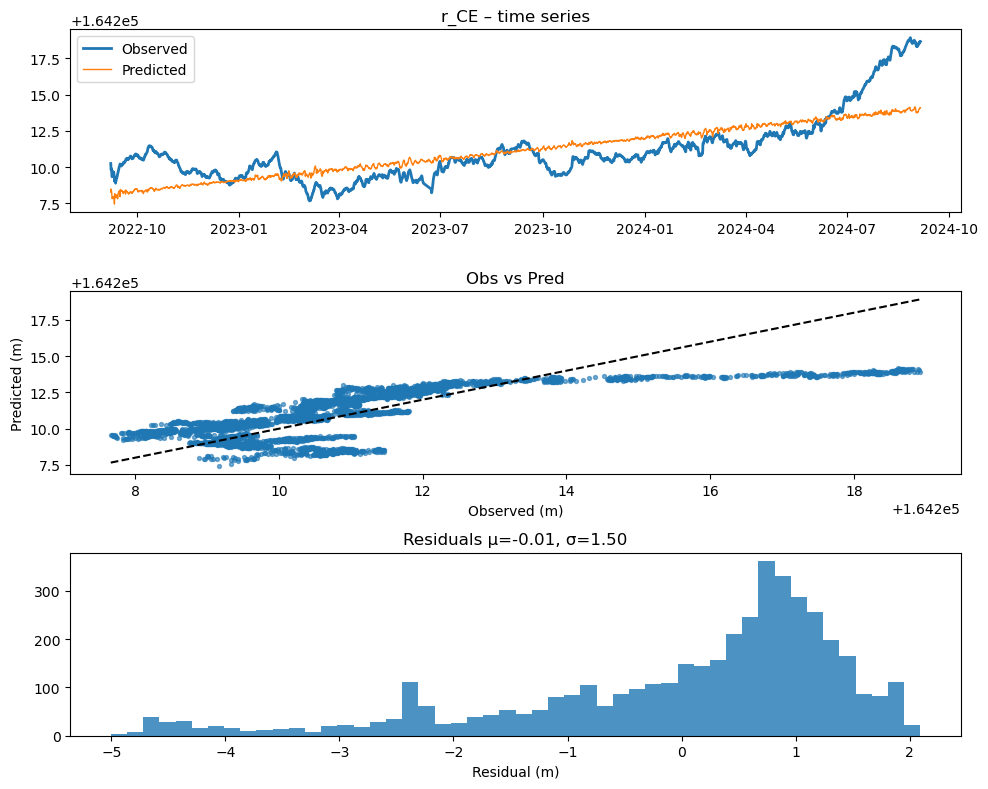

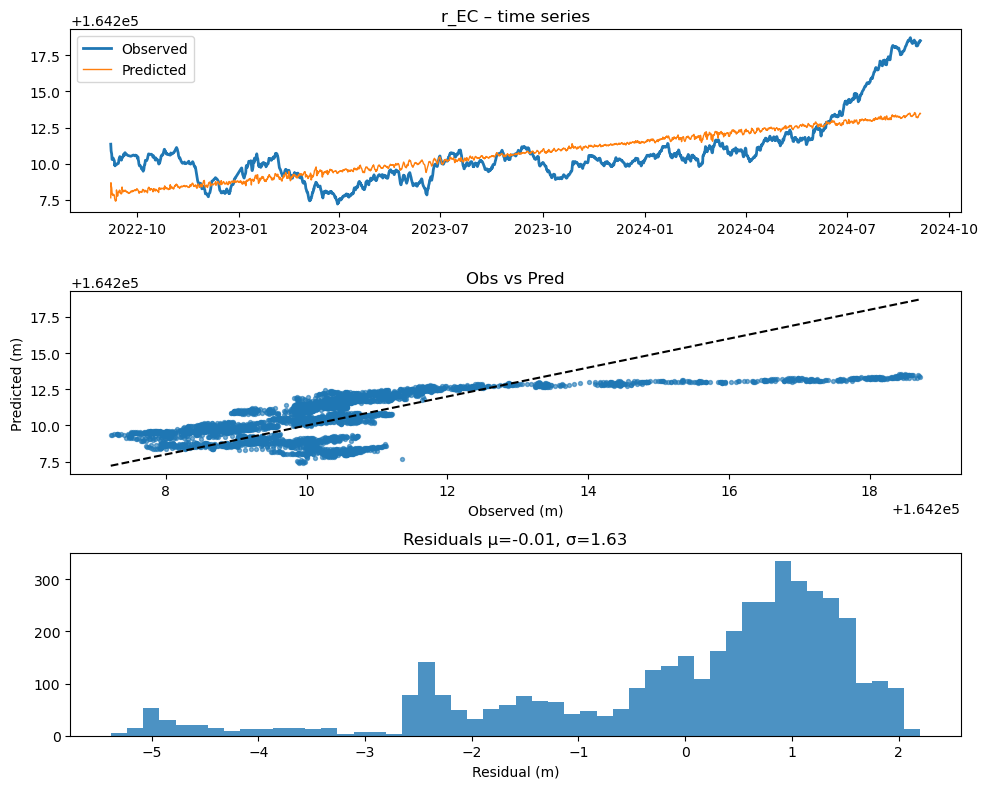

In [43]:
# -----------------------------------------------------------------------------
# 7) VISUALIZATION
# -----------------------------------------------------------------------------
for i, name in enumerate(Y_cols):
    fig, ax = plt.subplots(3,1, figsize=(10,8), tight_layout=True)
    # time series
    ax[0].plot(t_val, Y_true_full[:,i], label='Observed', lw=2)
    ax[0].plot(t_val, Y_pred_full[:,i], label='Predicted', lw=1)
    ax[0].set_title(f"{name} – time series")
    ax[0].legend()
    # scatter
    ax[1].scatter(Y_true_full[:,i], Y_pred_full[:,i], s=8, alpha=0.6)
    mn, mx = Y_true_full[:,i].min(), Y_true_full[:,i].max()
    ax[1].plot([mn,mx], [mn,mx], 'k--')
    ax[1].set_xlabel('Observed (m)')
    ax[1].set_ylabel('Predicted (m)')
    ax[1].set_title('Obs vs Pred')
    # residual histogram
    resid_err = Y_pred_full[:,i] - Y_true_full[:,i]
    ax[2].hist(resid_err, bins=50, alpha=0.8)
    ax[2].set_xlabel('Residual (m)')
    ax[2].set_title(f'Residuals μ={resid_err.mean():.2f}, σ={resid_err.std():.2f}')
    plt.show()




In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, pathlib

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, models, backend as K

# 0) LOAD, FILTER & CLEAN
# -----------------------------------------------------------------------------
df_var = df_var.dropna().reset_index(drop=True)
df_var['Record Time'] = pd.to_datetime(df_var['Record Time'], utc=True)
cutoff = pd.Timestamp(2022,9,7,tz='UTC')
df_var = df_var[df_var['Record Time'] >= cutoff].reset_index(drop=True)

df = pd.DataFrame({
    'time': df_var['Record Time'],
    'p1':   df_var['p1'],
    'p2':   df_var['p2'],
    'p3':   df_var['p3'],
    'r_WE': df_var['d1'],
    'r_EW': df_var['d2'],
    'r_EC': df_var['d3'],
    'r_CE': df_var['d4'],
    'r_WC': df_var['d5'],
    'r_CW': df_var['d6'],
})
Y_cols = ['r_WE','r_EW','r_WC','r_CW','r_CE','r_EC']

# 1) TIME & SEASONAL FEATURES
# -----------------------------------------------------------------------------
t0 = df['time'].min()
t_days = (df['time'] - t0).dt.total_seconds() / 86400.0
ω      = 2*np.pi/365.25
sin_t  = np.sin(ω * t_days)
cos_t  = np.cos(ω * t_days)

# standardized pressures
p1_std = (df['p1'] - df['p1'].mean()) / df['p1'].std()
p2_std = (df['p2'] - df['p2'].mean()) / df['p2'].std()

# 2) LEAST-SQUARES BLOCKS
# -----------------------------------------------------------------------------
# CE/EC depend on p2:
A_CE = np.column_stack([np.ones_like(p2_std), p2_std, sin_t, cos_t])
x_CE, *_ = np.linalg.lstsq(A_CE, df['r_CE'], rcond=None)
x_EC, *_ = np.linalg.lstsq(A_CE, df['r_EC'], rcond=None)
r_CE_lin = A_CE @ x_CE
r_EC_lin = A_CE @ x_EC

# CW/WC depend on p1:
A_CW = np.column_stack([np.ones_like(p1_std), p1_std, sin_t, cos_t])
x_CW, *_ = np.linalg.lstsq(A_CW, df['r_CW'], rcond=None)
x_WC, *_ = np.linalg.lstsq(A_CW, df['r_WC'], rcond=None)
r_CW_lin = A_CW @ x_CW
r_WC_lin = A_CW @ x_WC

# EW/WE depend on both p1 and p2:
A_EW = np.column_stack([np.ones_like(p1_std), p1_std, p2_std, sin_t, cos_t])
x_EW, *_ = np.linalg.lstsq(A_EW, df['r_EW'], rcond=None)
x_WE, *_ = np.linalg.lstsq(A_EW, df['r_WE'], rcond=None)
r_EW_lin = A_EW @ x_EW
r_WE_lin = A_EW @ x_WE

# stack linear predictions in order [WE, EW, WC, CW, CE, EC]
R_lin = np.column_stack([r_WE_lin, r_EW_lin, r_WC_lin,
                         r_CW_lin, r_CE_lin, r_EC_lin])

# 3) RESIDUALS FOR PINN
# -----------------------------------------------------------------------------
R_obs    = df[Y_cols].values.astype('float32')
R_resid  = (R_obs - R_lin).astype('float32')

# features for PINN: p1,p2,p3, sin_t, cos_t, t_days plus lags
df_feat = pd.DataFrame({
    'p1':   df['p1'].values,
    'p2':   df['p2'].values,
    'p3':   df['p3'].values,
    'sin1': sin_t,
    'cos1': cos_t,
    't_days': t_days,
})
# add 3 lags of each
for lag in (1,2,3):
    df_feat[f'p1_l{lag}'] = df_feat['p1'].shift(lag)
    df_feat[f'p2_l{lag}'] = df_feat['p2'].shift(lag)
    df_feat[f'p3_l{lag}'] = df_feat['p3'].shift(lag)
df_feat.dropna(inplace=True)
df_feat.reset_index(drop=True, inplace=True)

# align R_resid and R_lin to df_feat
valid_idx = df_feat.index.values
R_resid = R_resid[valid_idx]
R_lin   = R_lin[valid_idx]
R_obs   = R_obs[valid_idx]
times   = df['time'].values[valid_idx]

# 4) SCALE & PREPARE
# -----------------------------------------------------------------------------
feature_cols = list(df_feat.columns)
X_raw  = df_feat.values.astype('float32')
Y_raw  = R_resid            # target residual
Y_lin   = R_lin             # for reconstruction
Y_true  = R_obs             # for final eval

# full‐series fit
scaler_x = StandardScaler().fit(X_raw)
scaler_y = StandardScaler().fit(Y_raw)

X = scaler_x.transform(X_raw)
Y = scaler_y.transform(Y_raw)

# 5) BUILD PINN ON RESIDUALS
# -----------------------------------------------------------------------------
inputs = layers.Input(shape=(X.shape[1],))
h = layers.Dense(128, activation='relu')(inputs)
h = layers.Dense(64,  activation='relu')(h)
resid_pred = layers.Dense(6, activation='linear')(h)

model = models.Model(inputs, resid_pred)

def pinn_loss(rt, rp):
    # data-fit
    L_mse = K.mean(K.square(rt - rp))
    # symmetry on residuals
    CE, EC = rp[:,4], rp[:,5]
    CW, WC = rp[:,3], rp[:,2]
    L_sym = K.mean(K.square(CE-EC) + K.square(CW-WC))
    # derivative closure
    dCE = CE[1:] - CE[:-1]
    dCW = CW[1:] - CW[:-1]
    dEW = rp[1:,1] - rp[:-1,1]
    L_clo = K.mean(K.square(dCE + dCW - dEW))
    # combine
    return 10.0*L_mse + 0.1*L_sym + 0.1*L_clo

model.compile('adam', loss=pinn_loss)

# 6) TRAIN
# -----------------------------------------------------------------------------
model.fit(X, Y, epochs=300, batch_size=len(X), verbose=1)

# 7) PREDICT & RECONSTRUCT FULL RANGES
# -----------------------------------------------------------------------------
resid_pred = model.predict(X)
resid_pred = scaler_y.inverse_transform(resid_pred)
R_pred_full = Y_lin + resid_pred

# 8) EVALUATE
# -----------------------------------------------------------------------------
print("PINN+LS Hybrid — full‐series metrics:")
for i,name in enumerate(Y_cols):
    r2   = r2_score(Y_true[:,i], R_pred_full[:,i])
    rmse = mean_squared_error(Y_true[:,i], R_pred_full[:,i], squared=False)
    print(f"{name}: R²={r2:.3f}, RMSE={rmse:.3f} m")





Epoch 1/300
1/1 [==============================] - 1s 573ms/step - loss: 11.0558
Epoch 2/300
1/1 [==============================] - 0s 5ms/step - loss: 10.5872
Epoch 3/300
1/1 [==============================] - 0s 5ms/step - loss: 10.2401
Epoch 4/300
1/1 [==============================] - 0s 4ms/step - loss: 9.9909
Epoch 5/300
1/1 [==============================] - 0s 5ms/step - loss: 9.8148
Epoch 6/300
1/1 [==============================] - 0s 4ms/step - loss: 9.6876
Epoch 7/300
1/1 [==============================] - 0s 5ms/step - loss: 9.5896
Epoch 8/300
1/1 [==============================] - 0s 5ms/step - loss: 9.5067
Epoch 9/300
1/1 [==============================] - 0s 5ms/step - loss: 9.4264
Epoch 10/300
1/1 [==============================] - 0s 5ms/step - loss: 9.3411
Epoch 11/300
1/1 [==============================] - 0s 6ms/step - loss: 9.2521
Epoch 12/300
1/1 [==============================] - 0s 5ms/step - loss: 9.1623
Epoch 13/300
1/1 [==============================] - 0s 5

1/1 [==============================] - 0s 7ms/step - loss: 4.5578
Epoch 105/300
1/1 [==============================] - 0s 5ms/step - loss: 4.5226
Epoch 106/300
1/1 [==============================] - 0s 4ms/step - loss: 4.4860
Epoch 107/300
1/1 [==============================] - 0s 5ms/step - loss: 4.4499
Epoch 108/300
1/1 [==============================] - 0s 5ms/step - loss: 4.4138
Epoch 109/300
1/1 [==============================] - 0s 4ms/step - loss: 4.3809
Epoch 110/300
1/1 [==============================] - 0s 4ms/step - loss: 4.3466
Epoch 111/300
1/1 [==============================] - 0s 5ms/step - loss: 4.3119
Epoch 112/300
1/1 [==============================] - 0s 4ms/step - loss: 4.2785
Epoch 113/300
1/1 [==============================] - 0s 4ms/step - loss: 4.2444
Epoch 114/300
1/1 [==============================] - 0s 4ms/step - loss: 4.2088
Epoch 115/300
1/1 [==============================] - 0s 5ms/step - loss: 4.1773
Epoch 116/300
1/1 [==============================] - 0

1/1 [==============================] - 0s 4ms/step - loss: 2.5432
Epoch 207/300
1/1 [==============================] - 0s 4ms/step - loss: 2.5318
Epoch 208/300
1/1 [==============================] - 0s 4ms/step - loss: 2.5250
Epoch 209/300
1/1 [==============================] - 0s 4ms/step - loss: 2.5135
Epoch 210/300
1/1 [==============================] - 0s 4ms/step - loss: 2.5052
Epoch 211/300
1/1 [==============================] - 0s 5ms/step - loss: 2.4909
Epoch 212/300
1/1 [==============================] - 0s 4ms/step - loss: 2.4827
Epoch 213/300
1/1 [==============================] - 0s 4ms/step - loss: 2.4712
Epoch 214/300
1/1 [==============================] - 0s 4ms/step - loss: 2.4626
Epoch 215/300
1/1 [==============================] - 0s 4ms/step - loss: 2.4511
Epoch 216/300
1/1 [==============================] - 0s 4ms/step - loss: 2.4422
Epoch 217/300
1/1 [==============================] - 0s 4ms/step - loss: 2.4327
Epoch 218/300
1/1 [==============================] - 0

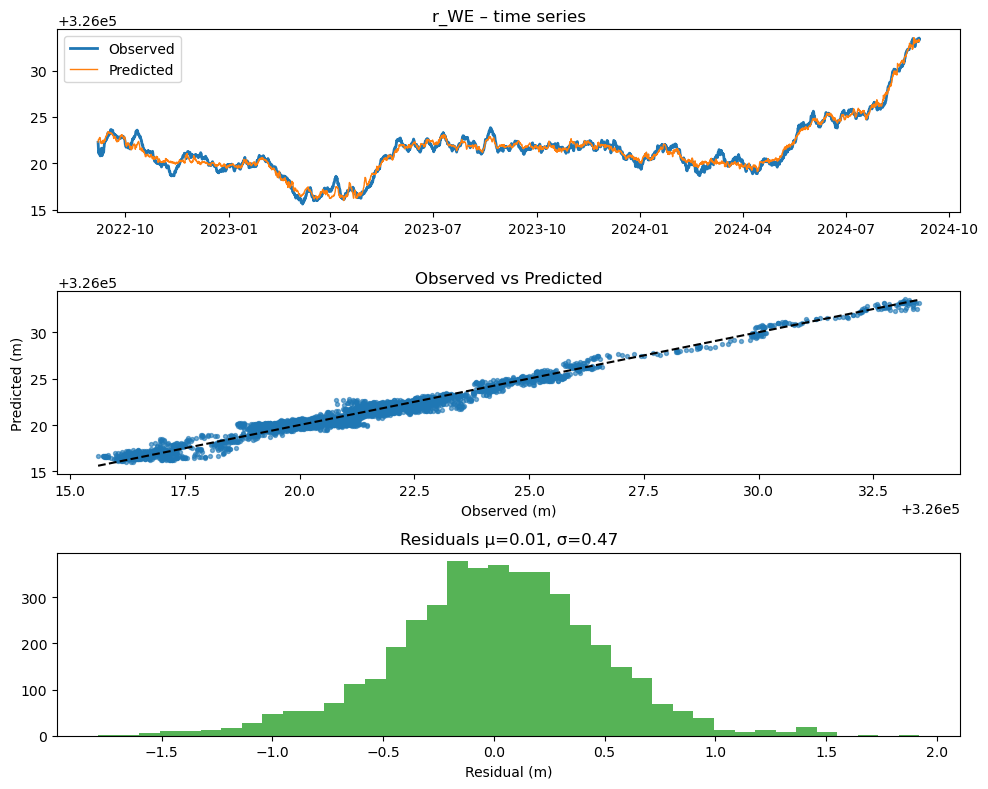

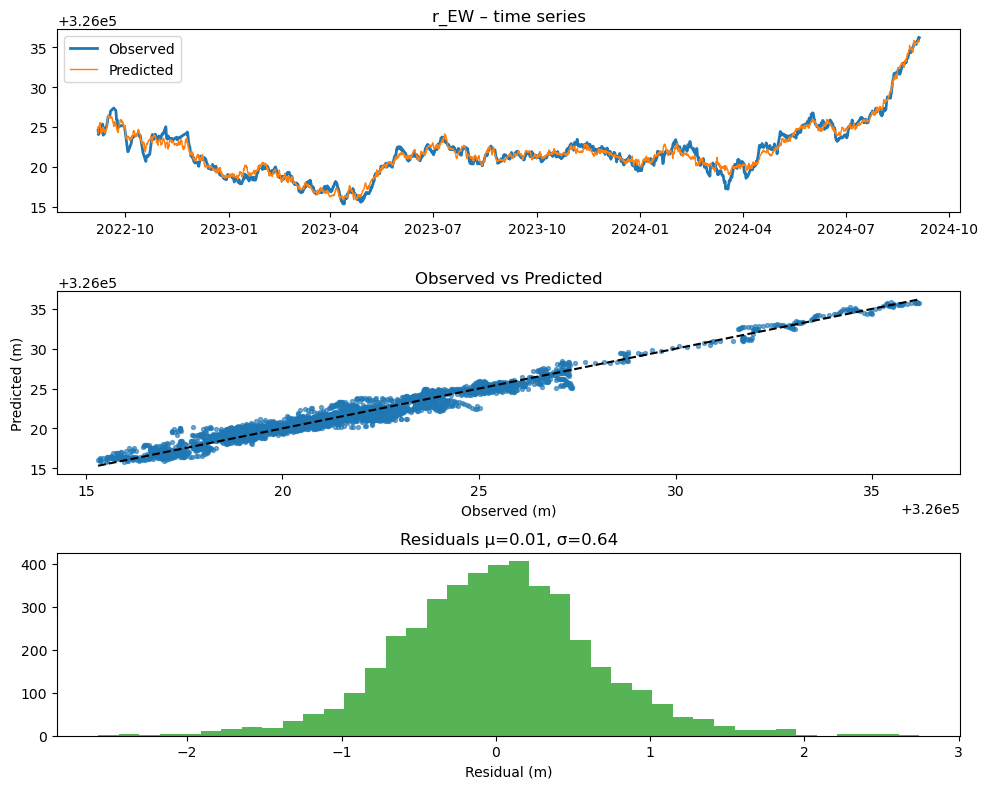

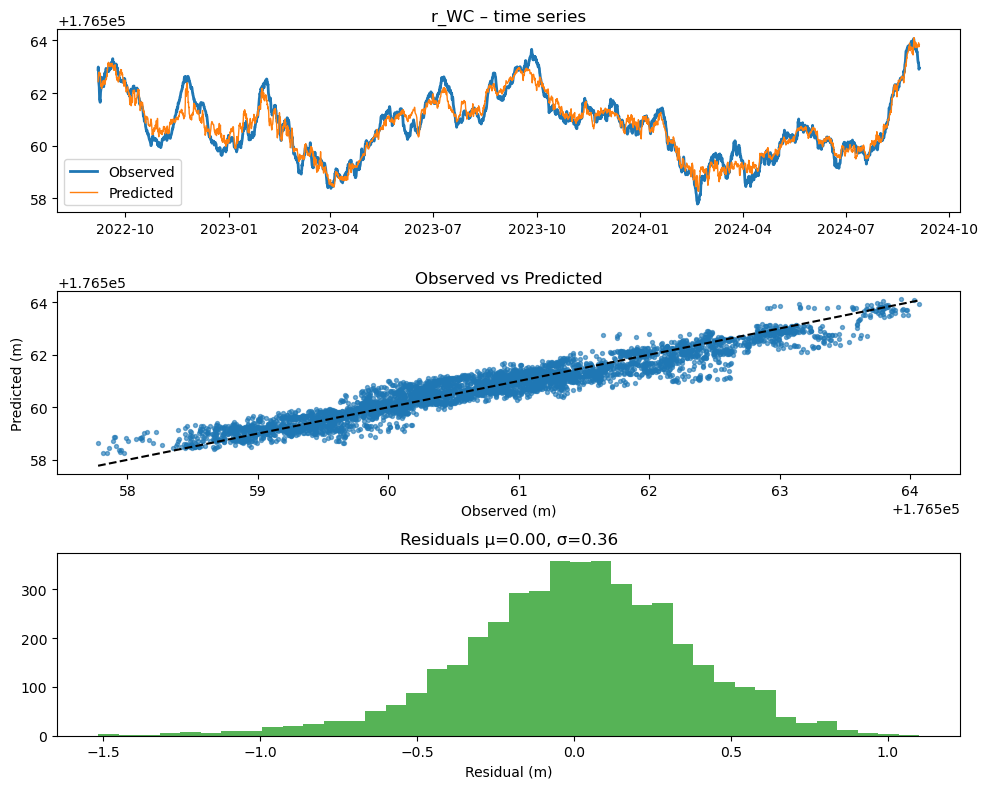

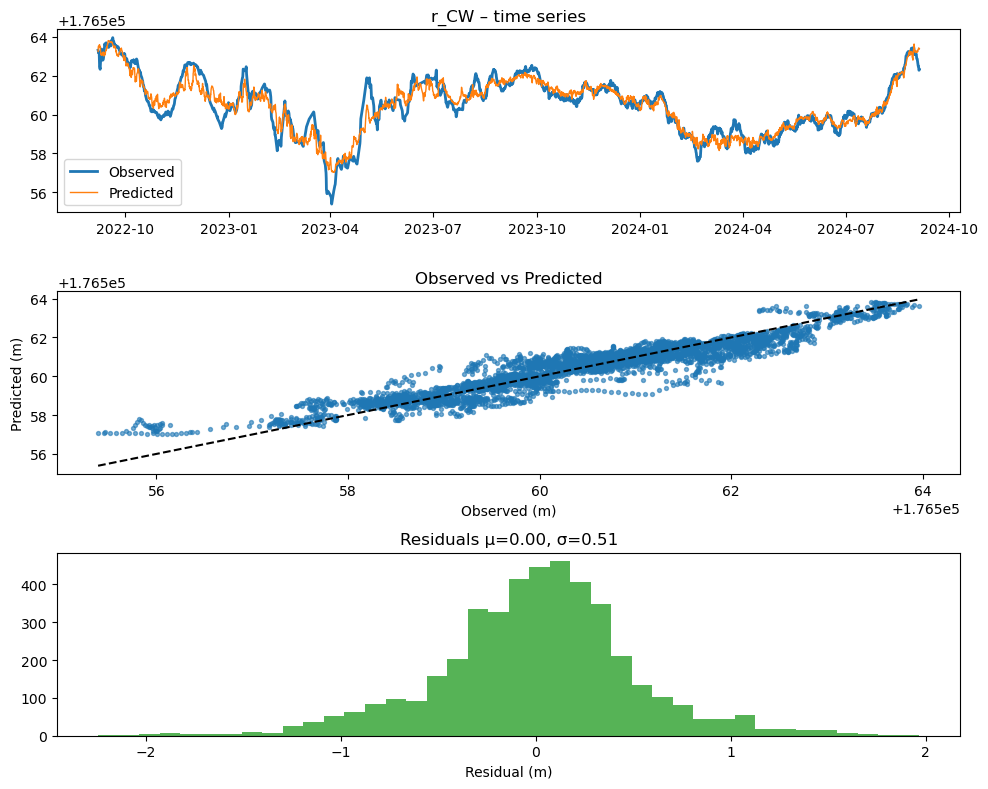

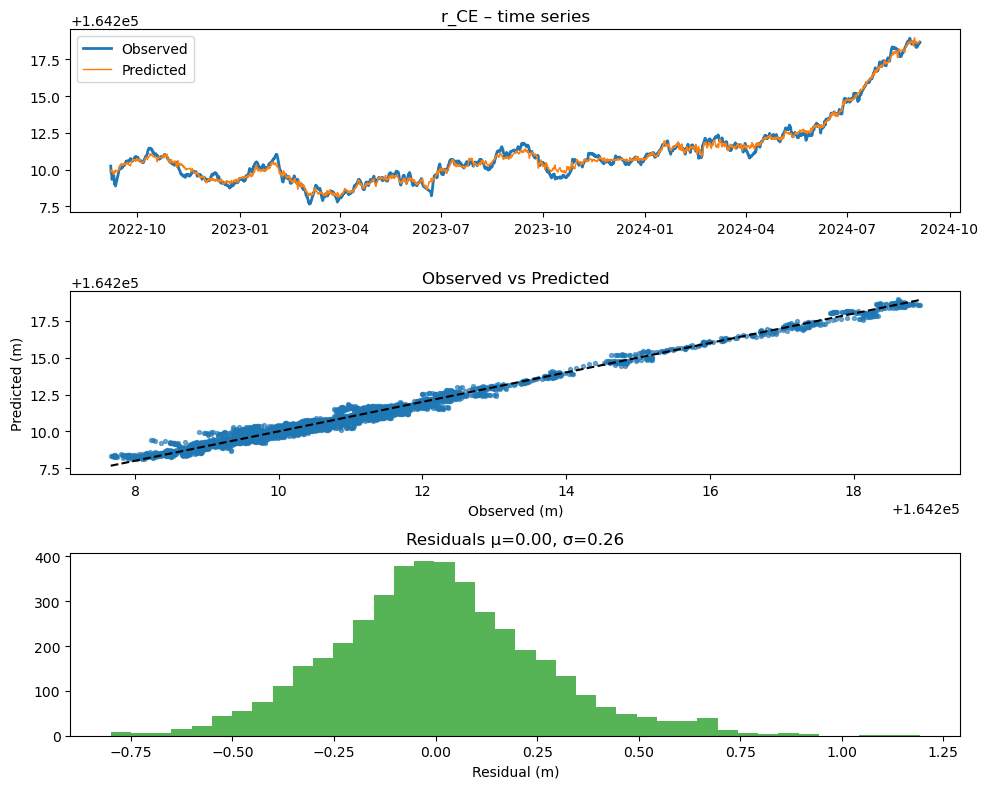

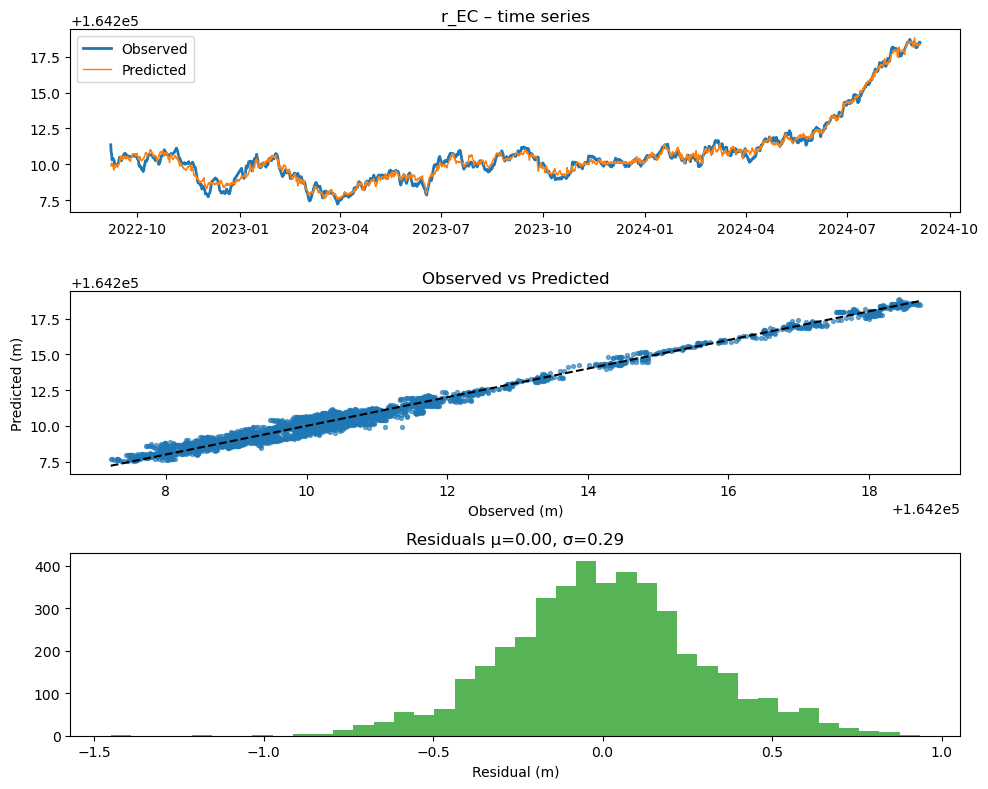

In [45]:
import matplotlib.pyplot as plt

# Make sure you have:
#   times       – 1D array of datetimes
#   Y_true_full – shape (N,6) of the observed ranges
#   R_pred_full – shape (N,6) of the predicted ranges
#   Y_cols      – list of the 6 names in order

for i, name in enumerate(Y_cols):
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), tight_layout=True)

    # 1) time series
    axes[0].plot(times, Y_true_full[:, i],   label='Observed', color='C0', lw=2)
    axes[0].plot(times, R_pred_full[:, i],   label='Predicted', color='C1', lw=1)
    axes[0].set_title(f"{name} – time series")
    axes[0].legend()

    # 2) scatter Obs vs Pred
    axes[1].scatter(Y_true_full[:, i], R_pred_full[:, i], s=8, alpha=0.6, color='C0')
    mn, mx = Y_true_full[:, i].min(), Y_true_full[:, i].max()
    axes[1].plot([mn, mx], [mn, mx], 'k--')
    axes[1].set_xlabel('Observed (m)')
    axes[1].set_ylabel('Predicted (m)')
    axes[1].set_title("Observed vs Predicted")

    # 3) residual histogram
    resid_err = R_pred_full[:, i] - Y_true_full[:, i]
    axes[2].hist(resid_err, bins=40, alpha=0.8, color='C2')
    axes[2].set_xlabel('Residual (m)')
    axes[2].set_title(f"Residuals μ={resid_err.mean():.2f}, σ={resid_err.std():.2f}")

    plt.show()


In [46]:
# =============================================================================
# PURE‐PINN WITH TREND HEAD PRE‐TRAINING & TARGET STANDARDIZATION
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, pathlib

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression

import tensorflow as tf
from tensorflow.keras import layers, models, backend as K

# -----------------------------------------------------------------------------
# 0) LOAD & FILTER DATA
# -----------------------------------------------------------------------------
df_var['Record Time'] = pd.to_datetime(df_var['Record Time'], utc=True)
df_var = df_var.dropna().query("`Record Time` >= '2022-09-07T00:00:00Z'").reset_index(drop=True)

df = pd.DataFrame({
    'time': df_var['Record Time'],
    'p1':   df_var['p1'],
    'p2':   df_var['p2'],
    'p3':   df_var['p3'],
    'r_WE': df_var['d1'],
    'r_EW': df_var['d2'],
    'r_EC': df_var['d3'],
    'r_CE': df_var['d4'],
    'r_WC': df_var['d5'],
    'r_CW': df_var['d6'],
})
Y_cols = ['r_WE','r_EW','r_WC','r_CW','r_CE','r_EC']

# -----------------------------------------------------------------------------
# 1) FEATURE ENGINEERING
# -----------------------------------------------------------------------------
# time & seasonal
t0 = df['time'].min()
df['t_days'] = (df['time'] - t0).dt.total_seconds() / 86400.0
ω = 2*np.pi / 365.25
df['sin1'] = np.sin(ω * df['t_days'])
df['cos1'] = np.cos(ω * df['t_days'])
# baseline‐specific hints
df['p2_CE'] = df['p2']
df['p2_EC'] = df['p2']
df['p1_CW'] = df['p1']
df['p1_WE'] = df['p1']
df['p1_EW'] = df['p1']
df['p2_EW'] = df['p2']

# input matrix
feature_cols = [
    't_days','sin1','cos1',
    'p1','p2','p3',
    'p2_CE','p2_EC','p1_CW','p1_WE','p1_EW','p2_EW'
]
X_raw = df[feature_cols].values.astype('float32')
Y_raw = df[Y_cols].values.astype('float32')
times = df['time'].values

# -----------------------------------------------------------------------------
# 2) STANDARDIZE X & Y
# -----------------------------------------------------------------------------
scaler_X = StandardScaler().fit(X_raw)
Xs       = scaler_X.transform(X_raw)

scaler_Y = StandardScaler().fit(Y_raw)
Ys       = scaler_Y.transform(Y_raw)

# -----------------------------------------------------------------------------
# 3) BUILD PURE‐PINN MODEL
# -----------------------------------------------------------------------------
inp = layers.Input(shape=(Xs.shape[1],))

# Trend head on time features
trend_in   = layers.Lambda(lambda x: x[:, :3])(inp)  # t_days, sin1, cos1
trend_out  = layers.Dense(len(Y_cols), activation='linear', name='trend')(trend_in)

# Residual MLP head
x = layers.Dense(128, activation='relu', name='res1')(inp)
x = layers.Dense(64,  activation='relu', name='res2')(x)
resid_out  = layers.Dense(len(Y_cols), activation='linear', name='resid')(x)

# Sum for full prediction
Y_pred     = layers.Add(name='full')([trend_out, resid_out])
model      = models.Model(inp, Y_pred)

# -----------------------------------------------------------------------------
# 4) PRE‐TRAIN TREND HEAD (Phase 1)
# -----------------------------------------------------------------------------
# freeze residual layers
for layer in model.layers:
    if layer.name not in ('trend',):
        layer.trainable = False

# compile for pure MSE on scaled targets
model.compile(optimizer='adam', loss='mse')
model.fit(Xs, Ys, epochs=50, batch_size=256, verbose=1)

# -----------------------------------------------------------------------------
# 5) JOINT PINN TRAINING (Phase 2)
# -----------------------------------------------------------------------------
# unfreeze all
for layer in model.layers:
    layer.trainable = True

def pinn_loss(y_true, y_pred):
    # MSE on scaled full output
    L_mse = K.mean(K.square(y_true - y_pred))
    # symmetry
    CE, EC = y_pred[:,4], y_pred[:,5]
    CW, WC = y_pred[:,3], y_pred[:,2]
    L_sym  = K.mean(K.square(CE - EC) + K.square(CW - WC))
    # derivative‐closure: ΔCE+ΔCW ≈ ΔEW
    dCE = CE[1:] - CE[:-1]
    dCW = CW[1:] - CW[:-1]
    dEW = y_pred[1:,1] - y_pred[:-1,1]
    L_clo = K.mean(K.square(dCE + dCW - dEW))
    return 1.0*L_mse + 0.01*L_sym + 0.01*L_clo

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4), loss=pinn_loss)
model.fit(Xs, Ys, epochs=200, batch_size=len(Xs), verbose=1)

# -----------------------------------------------------------------------------
# 6) PREDICT & INVERSE‐SCALE
# -----------------------------------------------------------------------------
Ys_hat = model.predict(Xs)
Y_hat  = scaler_Y.inverse_transform(Ys_hat)

# -----------------------------------------------------------------------------
# 7) EVALUATE
# -----------------------------------------------------------------------------
print("\nFinal PINN metrics:")
for i,name in enumerate(Y_cols):
    r2   = r2_score(Y_raw[:,i], Y_hat[:,i])
    rmse = mean_squared_error(Y_raw[:,i], Y_hat[:,i], squared=False)
    print(f"{name}: R²={r2:.3f}, RMSE={rmse:.3f} m")



Epoch 1/50
17/17 [==============================] - 0s 1ms/step - loss: 1.1377
Epoch 2/50
17/17 [==============================] - 0s 1ms/step - loss: 1.0983
Epoch 3/50
17/17 [==============================] - 0s 947us/step - loss: 1.0612
Epoch 4/50
17/17 [==============================] - 0s 1ms/step - loss: 1.0263
Epoch 5/50
17/17 [==============================] - 0s 984us/step - loss: 0.9936
Epoch 6/50
17/17 [==============================] - 0s 964us/step - loss: 0.9628
Epoch 7/50
17/17 [==============================] - 0s 1ms/step - loss: 0.9338
Epoch 8/50
17/17 [==============================] - 0s 1ms/step - loss: 0.9063
Epoch 9/50
17/17 [==============================] - 0s 1ms/step - loss: 0.8802
Epoch 10/50
17/17 [==============================] - 0s 1ms/step - loss: 0.8557
Epoch 11/50
17/17 [==============================] - 0s 1ms/step - loss: 0.8323
Epoch 12/50
17/17 [==============================] - 0s 1ms/step - loss: 0.8101
Epoch 13/50
17/17 [========================

1/1 [==============================] - 0s 4ms/step - loss: 0.3237
Epoch 55/200
1/1 [==============================] - 0s 4ms/step - loss: 0.3224
Epoch 56/200
1/1 [==============================] - 0s 5ms/step - loss: 0.3211
Epoch 57/200
1/1 [==============================] - 0s 4ms/step - loss: 0.3199
Epoch 58/200
1/1 [==============================] - 0s 4ms/step - loss: 0.3185
Epoch 59/200
1/1 [==============================] - 0s 4ms/step - loss: 0.3172
Epoch 60/200
1/1 [==============================] - 0s 4ms/step - loss: 0.3159
Epoch 61/200
1/1 [==============================] - 0s 4ms/step - loss: 0.3147
Epoch 62/200
1/1 [==============================] - 0s 4ms/step - loss: 0.3135
Epoch 63/200
1/1 [==============================] - 0s 4ms/step - loss: 0.3122
Epoch 64/200
1/1 [==============================] - 0s 4ms/step - loss: 0.3110
Epoch 65/200
1/1 [==============================] - 0s 5ms/step - loss: 0.3098
Epoch 66/200
1/1 [==============================] - 0s 4ms/step -

1/1 [==============================] - 0s 4ms/step - loss: 0.2353
Epoch 158/200
1/1 [==============================] - 0s 4ms/step - loss: 0.2348
Epoch 159/200
1/1 [==============================] - 0s 4ms/step - loss: 0.2343
Epoch 160/200
1/1 [==============================] - 0s 5ms/step - loss: 0.2338
Epoch 161/200
1/1 [==============================] - 0s 5ms/step - loss: 0.2333
Epoch 162/200
1/1 [==============================] - 0s 4ms/step - loss: 0.2328
Epoch 163/200
1/1 [==============================] - 0s 4ms/step - loss: 0.2324
Epoch 164/200
1/1 [==============================] - 0s 4ms/step - loss: 0.2318
Epoch 165/200
1/1 [==============================] - 0s 4ms/step - loss: 0.2313
Epoch 166/200
1/1 [==============================] - 0s 5ms/step - loss: 0.2308
Epoch 167/200
1/1 [==============================] - 0s 4ms/step - loss: 0.2304
Epoch 168/200
1/1 [==============================] - 0s 4ms/step - loss: 0.2299
Epoch 169/200
1/1 [==============================] - 0

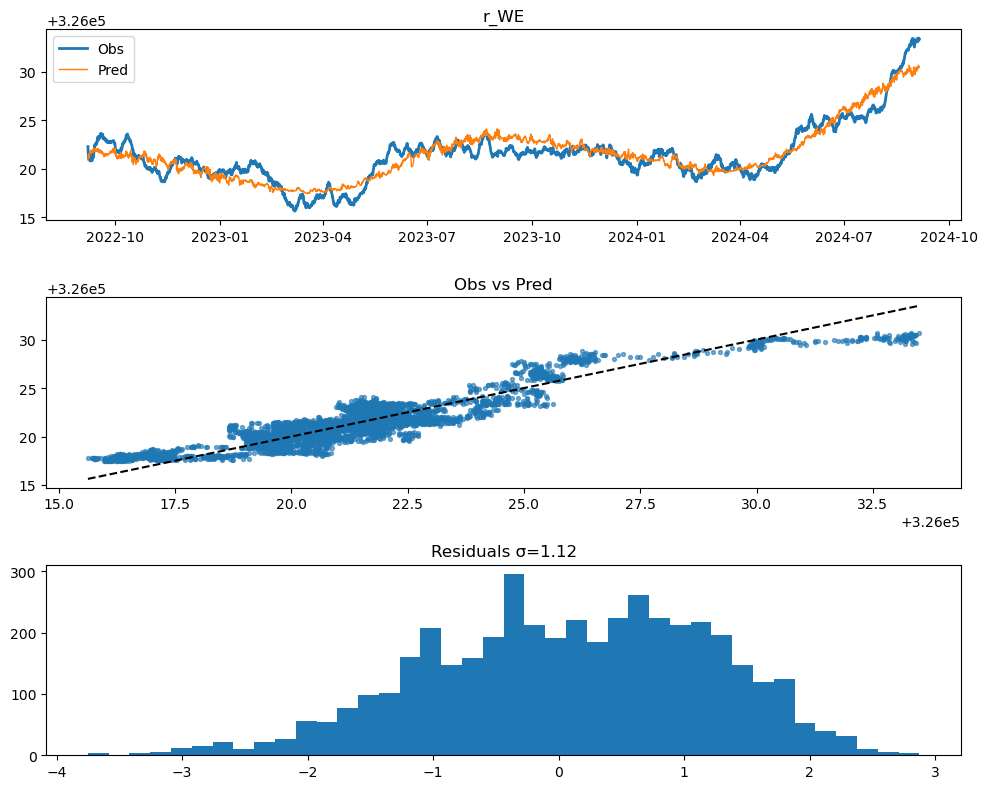

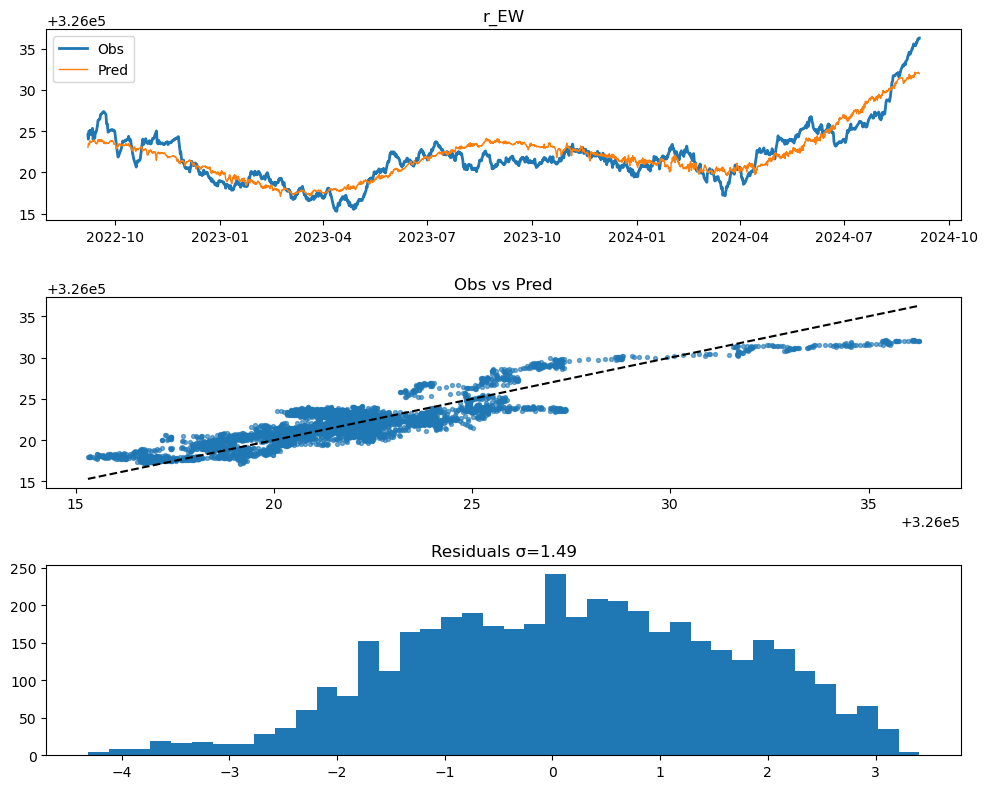

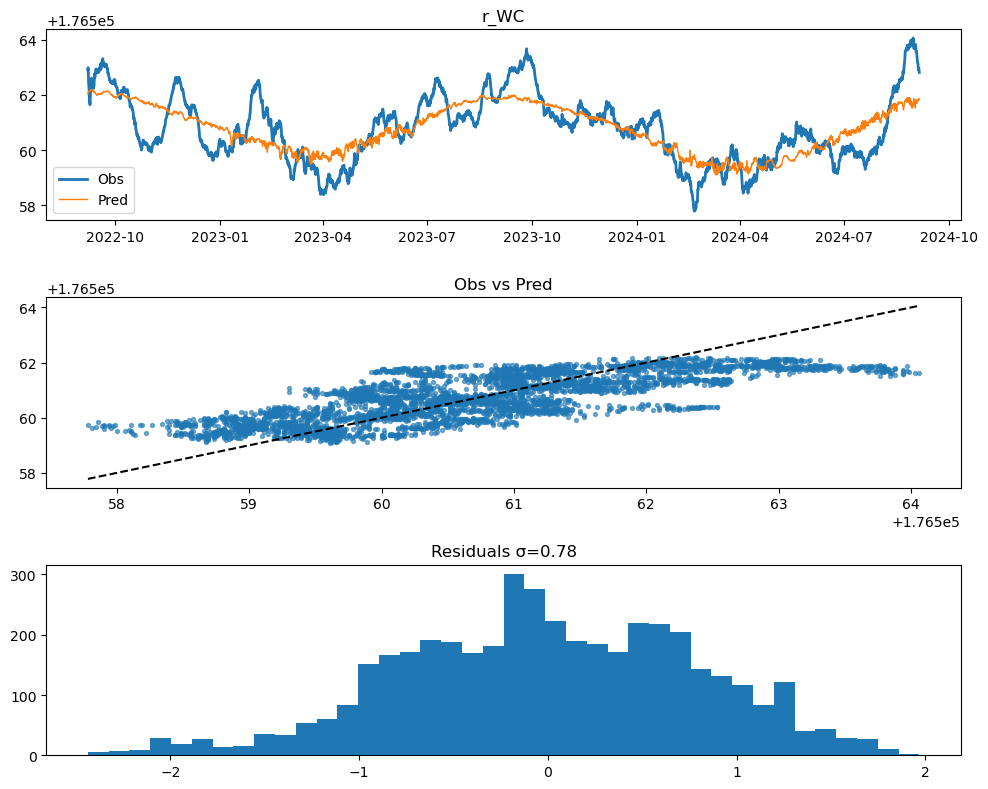

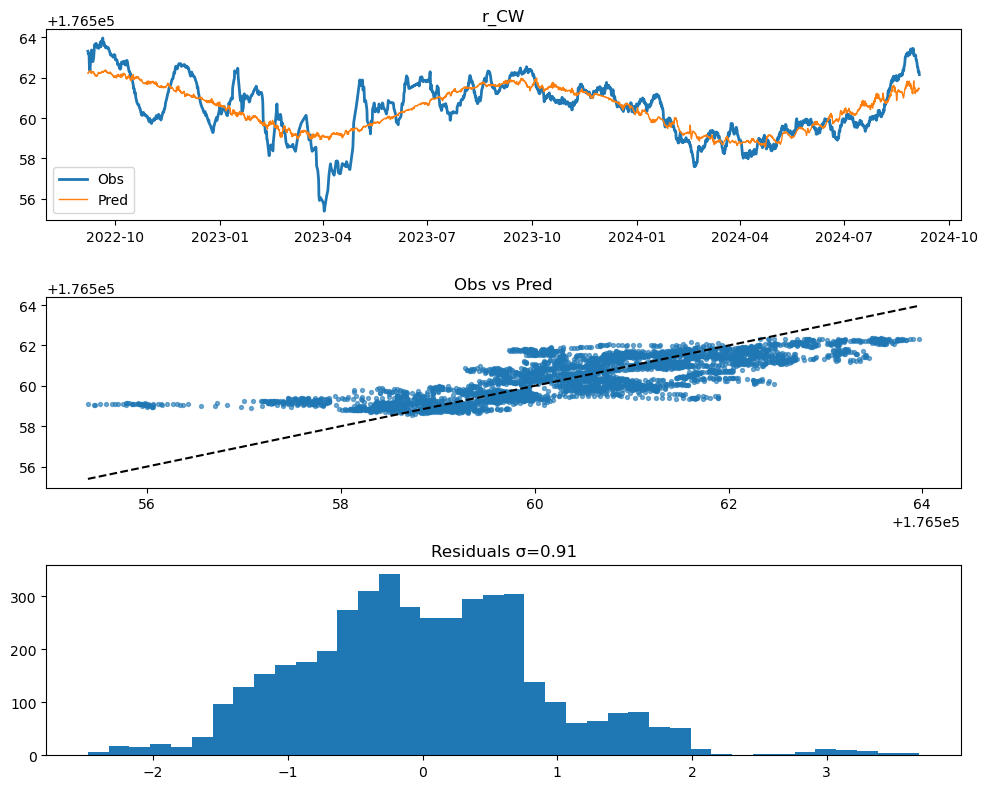

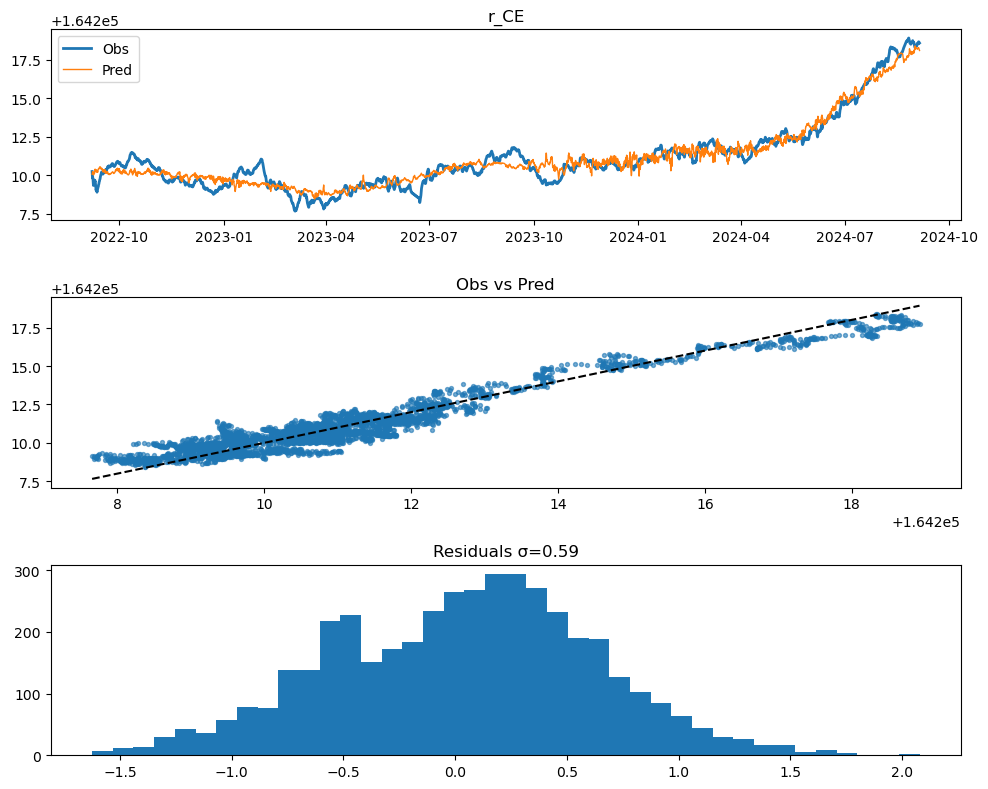

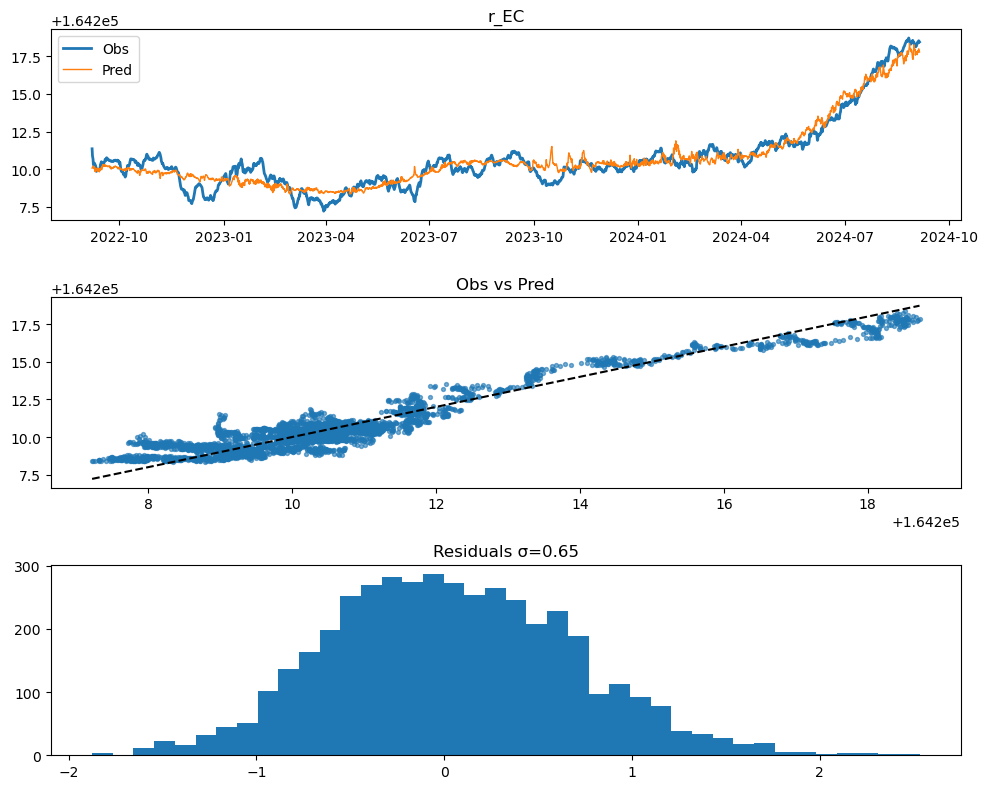

In [47]:
# -----------------------------------------------------------------------------
# 8) VISUALIZE
# -----------------------------------------------------------------------------
for i,name in enumerate(Y_cols):
    fig, ax = plt.subplots(3,1, figsize=(10,8), tight_layout=True)
    ax[0].plot(times, Y_raw[:,i],   label='Obs', lw=2)
    ax[0].plot(times, Y_hat[:,i],   label='Pred', lw=1)
    ax[0].set_title(name); ax[0].legend()
    ax[1].scatter(Y_raw[:,i], Y_hat[:,i], s=8, alpha=0.6)
    mn, mx = Y_raw[:,i].min(), Y_raw[:,i].max()
    ax[1].plot([mn,mx],[mn,mx],'k--'); ax[1].set_title("Obs vs Pred")
    resid_err = Y_hat[:,i] - Y_raw[:,i]
    ax[2].hist(resid_err, bins=40); ax[2].set_title(f"Residuals σ={resid_err.std():.2f}")
    plt.show()



In [55]:
# =============================================================================
# ENHANCED PURE‐PINN WITH INTERACTIONS, SMOOTHNESS, DROPOUT & EARLY STOPPING
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, pathlib

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression

import tensorflow as tf
from tensorflow.keras import layers, models, backend as K, callbacks

# -----------------------------------------------------------------------------
# 0) LOAD & FILTER DATA
# -----------------------------------------------------------------------------
df_var['Record Time'] = pd.to_datetime(df_var['Record Time'], utc=True)
df_var = (
    df_var
    .dropna(subset=['p1','p2','p3','d1','d2','d3','d4','d5','d6'])
    .loc[lambda d: d['Record Time'] >= '2022-09-07T00:00:00Z']
    .reset_index(drop=True)
)

df = pd.DataFrame({
    'time': df_var['Record Time'],
    'p1':   df_var['p1'],
    'p2':   df_var['p2'],
    'p3':   df_var['p3'],
    'r_WE': df_var['d1'],
    'r_EW': df_var['d2'],
    'r_EC': df_var['d3'],
    'r_CE': df_var['d4'],
    'r_WC': df_var['d5'],
    'r_CW': df_var['d6'],
})
Y_cols = ['r_WE','r_EW','r_WC','r_CW','r_CE','r_EC']

# -----------------------------------------------------------------------------
# 1) FEATURE ENGINEERING
# -----------------------------------------------------------------------------
# time & season
t0 = df['time'].min()
df['t_days'] = (df['time'] - t0).dt.total_seconds() / 86400.0
ω = 2 * np.pi / 365.25
df['sin1'] = np.sin(ω * df['t_days'])
df['cos1'] = np.cos(ω * df['t_days'])

# baseline-specific hints
df['p2_CE'] = df['p2']
df['p2_EC'] = df['p2']
df['p1_CW'] = df['p1']
df['p1_WE'] = df['p1']
df['p1_EW'] = df['p1']
df['p2_EW'] = df['p2']

# pressure–season interactions
df['p1_sin'] = df['p1'] * df['sin1']
df['p2_sin'] = df['p2'] * df['sin1']
df['p1_cos'] = df['p1'] * df['cos1']
df['p2_cos'] = df['p2'] * df['cos1']
df['p1p2']   = df['p1'] * df['p2']

# lags
for lag in (1,2,3):
    df[f'p1_l{lag}'] = df['p1'].shift(lag)
    df[f'p2_l{lag}'] = df['p2'].shift(lag)
    df[f'p3_l{lag}'] = df['p3'].shift(lag)

# drop any NaN
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

# assemble X, Y
feature_cols = [
    't_days','sin1','cos1',
    'p1','p2','p3',
    'p2_CE','p2_EC','p1_CW','p1_WE','p1_EW','p2_EW',
    'p1_sin','p2_sin','p1_cos','p2_cos','p1p2'
] + [f'{p}_l{lag}' for p in ['p1','p2','p3'] for lag in (1,2,3)]

X_raw = df[feature_cols].values.astype('float32')
Y_raw = df[Y_cols].values.astype('float32')
times = df['time'].values

# -----------------------------------------------------------------------------
# 2) STANDARDIZE X & Y
# -----------------------------------------------------------------------------
scaler_X = StandardScaler().fit(X_raw)
Xs       = scaler_X.transform(X_raw)

scaler_Y = StandardScaler().fit(Y_raw)
Ys       = scaler_Y.transform(Y_raw)

# -----------------------------------------------------------------------------
# 3) BUILD PURE‐PINN MODEL
# -----------------------------------------------------------------------------
inp       = layers.Input(shape=(Xs.shape[1],))
# trend head
trend_in  = layers.Lambda(lambda x: x[:,:3])(inp)  
trend_out = layers.Dense(len(Y_cols), activation='linear', name='trend')(trend_in)

# residual MLP with dropout
x = layers.Dense(256, activation='relu')(inp)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64,  activation='relu')(x)
resid_out = layers.Dense(len(Y_cols), activation='linear', name='resid')(x)

# sum for full prediction
Y_pred    = layers.Add(name='full')([trend_out, resid_out])
model     = models.Model(inp, Y_pred)

# -----------------------------------------------------------------------------
# 4) PRE‐TRAIN TREND HEAD (Phase 1)
# -----------------------------------------------------------------------------
for layer in model.layers:
    if layer.name != 'trend':
        layer.trainable = False

model.compile(optimizer='adam', loss='mse')
model.fit(Xs, Ys, epochs=50, batch_size=256, verbose=1)

# -----------------------------------------------------------------------------
# 5) JOINT PINN TRAINING (Phase 2)
# -----------------------------------------------------------------------------
for layer in model.layers:
    layer.trainable = True

def pinn_loss(y_true, y_pred):
    # data fit on scaled outputs
    L_mse = K.mean(K.square(y_true - y_pred))
    # symmetry
    CE, EC = y_pred[:,4], y_pred[:,5]
    CW, WC = y_pred[:,3], y_pred[:,2]
    L_sym  = K.mean(K.square(CE - EC) + K.square(CW - WC))
    # derivative closure
    dCE    = CE[1:] - CE[:-1]
    dCW    = CW[1:] - CW[:-1]
    dEW    = y_pred[1:,1] - y_pred[:-1,1]
    L_clo  = K.mean(K.square(dCE + dCW - dEW))
    # temporal smoothness (small weight)
    diff2  = y_pred[2:] - 2*y_pred[1:-1] + y_pred[:-2]
    L_smo  = K.mean(K.square(diff2))
    return (1.0   * L_mse
          + 0.01  * L_sym
          + 0.01  * L_clo
          + 0.001 * L_smo)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss=pinn_loss)

# add early stopping
es = callbacks.EarlyStopping(monitor='loss', patience=30, restore_best_weights=True)

model.fit(Xs, Ys, epochs=200, batch_size=len(Xs),
          callbacks=[es], verbose=1)

# -----------------------------------------------------------------------------
# 6) PREDICT & INVERSE‐SCALE
# -----------------------------------------------------------------------------
Ys_hat = model.predict(Xs)
Y_hat  = scaler_Y.inverse_transform(Ys_hat)

# -----------------------------------------------------------------------------
# 7) EVALUATE
# -----------------------------------------------------------------------------
print("\nEnhanced PINN metrics:")
for i,name in enumerate(Y_cols):
    r2   = r2_score(Y_raw[:,i], Y_hat[:,i])
    rmse = mean_squared_error(Y_raw[:,i], Y_hat[:,i], squared=False)
    print(f"{name}: R²={r2:.3f}, RMSE={rmse:.3f} m")



Epoch 1/50
17/17 [==============================] - 0s 2ms/step - loss: 1.3193
Epoch 2/50
17/17 [==============================] - 0s 2ms/step - loss: 1.2611
Epoch 3/50
17/17 [==============================] - 0s 2ms/step - loss: 1.2073
Epoch 4/50
17/17 [==============================] - 0s 3ms/step - loss: 1.1602
Epoch 5/50
17/17 [==============================] - 0s 2ms/step - loss: 1.1153
Epoch 6/50
17/17 [==============================] - 0s 2ms/step - loss: 1.0652
Epoch 7/50
17/17 [==============================] - 0s 2ms/step - loss: 1.0295
Epoch 8/50
17/17 [==============================] - 0s 2ms/step - loss: 0.9870
Epoch 9/50
17/17 [==============================] - 0s 2ms/step - loss: 0.9565
Epoch 10/50
17/17 [==============================] - 0s 2ms/step - loss: 0.9220
Epoch 11/50
17/17 [==============================] - 0s 2ms/step - loss: 0.8907
Epoch 12/50
17/17 [==============================] - 0s 2ms/step - loss: 0.8594
Epoch 13/50
17/17 [==============================

1/1 [==============================] - 0s 8ms/step - loss: 0.3005
Epoch 55/200
1/1 [==============================] - 0s 8ms/step - loss: 0.2984
Epoch 56/200
1/1 [==============================] - 0s 7ms/step - loss: 0.2995
Epoch 57/200
1/1 [==============================] - 0s 8ms/step - loss: 0.2972
Epoch 58/200
1/1 [==============================] - 0s 8ms/step - loss: 0.2968
Epoch 59/200
1/1 [==============================] - 0s 8ms/step - loss: 0.2953
Epoch 60/200
1/1 [==============================] - 0s 7ms/step - loss: 0.2972
Epoch 61/200
1/1 [==============================] - 0s 8ms/step - loss: 0.2905
Epoch 62/200
1/1 [==============================] - 0s 7ms/step - loss: 0.2941
Epoch 63/200
1/1 [==============================] - 0s 8ms/step - loss: 0.2889
Epoch 64/200
1/1 [==============================] - 0s 8ms/step - loss: 0.2882
Epoch 65/200
1/1 [==============================] - 0s 7ms/step - loss: 0.2888
Epoch 66/200
1/1 [==============================] - 0s 8ms/step -

1/1 [==============================] - 0s 7ms/step - loss: 0.2128
Epoch 158/200
1/1 [==============================] - 0s 7ms/step - loss: 0.2110
Epoch 159/200
1/1 [==============================] - 0s 7ms/step - loss: 0.2121
Epoch 160/200
1/1 [==============================] - 0s 8ms/step - loss: 0.2107
Epoch 161/200
1/1 [==============================] - 0s 7ms/step - loss: 0.2109
Epoch 162/200
1/1 [==============================] - 0s 8ms/step - loss: 0.2091
Epoch 163/200
1/1 [==============================] - 0s 7ms/step - loss: 0.2107
Epoch 164/200
1/1 [==============================] - 0s 8ms/step - loss: 0.2085
Epoch 165/200
1/1 [==============================] - 0s 7ms/step - loss: 0.2112
Epoch 166/200
1/1 [==============================] - 0s 7ms/step - loss: 0.2092
Epoch 167/200
1/1 [==============================] - 0s 8ms/step - loss: 0.2084
Epoch 168/200
1/1 [==============================] - 0s 8ms/step - loss: 0.2083
Epoch 169/200
1/1 [==============================] - 0

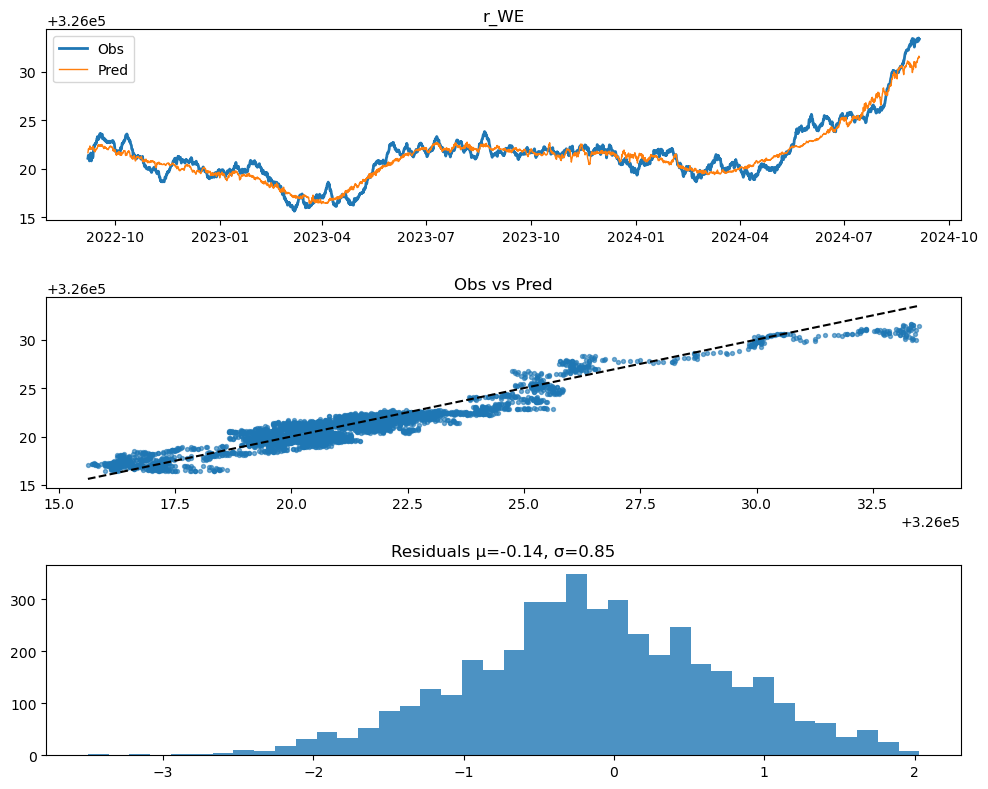

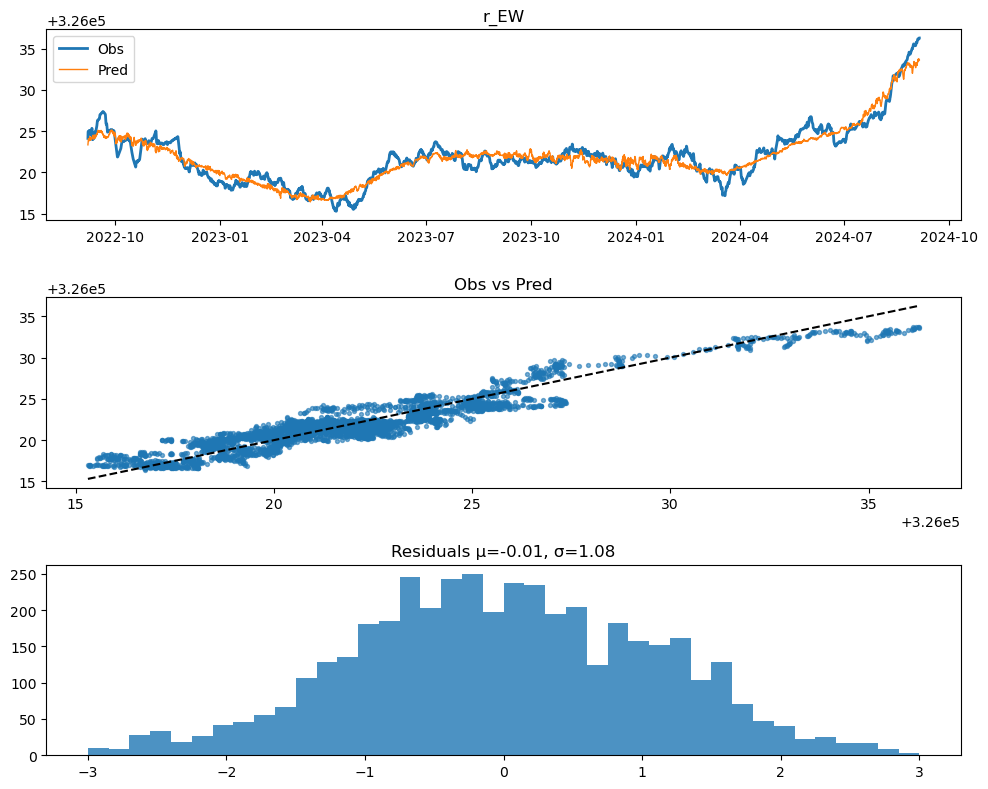

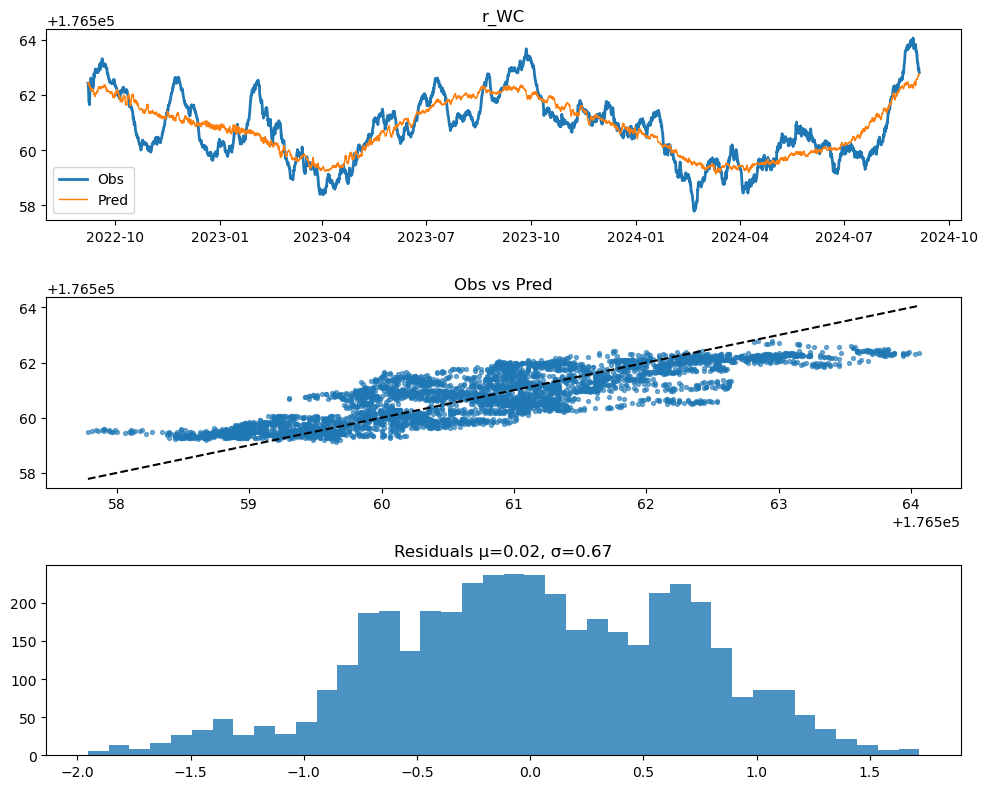

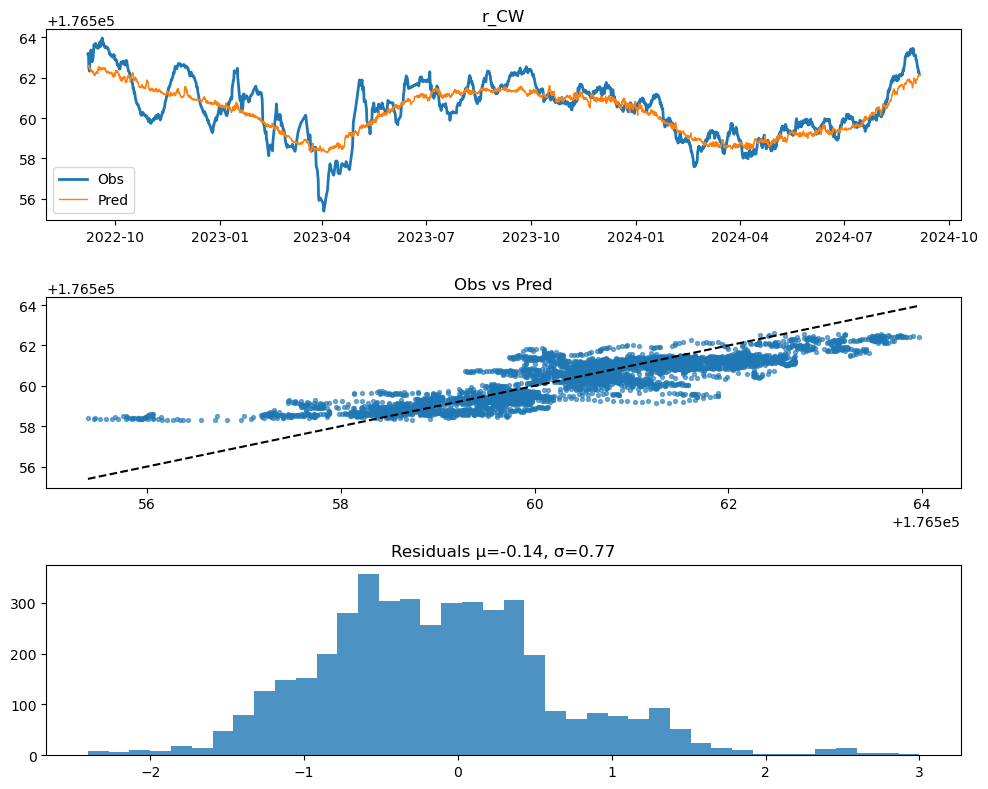

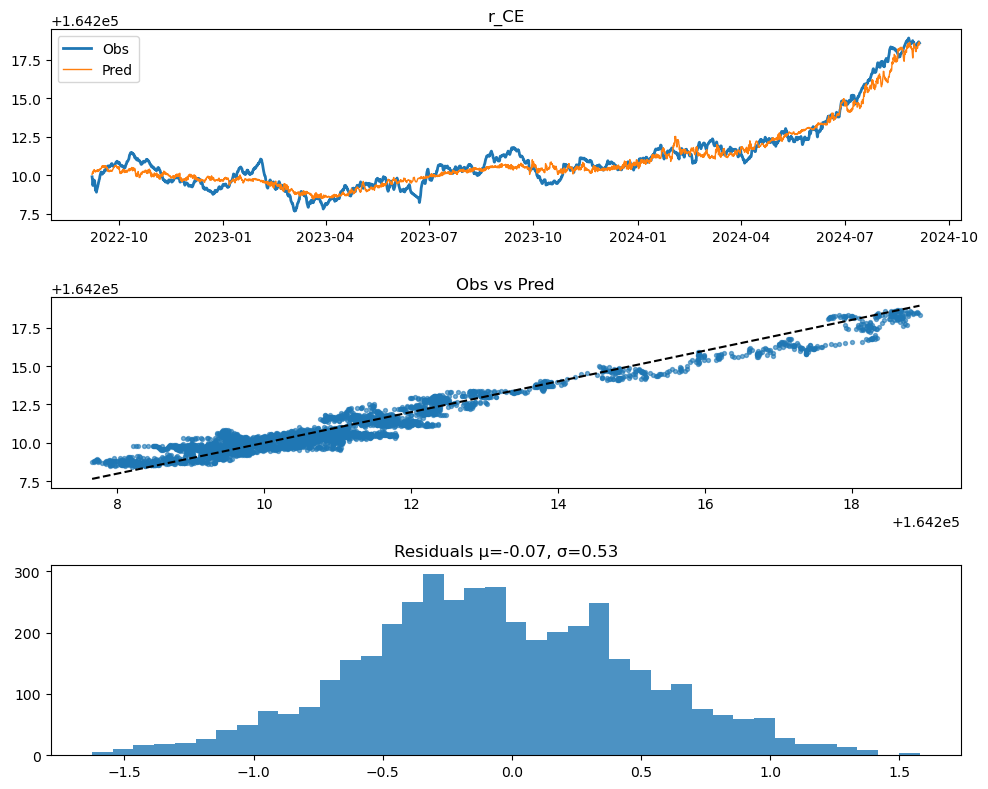

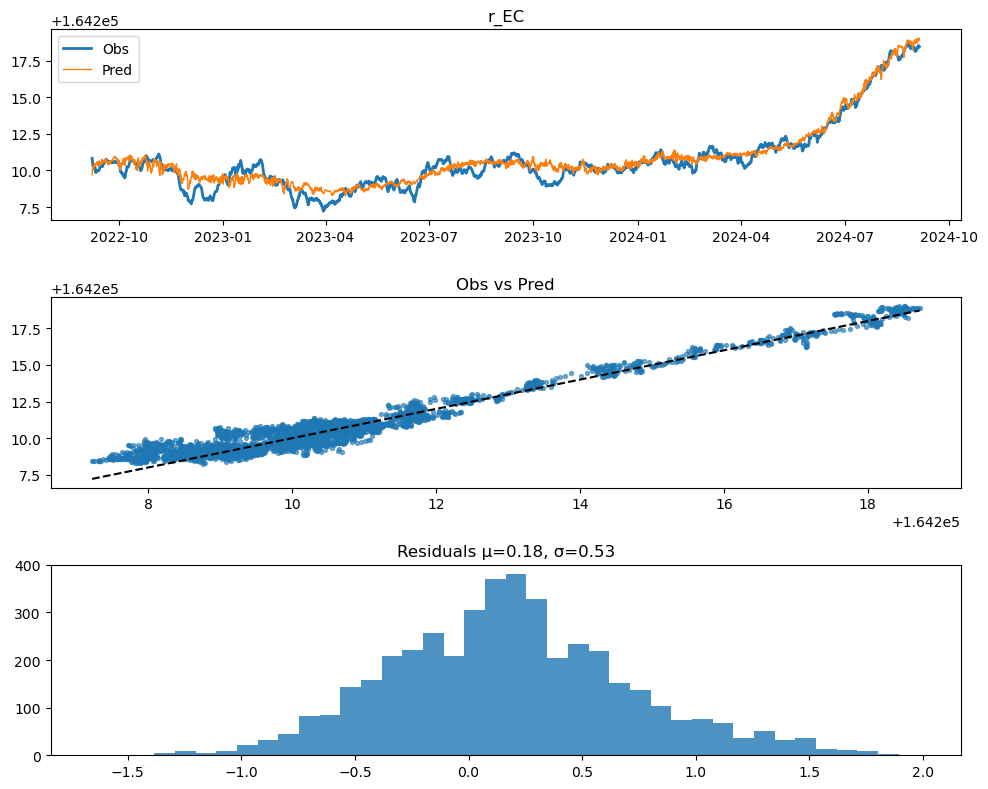

In [56]:
# -----------------------------------------------------------------------------
# 8) VISUALIZE
# -----------------------------------------------------------------------------
for i,name in enumerate(Y_cols):
    fig, ax = plt.subplots(3,1, figsize=(10,8), tight_layout=True)
    ax[0].plot(times, Y_raw[:,i],   label='Obs', lw=2)
    ax[0].plot(times, Y_hat[:,i],   label='Pred', lw=1)
    ax[0].set_title(name); ax[0].legend()
    ax[1].scatter(Y_raw[:,i], Y_hat[:,i], s=8, alpha=0.6)
    mn,mx = Y_raw[:,i].min(), Y_raw[:,i].max()
    ax[1].plot([mn,mx],[mn,mx],'k--'); ax[1].set_title("Obs vs Pred")
    errs = Y_hat[:,i] - Y_raw[:,i]
    ax[2].hist(errs, bins=40, alpha=0.8)
    ax[2].set_title(f"Residuals μ={errs.mean():.2f}, σ={errs.std():.2f}")
    plt.show()



In [57]:
# =============================================================================
# TWO-STAGE PINN HYBRID: ENHANCED TREND STRIP + RESIDUAL PINN
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, pathlib

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, Model, backend as K, callbacks

# -----------------------------------------------------------------------------
# 0) LOAD, FILTER & CLEAN
# -----------------------------------------------------------------------------
# assume df_var is already in memory
df_var = df_var.dropna().reset_index(drop=True)
df_var['Record Time'] = pd.to_datetime(df_var['Record Time'], utc=True)
cutoff = pd.Timestamp(2022, 9, 7, tz='UTC')
df_var = df_var[df_var['Record Time'] >= cutoff].reset_index(drop=True)

# build working DataFrame
df = pd.DataFrame({
    'time': df_var['Record Time'],
    'p1':   df_var['p1'],
    'p2':   df_var['p2'],
    'p3':   df_var['p3'],
    'r_WE': df_var['d1'],
    'r_EW': df_var['d2'],
    'r_EC': df_var['d3'],
    'r_CE': df_var['d4'],
    'r_WC': df_var['d5'],
    'r_CW': df_var['d6'],
})
Y_cols = ['r_WE','r_EW','r_WC','r_CW','r_CE','r_EC']

# -----------------------------------------------------------------------------
# 1) FEATURE ENGINEERING
# -----------------------------------------------------------------------------
# time & season
t0 = df['time'].min()
df['t_days'] = (df['time'] - t0).dt.total_seconds() / 86400.0
ω = 2*np.pi / 365.25
df['sin1'] = np.sin(ω * df['t_days'])
df['cos1'] = np.cos(ω * df['t_days'])

# pressure→baseline hints
df['p2_CE'] = df['p2']; df['p2_EC'] = df['p2']
df['p1_CW'] = df['p1']; df['p1_WE'] = df['p1']
df['p1_EW'] = df['p1']; df['p2_EW'] = df['p2']

# interaction features
df['p1_sin'] = df['p1'] * df['sin1']
df['p2_sin'] = df['p2'] * df['sin1']
df['p1_cos'] = df['p1'] * df['cos1']
df['p2_cos'] = df['p2'] * df['cos1']
df['p1p2']   = df['p1'] * df['p2']

# lags of pressures
for lag in (1,2,3):
    df[f'p1_l{lag}'] = df['p1'].shift(lag)
    df[f'p2_l{lag}'] = df['p2'].shift(lag)
    df[f'p3_l{lag}'] = df['p3'].shift(lag)

# drop rows with NaNs from lagging
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

# assemble input and output arrays
feature_cols = [
    't_days','sin1','cos1',
    'p1','p2','p3',
    'p2_CE','p2_EC','p1_CW','p1_WE','p1_EW','p2_EW',
    'p1_sin','p2_sin','p1_cos','p2_cos','p1p2'
] + [f'{p}_l{lag}' for p in ['p1','p2','p3'] for lag in (1,2,3)]

X_raw  = df[feature_cols].values.astype('float32')
Y_true = df[Y_cols].values.astype('float32')
times  = df['time'].values

# -----------------------------------------------------------------------------
# 2) STANDARDIZE X & Y
# -----------------------------------------------------------------------------
scaler_X = StandardScaler().fit(X_raw)
Xs       = scaler_X.transform(X_raw)

scaler_Y = StandardScaler().fit(Y_true)
Ys       = scaler_Y.transform(Y_true)

# -----------------------------------------------------------------------------
# 3) BUILD ENHANCED PURE-PINN (trend + MLP)
# -----------------------------------------------------------------------------
inp = layers.Input(shape=(Xs.shape[1],), name='inp')

# trend head on time features
trend_in  = layers.Lambda(lambda x: x[:, :3], name='trend_in')(inp)
trend_out = layers.Dense(len(Y_cols), activation='linear', name='trend')(trend_in)

# residual MLP head
x = layers.Dense(256, activation='relu', name='res1')(inp)
x = layers.Dropout(0.2, name='drop1')(x)
x = layers.Dense(128, activation='relu', name='res2')(x)
x = layers.Dropout(0.2, name='drop2')(x)
x = layers.Dense(64, activation='relu', name='res3')(x)
resid_out = layers.Dense(len(Y_cols), activation='linear', name='resid')(x)

# full prediction
Y_pred_full = layers.Add(name='full')([trend_out, resid_out])
enhanced_model = Model(inp, Y_pred_full, name='enhanced_PINN')

# -----------------------------------------------------------------------------
# 4) PRE-TRAIN TREND HEAD
# -----------------------------------------------------------------------------
for layer in enhanced_model.layers:
    if layer.name not in ('trend', 'trend_in'):
        layer.trainable = False

enhanced_model.compile(optimizer='adam', loss='mse')
enhanced_model.fit(Xs, Ys, epochs=50, batch_size=256, verbose=1)

# -----------------------------------------------------------------------------
# 5) JOINT PINN TRAINING (with physics losses)
# -----------------------------------------------------------------------------
for layer in enhanced_model.layers:
    layer.trainable = True

def pinn_loss_full(y_true, y_pred):
    L_mse = K.mean(K.square(y_true - y_pred))
    CE, EC = y_pred[:,4], y_pred[:,5]
    CW, WC = y_pred[:,3], y_pred[:,2]
    L_sym  = K.mean(K.square(CE-EC) + K.square(CW-WC))
    dCE    = CE[1:] - CE[:-1]
    dCW    = CW[1:] - CW[:-1]
    dEW    = y_pred[1:,1] - y_pred[:-1,1]
    L_clo  = K.mean(K.square(dCE + dCW - dEW))
    diff2  = y_pred[2:] - 2*y_pred[1:-1] + y_pred[:-2]
    L_smo  = K.mean(K.square(diff2))
    return (1.0   * L_mse
          + 0.01  * L_sym
          + 0.01  * L_clo
          + 0.001 * L_smo)

enhanced_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                       loss=pinn_loss_full)

es = callbacks.EarlyStopping(monitor='loss', patience=30, restore_best_weights=True)
enhanced_model.fit(Xs, Ys, epochs=200, batch_size=len(Xs),
                   callbacks=[es], verbose=1)

# -----------------------------------------------------------------------------
# 6) EXTRACT TREND & COMPUTE TRUE RESIDUALS
# -----------------------------------------------------------------------------
# sub-model for trend head
trend_model = Model(enhanced_model.input,
                    enhanced_model.get_layer('trend').output)

# predict scaled trend, inverse-scale
trend_scaled = trend_model.predict(Xs)
trend        = scaler_Y.inverse_transform(trend_scaled)

# true ranges and true residuals
R_true       = Y_true
R_resid_true = R_true - trend

# -----------------------------------------------------------------------------
# 7) SCALE TRUE RESIDUALS AND TRAIN RESIDUAL-PINN
# -----------------------------------------------------------------------------
resid_scaler = StandardScaler().fit(R_resid_true)
R_resid_s    = resid_scaler.transform(R_resid_true)

# build residual-only PINN
inp2      = layers.Input(shape=(Xs.shape[1],), name='inp2')
h2        = layers.Dense(128, activation='relu')(inp2)
h2        = layers.Dropout(0.2)(h2)
h2        = layers.Dense(64, activation='relu')(h2)
resid_out2= layers.Dense(len(Y_cols), activation='linear')(h2)
res_model = Model(inp2, resid_out2, name='residual_PINN')

def pinn_loss_res(r_true, r_pred):
    L_mse = K.mean(K.square(r_true - r_pred))
    CE, EC = r_pred[:,4], r_pred[:,5]
    CW, WC = r_pred[:,3], r_pred[:,2]
    L_sym  = K.mean(K.square(CE-EC) + K.square(CW-WC))
    dCE    = CE[1:] - CE[:-1]
    dCW    = CW[1:] - CW[:-1]
    dEW    = r_pred[1:,1] - r_pred[:-1,1]
    L_clo  = K.mean(K.square(dCE + dCW - dEW))
    diff2  = r_pred[2:] - 2*r_pred[1:-1] + r_pred[:-2]
    L_smo  = K.mean(K.square(diff2))
    return (1.0 * L_mse + 0.1 * L_sym + 0.1 * L_clo + 0.01 * L_smo)

res_model.compile(optimizer='adam', loss=pinn_loss_res)
es2 = callbacks.EarlyStopping(monitor='loss', patience=20, restore_best_weights=True)
res_model.fit(Xs, R_resid_s, epochs=200, batch_size=len(Xs),
              callbacks=[es2], verbose=1)

# -----------------------------------------------------------------------------
# 8) PREDICT RESIDUALS & RECONSTRUCT FULL RANGES
# -----------------------------------------------------------------------------
R_resid_pred_s = res_model.predict(Xs)
R_resid_pred   = resid_scaler.inverse_transform(R_resid_pred_s)
R_pred_full    = trend + R_resid_pred

# -----------------------------------------------------------------------------
# 9) EVALUATE
# -----------------------------------------------------------------------------
print("Two-stage PINN hybrid metrics:")
for i,name in enumerate(Y_cols):
    r2   = r2_score(R_true[:,i], R_pred_full[:,i])
    rmse = mean_squared_error(R_true[:,i], R_pred_full[:,i], squared=False)
    print(f"{name}: R²={r2:.3f}, RMSE={rmse:.3f} m")



Epoch 1/50
17/17 [==============================] - 0s 2ms/step - loss: 1.6946
Epoch 2/50
17/17 [==============================] - 0s 2ms/step - loss: 1.6344
Epoch 3/50
17/17 [==============================] - 0s 2ms/step - loss: 1.5779
Epoch 4/50
17/17 [==============================] - 0s 2ms/step - loss: 1.5268
Epoch 5/50
17/17 [==============================] - 0s 2ms/step - loss: 1.4665
Epoch 6/50
17/17 [==============================] - 0s 2ms/step - loss: 1.4114
Epoch 7/50
17/17 [==============================] - 0s 2ms/step - loss: 1.3653
Epoch 8/50
17/17 [==============================] - 0s 2ms/step - loss: 1.3227
Epoch 9/50
17/17 [==============================] - 0s 2ms/step - loss: 1.2789
Epoch 10/50
17/17 [==============================] - 0s 2ms/step - loss: 1.2409
Epoch 11/50
17/17 [==============================] - 0s 2ms/step - loss: 1.1965
Epoch 12/50
17/17 [==============================] - 0s 2ms/step - loss: 1.1614
Epoch 13/50
17/17 [==============================

1/1 [==============================] - 0s 7ms/step - loss: 0.3275
Epoch 55/200
1/1 [==============================] - 0s 8ms/step - loss: 0.3243
Epoch 56/200
1/1 [==============================] - 0s 7ms/step - loss: 0.3250
Epoch 57/200
1/1 [==============================] - 0s 8ms/step - loss: 0.3209
Epoch 58/200
1/1 [==============================] - 0s 7ms/step - loss: 0.3242
Epoch 59/200
1/1 [==============================] - 0s 8ms/step - loss: 0.3207
Epoch 60/200
1/1 [==============================] - 0s 8ms/step - loss: 0.3205
Epoch 61/200
1/1 [==============================] - 0s 8ms/step - loss: 0.3187
Epoch 62/200
1/1 [==============================] - 0s 8ms/step - loss: 0.3138
Epoch 63/200
1/1 [==============================] - 0s 7ms/step - loss: 0.3186
Epoch 64/200
1/1 [==============================] - 0s 8ms/step - loss: 0.3137
Epoch 65/200
1/1 [==============================] - 0s 8ms/step - loss: 0.3122
Epoch 66/200
1/1 [==============================] - 0s 7ms/step -

1/1 [==============================] - 0s 8ms/step - loss: 0.2320
Epoch 158/200
1/1 [==============================] - 0s 8ms/step - loss: 0.2309
Epoch 159/200
1/1 [==============================] - 0s 7ms/step - loss: 0.2325
Epoch 160/200
1/1 [==============================] - 0s 8ms/step - loss: 0.2307
Epoch 161/200
1/1 [==============================] - 0s 8ms/step - loss: 0.2284
Epoch 162/200
1/1 [==============================] - 0s 7ms/step - loss: 0.2287
Epoch 163/200
1/1 [==============================] - 0s 8ms/step - loss: 0.2278
Epoch 164/200
1/1 [==============================] - 0s 7ms/step - loss: 0.2313
Epoch 165/200
1/1 [==============================] - 0s 8ms/step - loss: 0.2276
Epoch 166/200
1/1 [==============================] - 0s 7ms/step - loss: 0.2299
Epoch 167/200
1/1 [==============================] - 0s 8ms/step - loss: 0.2264
Epoch 168/200
1/1 [==============================] - 0s 7ms/step - loss: 0.2268
Epoch 169/200
1/1 [==============================] - 0

1/1 [==============================] - 0s 6ms/step - loss: 0.5179
Epoch 60/200
1/1 [==============================] - 0s 5ms/step - loss: 0.5177
Epoch 61/200
1/1 [==============================] - 0s 5ms/step - loss: 0.5132
Epoch 62/200
1/1 [==============================] - 0s 5ms/step - loss: 0.5143
Epoch 63/200
1/1 [==============================] - 0s 6ms/step - loss: 0.5085
Epoch 64/200
1/1 [==============================] - 0s 5ms/step - loss: 0.5077
Epoch 65/200
1/1 [==============================] - 0s 5ms/step - loss: 0.5039
Epoch 66/200
1/1 [==============================] - 0s 5ms/step - loss: 0.5054
Epoch 67/200
1/1 [==============================] - 0s 5ms/step - loss: 0.5018
Epoch 68/200
1/1 [==============================] - 0s 5ms/step - loss: 0.5022
Epoch 69/200
1/1 [==============================] - 0s 6ms/step - loss: 0.4970
Epoch 70/200
1/1 [==============================] - 0s 5ms/step - loss: 0.4954
Epoch 71/200
1/1 [==============================] - 0s 6ms/step -

1/1 [==============================] - 0s 5ms/step - loss: 0.3746
Epoch 163/200
1/1 [==============================] - 0s 5ms/step - loss: 0.3687
Epoch 164/200
1/1 [==============================] - 0s 5ms/step - loss: 0.3704
Epoch 165/200
1/1 [==============================] - 0s 5ms/step - loss: 0.3690
Epoch 166/200
1/1 [==============================] - 0s 6ms/step - loss: 0.3662
Epoch 167/200
1/1 [==============================] - 0s 6ms/step - loss: 0.3658
Epoch 168/200
1/1 [==============================] - 0s 6ms/step - loss: 0.3634
Epoch 169/200
1/1 [==============================] - 0s 5ms/step - loss: 0.3647
Epoch 170/200
1/1 [==============================] - 0s 5ms/step - loss: 0.3650
Epoch 171/200
1/1 [==============================] - 0s 5ms/step - loss: 0.3631
Epoch 172/200
1/1 [==============================] - 0s 5ms/step - loss: 0.3668
Epoch 173/200
1/1 [==============================] - 0s 5ms/step - loss: 0.3631
Epoch 174/200
1/1 [==============================] - 0

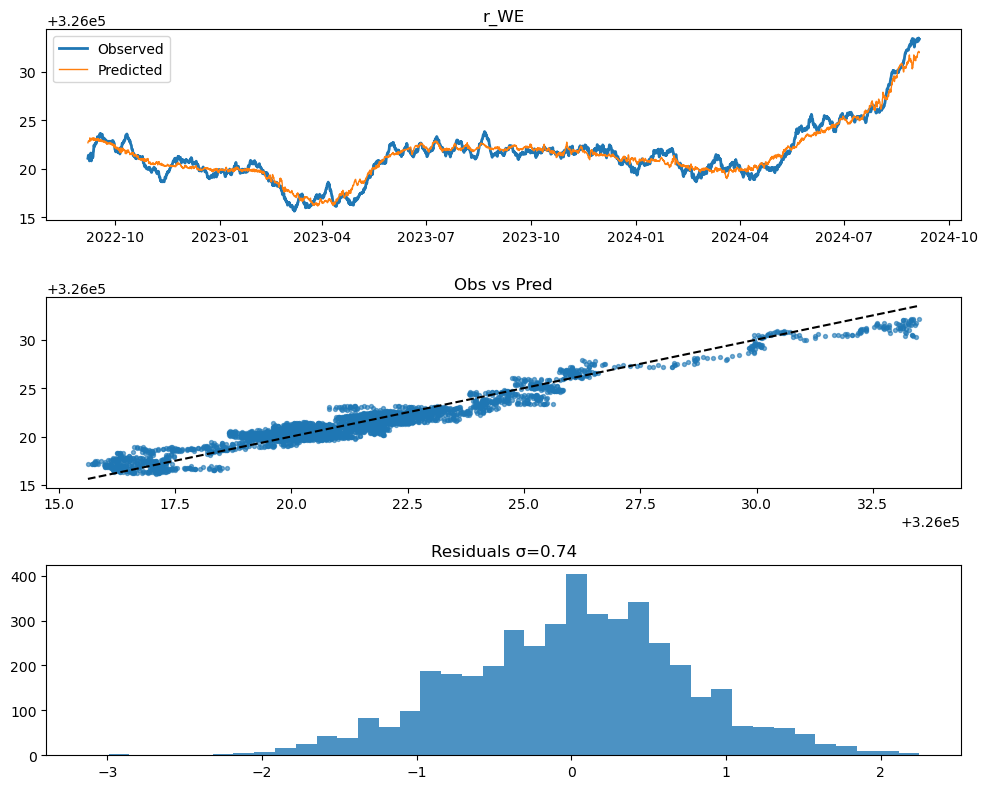

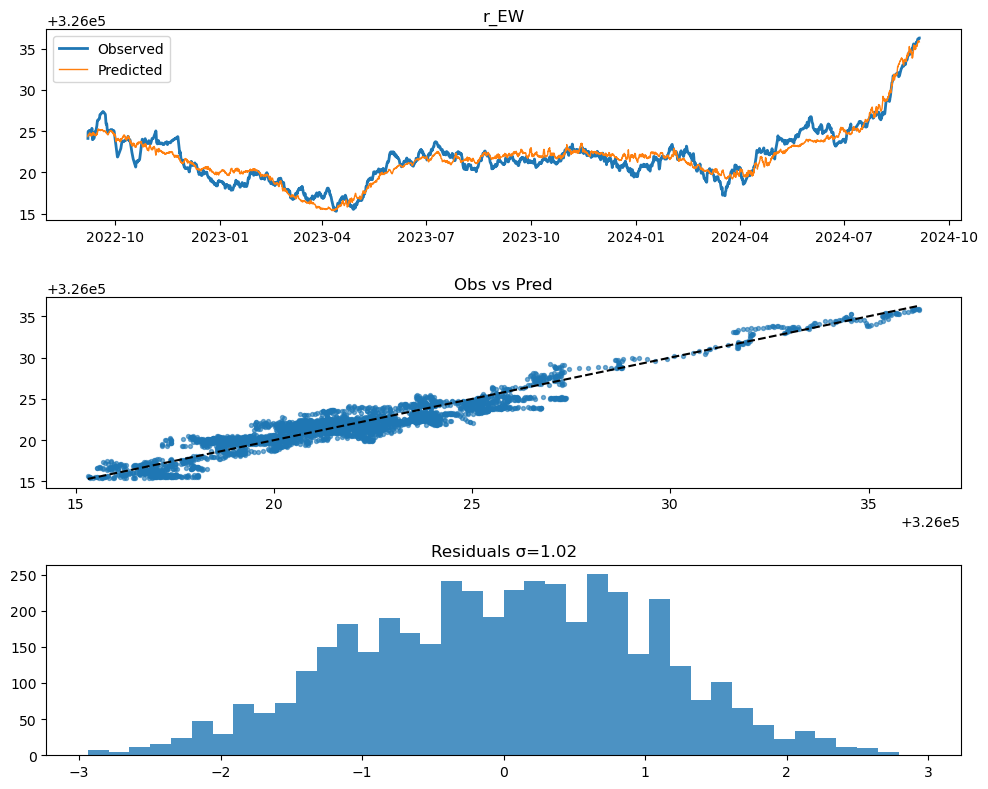

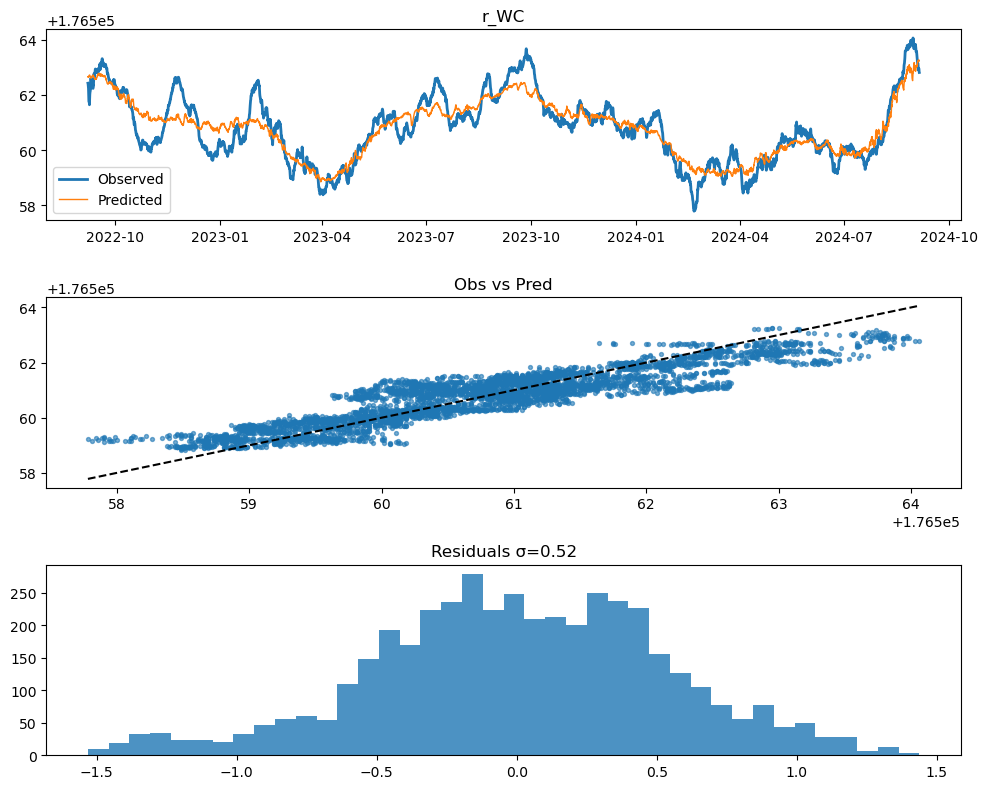

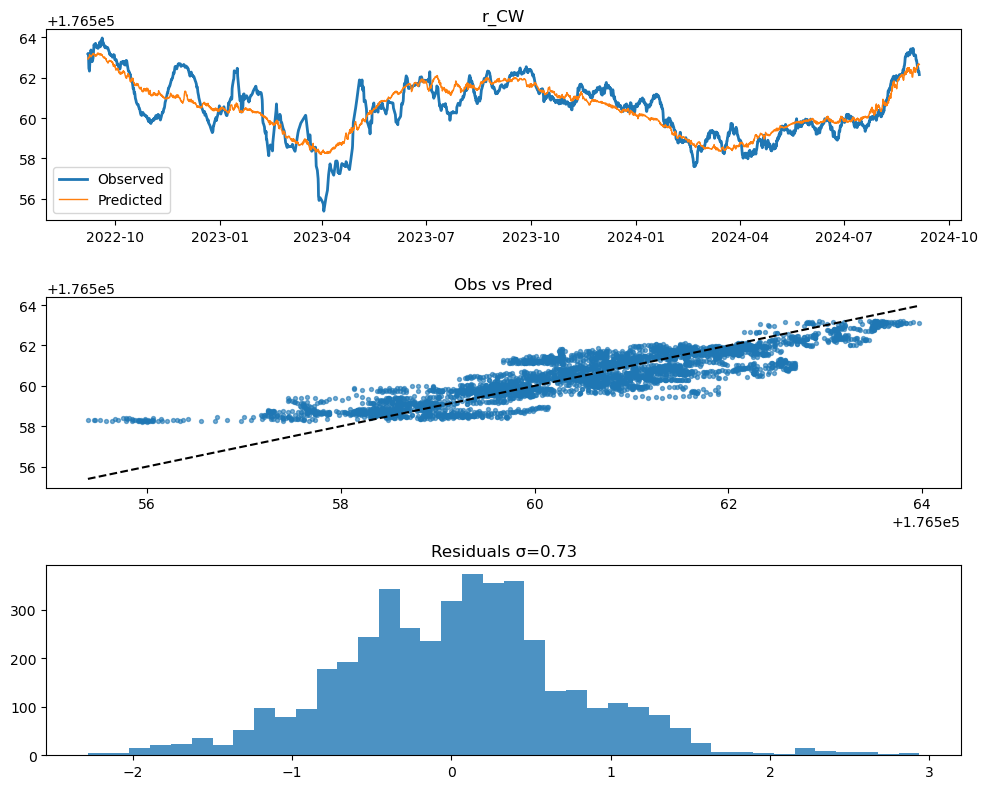

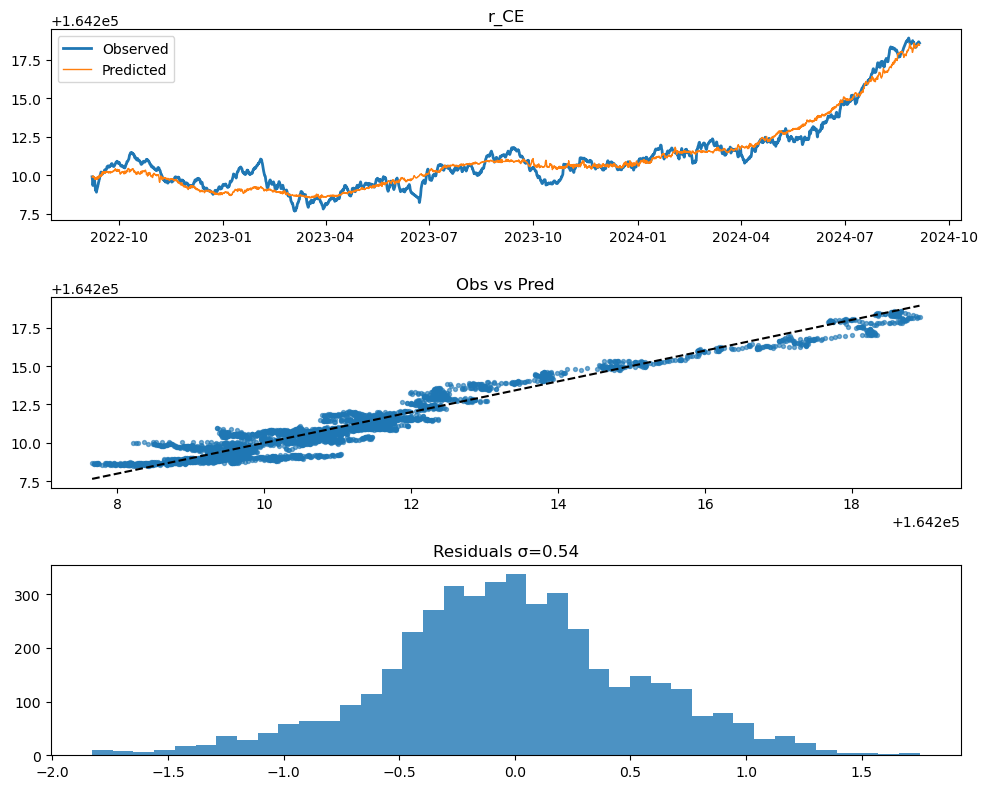

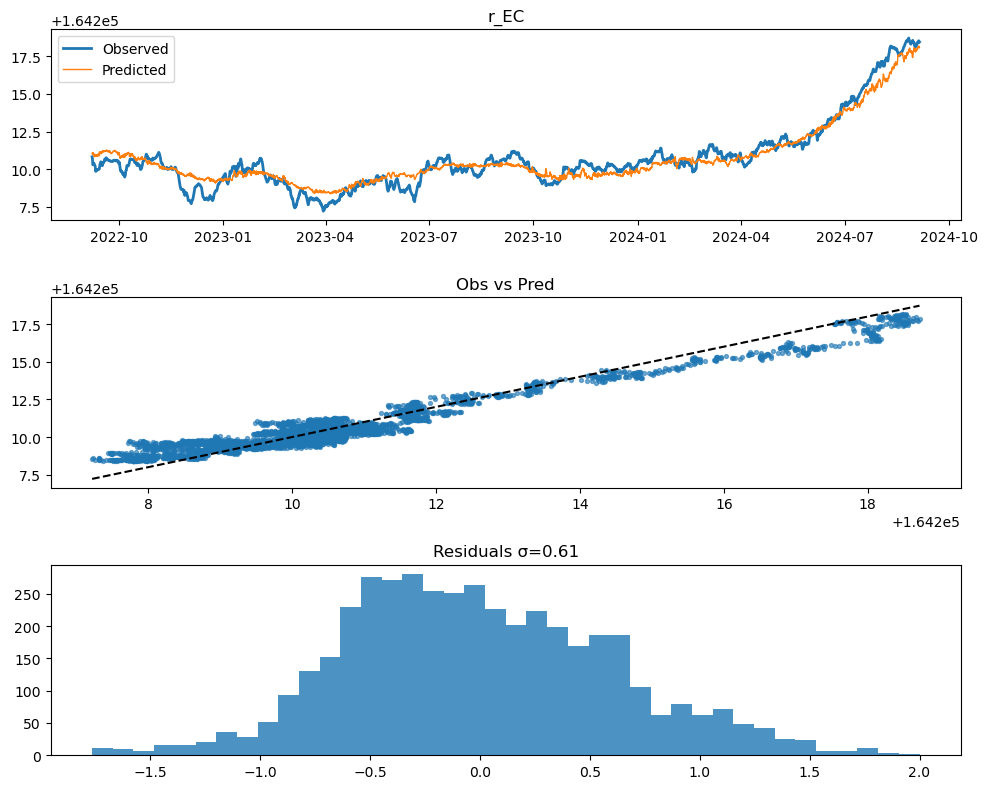

In [58]:
# -----------------------------------------------------------------------------
# 10) VISUALIZE
# -----------------------------------------------------------------------------
for i,name in enumerate(Y_cols):
    fig, ax = plt.subplots(3,1, figsize=(10,8), tight_layout=True)
    ax[0].plot(times, R_true[:,i],   label='Observed', lw=2)
    ax[0].plot(times, R_pred_full[:,i], label='Predicted', lw=1)
    ax[0].set_title(name); ax[0].legend()
    ax[1].scatter(R_true[:,i], R_pred_full[:,i], s=8, alpha=0.6)
    mn,mx = R_true[:,i].min(), R_true[:,i].max()
    ax[1].plot([mn,mx],[mn,mx],'k--'); ax[1].set_title("Obs vs Pred")
    errs = R_pred_full[:,i] - R_true[:,i]
    ax[2].hist(errs, bins=40, alpha=0.8); ax[2].set_title(f"Residuals σ={errs.std():.2f}")
    plt.show()



In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, pathlib

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, Model, backend as K, callbacks

# -----------------------------------------------------------------------------
# 0) LOAD & FILTER DATA
# -----------------------------------------------------------------------------
df_var['Record Time'] = pd.to_datetime(df_var['Record Time'], utc=True)
df_var = df_var.dropna().query("`Record Time` >= '2022-09-07T00:00:00Z'").reset_index(drop=True)

df = pd.DataFrame({
    'time': df_var['Record Time'],
    'p1':   df_var['p1'],
    'p2':   df_var['p2'],
    'p3':   df_var['p3'],
    'r_WE': df_var['d1'],
    'r_EW': df_var['d2'],
    'r_EC': df_var['d3'],
    'r_CE': df_var['d4'],
    'r_WC': df_var['d5'],
    'r_CW': df_var['d6'],
})
Y_cols = ['r_WE','r_EW','r_WC','r_CW','r_CE','r_EC']

# 1) TIME & SEASONAL FEATURES
t0     = df['time'].min()
df['t_days'] = (df['time'] - t0).dt.total_seconds() / 86400.0
ω      = 2*np.pi/365.25
df['sin1'] = np.sin(ω * df['t_days'])
df['cos1'] = np.cos(ω * df['t_days'])

# standardize pressures for LS block
p1_std = (df['p1'] - df['p1'].mean()) / df['p1'].std()
p2_std = (df['p2'] - df['p2'].mean()) / df['p2'].std()

sin_t = df['sin1'].values
cos_t = df['cos1'].values

# 2) LS BLOCK FITS
# East block
A_CE = np.column_stack([np.ones_like(p2_std), p2_std, sin_t, cos_t])
x_CE, *_ = np.linalg.lstsq(A_CE, df['r_CE'], rcond=None)
x_EC, *_ = np.linalg.lstsq(A_CE, df['r_EC'], rcond=None)
r_CE_lin = A_CE @ x_CE
r_EC_lin = A_CE @ x_EC

# West block
A_CW = np.column_stack([np.ones_like(p1_std), p1_std, sin_t, cos_t])
x_CW, *_ = np.linalg.lstsq(A_CW, df['r_CW'], rcond=None)
x_WC, *_ = np.linalg.lstsq(A_CW, df['r_WC'], rcond=None)
r_CW_lin = A_CW @ x_CW
r_WC_lin = A_CW @ x_WC

# Mid block
A_EW = np.column_stack([np.ones_like(p1_std), p1_std, p2_std, sin_t, cos_t])
x_EW, *_ = np.linalg.lstsq(A_EW, df['r_EW'], rcond=None)
x_WE, *_ = np.linalg.lstsq(A_EW, df['r_WE'], rcond=None)
r_EW_lin = A_EW @ x_EW
r_WE_lin = A_EW @ x_WE

# Stack LS predictions
R_lin = np.column_stack([r_WE_lin, r_EW_lin, r_WC_lin,
                         r_CW_lin, r_CE_lin, r_EC_lin]).astype('float32')

# 3) TRUE RESIDUALS
R_obs     = df[Y_cols].values.astype('float32')
R_resid   = R_obs - R_lin

# 4) FEATURE ENGINEERING & LAGS
df_feat = df[['t_days','sin1','cos1','p1','p2','p3']].copy()
for lag in (1,2,3):
    df_feat[f'p1_l{lag}'] = df['p1'].shift(lag)
    df_feat[f'p2_l{lag}'] = df['p2'].shift(lag)
    df_feat[f'p3_l{lag}'] = df['p3'].shift(lag)

# add LS features
df_feat['r_WE_lin'] = r_WE_lin
df_feat['r_EW_lin'] = r_EW_lin
df_feat['r_WC_lin'] = r_WC_lin
df_feat['r_CW_lin'] = r_CW_lin
df_feat['r_CE_lin'] = r_CE_lin
df_feat['r_EC_lin'] = r_EC_lin

df_feat.dropna(inplace=True)
df_feat.reset_index(drop=True, inplace=True)

# Align arrays after lag drop
valid_idx    = df_feat.index.values
X_raw        = df_feat.values.astype('float32')
R_resid_true = R_resid[valid_idx]
R_lin_aligned= R_lin[valid_idx]
R_true       = R_obs[valid_idx]
times        = df['time'].values[valid_idx]

# 5) SCALE
scaler_X = StandardScaler().fit(X_raw)
Xs       = scaler_X.transform(X_raw)
scaler_R = StandardScaler().fit(R_resid_true)
Rs_scaled= scaler_R.transform(R_resid_true)

# 6) BUILD MULTI-HEADED RESIDUAL PINN
inp = layers.Input(shape=(Xs.shape[1],), name='inp')

# shared trunk
shared = layers.Dense(64, activation='relu')(inp)
shared = layers.Dense(64, activation='relu')(shared)

# define index lists for LS features
feat_cols = list(df_feat.columns)
east_idx = [feat_cols.index(c) for c in ['r_CE_lin','r_EC_lin']]
west_idx = [feat_cols.index(c) for c in ['r_CW_lin','r_WC_lin']]
mid_idx  = [feat_cols.index(c) for c in ['r_WE_lin','r_EW_lin']]

# East head
east_feats = layers.Lambda(lambda x: tf.gather(x, east_idx, axis=1))(inp)
east_in    = layers.Concatenate()([shared, east_feats])
east_h     = layers.Dense(32, activation='relu')(east_in)
r_CE_p     = layers.Dense(1, name='r_CE')(east_h)
r_EC_p     = layers.Dense(1, name='r_EC')(east_h)

# West head
west_feats = layers.Lambda(lambda x: tf.gather(x, west_idx, axis=1))(inp)
west_in    = layers.Concatenate()([shared, west_feats])
west_h     = layers.Dense(32, activation='relu')(west_in)
r_CW_p     = layers.Dense(1, name='r_CW')(west_h)
r_WC_p     = layers.Dense(1, name='r_WC')(west_h)

# Mid head
mid_feats  = layers.Lambda(lambda x: tf.gather(x, mid_idx, axis=1))(inp)
mid_in     = layers.Concatenate()([shared, mid_feats])
mid_h      = layers.Dense(32, activation='relu')(mid_in)
r_WE_p     = layers.Dense(1, name='r_WE')(mid_h)
r_EW_p     = layers.Dense(1, name='r_EW')(mid_h)

# concat residual preds in correct order
resid_out = layers.Concatenate(name='resid')([r_WE_p, r_EW_p, r_WC_p, r_CW_p, r_CE_p, r_EC_p])

res_model = Model(inp, resid_out, name='residual_PINN')

def pinn_loss(r_true, r_pred):
    L_mse = K.mean(K.square(r_true - r_pred))
    CE, EC = r_pred[:,4], r_pred[:,5]
    CW, WC = r_pred[:,3], r_pred[:,2]
    L_sym  = K.mean(K.square(CE-EC) + K.square(CW-WC))
    dCE    = CE[1:] - CE[:-1]
    dCW    = CW[1:] - CW[:-1]
    dEW    = r_pred[1:,1] - r_pred[:-1,1]
    L_clo  = K.mean(K.square(dCE + dCW - dEW))
    return 10.0*L_mse + 0.1*L_sym + 0.1*L_clo

res_model.compile(optimizer='adam', loss=pinn_loss)

# 7) TRAIN RESIDUAL PINN
es = callbacks.EarlyStopping(monitor='loss', patience=20, restore_best_weights=True)
res_model.fit(Xs, Rs_scaled, epochs=200, batch_size=len(Xs), callbacks=[es], verbose=1)

# 8) PREDICT & RECONSTRUCT
R_resid_pred_s = res_model.predict(Xs)
R_resid_pred   = scaler_R.inverse_transform(R_resid_pred_s)
R_pred_full    = R_lin_aligned + R_resid_pred

# 9) EVALUATE
print("LS‐feat + multi-head residual PINN metrics:")
for i, name in enumerate(Y_cols):
    r2   = r2_score(R_true[:,i], R_pred_full[:,i])
    rmse = mean_squared_error(R_true[:,i], R_pred_full[:,i], squared=False)
    print(f"{name}: R²={r2:.3f}, RMSE={rmse:.3f} m")



Epoch 1/200
1/1 [==============================] - 1s 1s/step - loss: 10.9918
Epoch 2/200
1/1 [==============================] - 0s 8ms/step - loss: 10.6379
Epoch 3/200
1/1 [==============================] - 0s 8ms/step - loss: 10.3788
Epoch 4/200
1/1 [==============================] - 0s 8ms/step - loss: 10.1817
Epoch 5/200
1/1 [==============================] - 0s 8ms/step - loss: 10.0111
Epoch 6/200
1/1 [==============================] - 0s 8ms/step - loss: 9.8483
Epoch 7/200
1/1 [==============================] - 0s 8ms/step - loss: 9.6883
Epoch 8/200
1/1 [==============================] - 0s 8ms/step - loss: 9.5354
Epoch 9/200
1/1 [==============================] - 0s 8ms/step - loss: 9.3939
Epoch 10/200
1/1 [==============================] - 0s 8ms/step - loss: 9.2637
Epoch 11/200
1/1 [==============================] - 0s 8ms/step - loss: 9.1444
Epoch 12/200
1/1 [==============================] - 0s 8ms/step - loss: 9.0348
Epoch 13/200
1/1 [==============================] - 0s 8m

1/1 [==============================] - 0s 7ms/step - loss: 3.0803
Epoch 105/200
1/1 [==============================] - 0s 7ms/step - loss: 3.0504
Epoch 106/200
1/1 [==============================] - 0s 7ms/step - loss: 3.0202
Epoch 107/200
1/1 [==============================] - 0s 7ms/step - loss: 2.9924
Epoch 108/200
1/1 [==============================] - 0s 7ms/step - loss: 2.9620
Epoch 109/200
1/1 [==============================] - 0s 7ms/step - loss: 2.9360
Epoch 110/200
1/1 [==============================] - 0s 7ms/step - loss: 2.9090
Epoch 111/200
1/1 [==============================] - 0s 7ms/step - loss: 2.8806
Epoch 112/200
1/1 [==============================] - 0s 7ms/step - loss: 2.8546
Epoch 113/200
1/1 [==============================] - 0s 7ms/step - loss: 2.8273
Epoch 114/200
1/1 [==============================] - 0s 7ms/step - loss: 2.7985
Epoch 115/200
1/1 [==============================] - 0s 7ms/step - loss: 2.7737
Epoch 116/200
1/1 [==============================] - 0

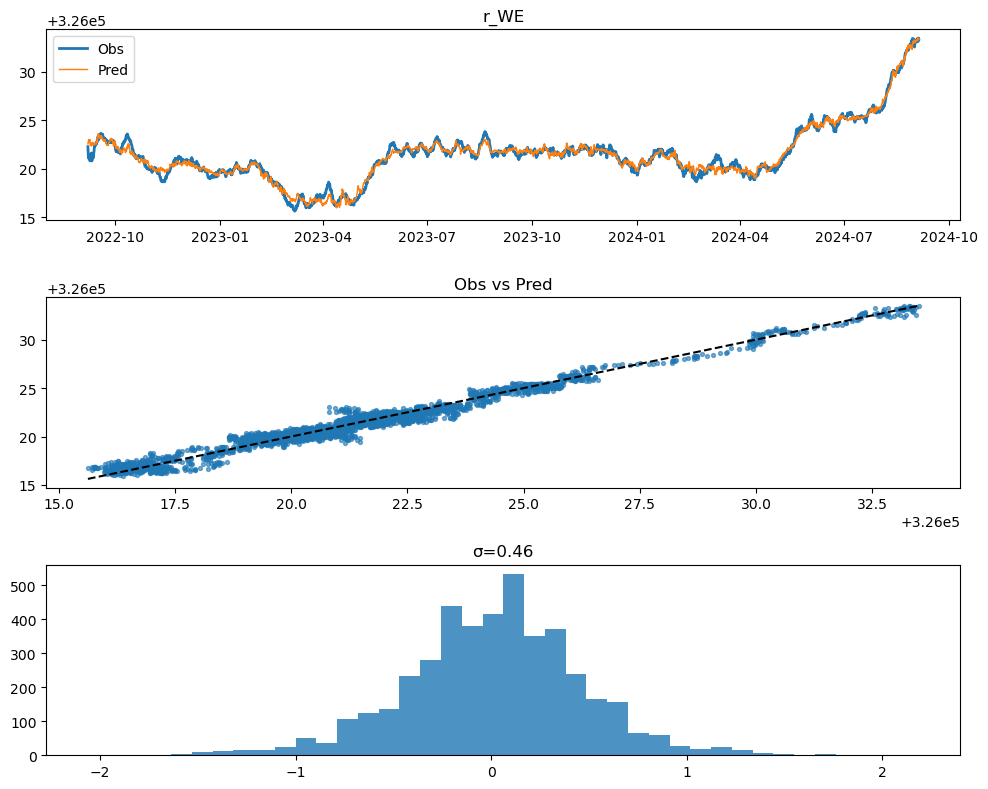

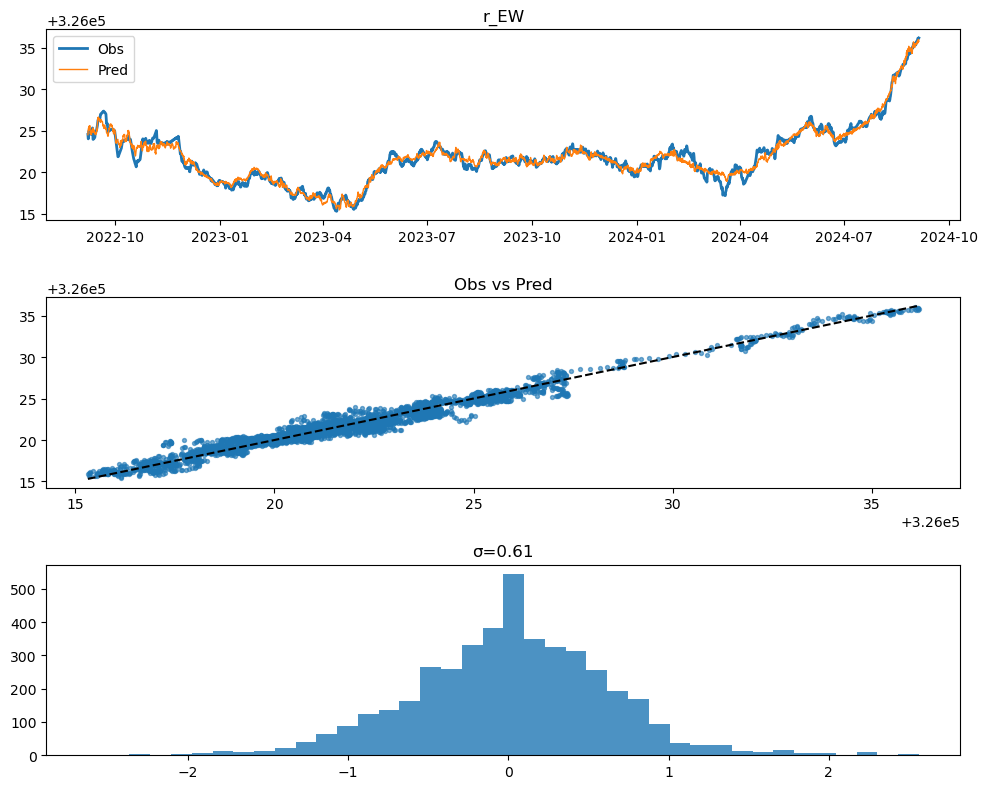

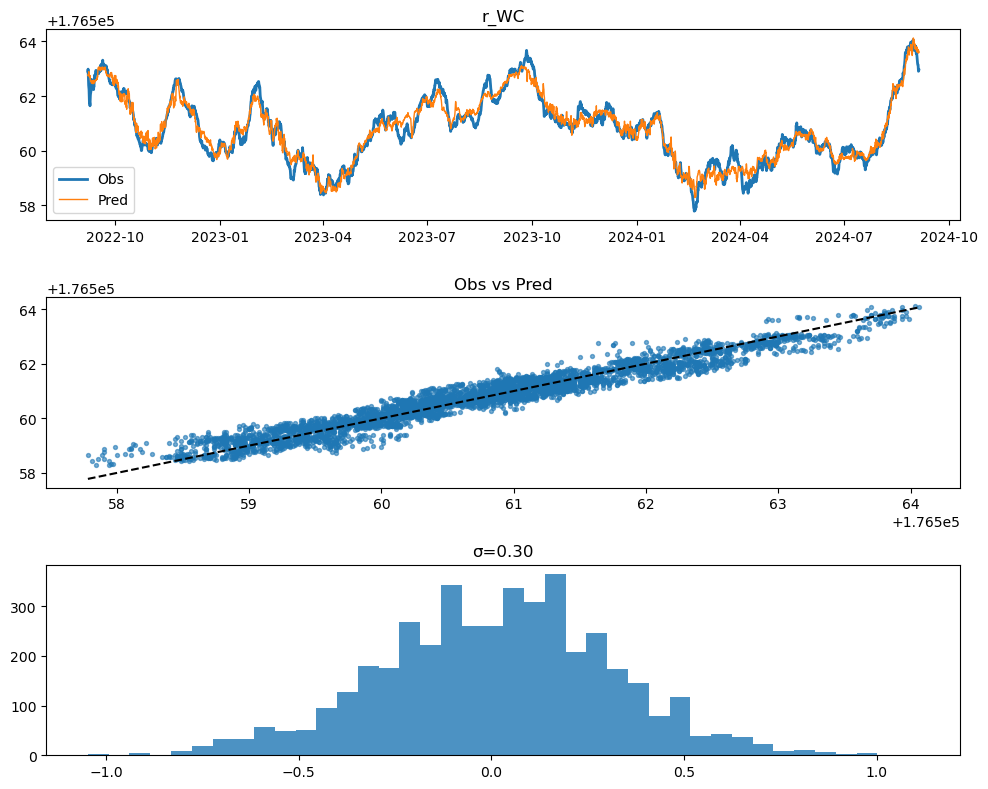

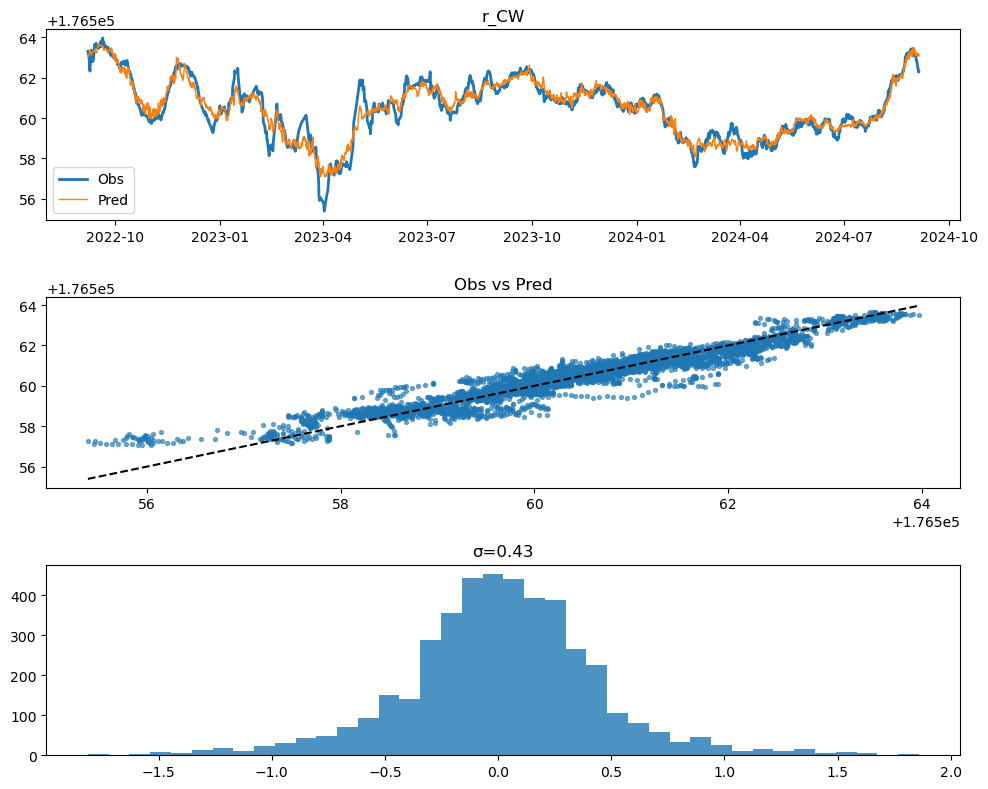

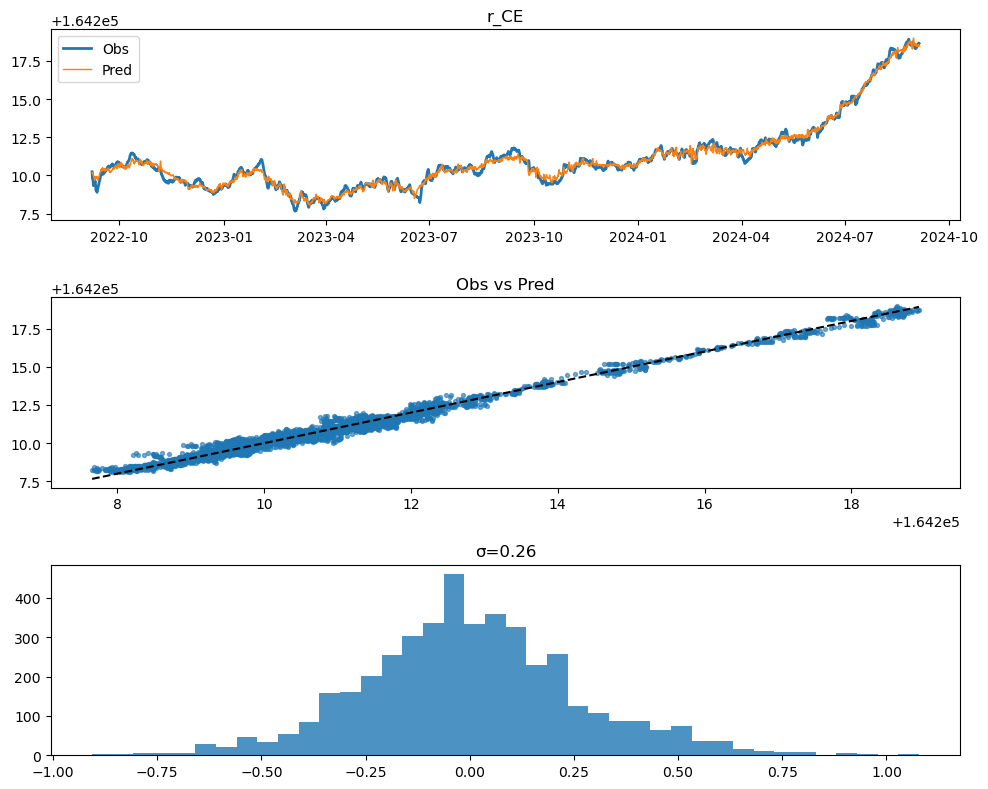

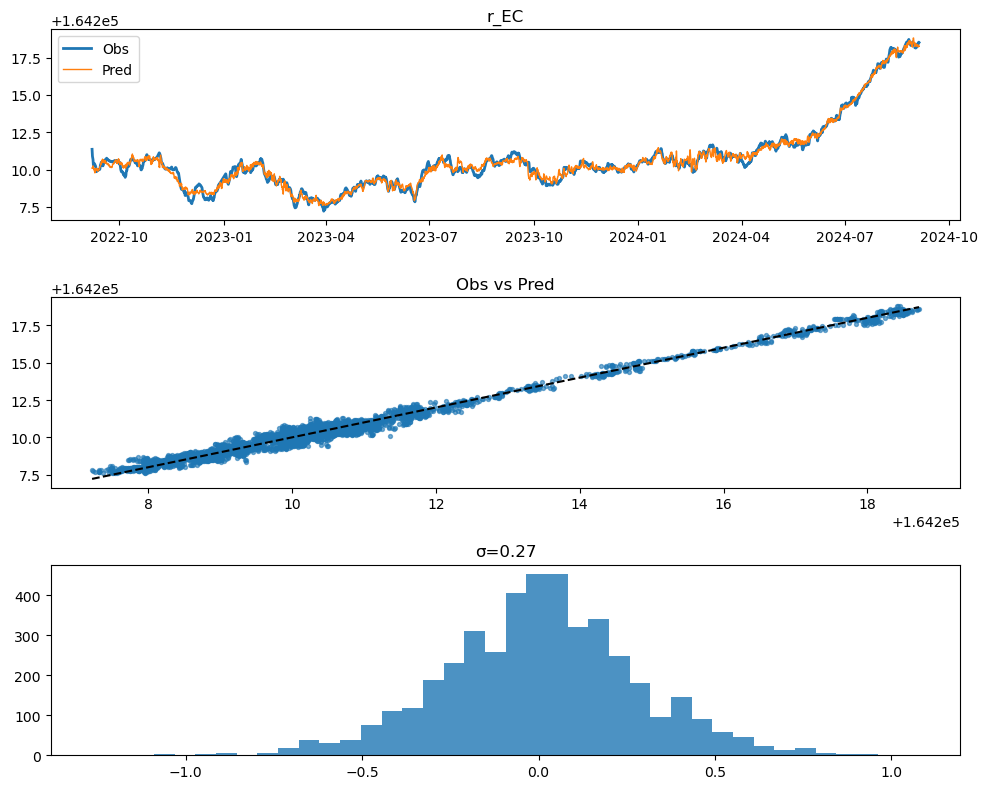

In [60]:
# 10) VISUALIZE
for i,name in enumerate(Y_cols):
    fig, ax = plt.subplots(3,1, figsize=(10,8), tight_layout=True)
    ax[0].plot(times, R_true[:,i], label='Obs', lw=2)
    ax[0].plot(times, R_pred_full[:,i], label='Pred', lw=1)
    ax[0].set_title(name); ax[0].legend()
    ax[1].scatter(R_true[:,i], R_pred_full[:,i], s=8, alpha=0.6)
    mn, mx = R_true[:,i].min(), R_true[:,i].max()
    ax[1].plot([mn,mx],[mn,mx],'k--'); ax[1].set_title("Obs vs Pred")
    errs = R_pred_full[:,i] - R_true[:,i]
    ax[2].hist(errs, bins=40, alpha=0.8); ax[2].set_title(f"σ={errs.std():.2f}")
    plt.show()



In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, pathlib

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, Model, backend as K, callbacks

# =============================================================================
# FULL LS+PINN HYBRID WITH STRICT HINGE LOSS (FULL-SERIES TRAINING)
# =============================================================================

# 0) LOAD, FILTER & CLEAN
df_var = df_var.dropna().reset_index(drop=True)
df_var['Record Time'] = pd.to_datetime(df_var['Record Time'], utc=True)
cutoff = pd.Timestamp(2022, 9, 7, tz='UTC')
df_var = df_var[df_var['Record Time'] >= cutoff].reset_index(drop=True)

df = pd.DataFrame({
    'time': df_var['Record Time'],
    'p1':   df_var['p1'],
    'p2':   df_var['p2'],
    'p3':   df_var['p3'],
    'r_WE': df_var['d1'],
    'r_EW': df_var['d2'],
    'r_EC': df_var['d3'],
    'r_CE': df_var['d4'],
    'r_WC': df_var['d5'],
    'r_CW': df_var['d6'],
})
Y_cols = ['r_WE','r_EW','r_WC','r_CW','r_CE','r_EC']

# 1) TIME & SEASONAL FEATURES
t0     = df['time'].min()
t_days = (df['time'] - t0).dt.total_seconds() / 86400.0
ω      = 2 * np.pi / 365.25
sin_t  = np.sin(ω * t_days)
cos_t  = np.cos(ω * t_days)

# standardize pressures for LS block
p1_std = (df['p1'] - df['p1'].mean()) / df['p1'].std()
p2_std = (df['p2'] - df['p2'].mean()) / df['p2'].std()

# 2) LEAST-SQUARES BLOCKS
A_CE = np.column_stack([np.ones_like(p2_std), p2_std, sin_t, cos_t])
x_CE, *_ = np.linalg.lstsq(A_CE, df['r_CE'], rcond=None)
x_EC, *_ = np.linalg.lstsq(A_CE, df['r_EC'], rcond=None)
r_CE_lin = A_CE @ x_CE
r_EC_lin = A_CE @ x_EC

A_CW = np.column_stack([np.ones_like(p1_std), p1_std, sin_t, cos_t])
x_CW, *_ = np.linalg.lstsq(A_CW, df['r_CW'], rcond=None)
x_WC, *_ = np.linalg.lstsq(A_CW, df['r_WC'], rcond=None)
r_CW_lin = A_CW @ x_CW
r_WC_lin = A_CW @ x_WC

A_EW = np.column_stack([np.ones_like(p1_std), p1_std, p2_std, sin_t, cos_t])
x_EW, *_ = np.linalg.lstsq(A_EW, df['r_EW'], rcond=None)
x_WE, *_ = np.linalg.lstsq(A_EW, df['r_WE'], rcond=None)
r_EW_lin = A_EW @ x_EW
r_WE_lin = A_EW @ x_WE

# stack linear predictions (N×6)
R_lin = np.column_stack([
    r_WE_lin, r_EW_lin, r_WC_lin,
    r_CW_lin, r_CE_lin, r_EC_lin
]).astype('float32')

# 3) TRUE RESIDUALS
R_obs   = df[Y_cols].values.astype('float32')
R_resid = (R_obs - R_lin).astype('float32')

# 4) FEATURE ENGINEERING & LAGS + LS FEATURES
df_feat = df[['p1','p2','p3']].copy()
df_feat['sin1']   = sin_t
df_feat['cos1']   = cos_t
df_feat['t_days'] = t_days
for lag in (1,2,3):
    df_feat[f'p1_l{lag}'] = df['p1'].shift(lag)
    df_feat[f'p2_l{lag}'] = df['p2'].shift(lag)
    df_feat[f'p3_l{lag}'] = df['p3'].shift(lag)
# add LS predictions
df_feat['r_WE_lin'] = r_WE_lin
df_feat['r_EW_lin'] = r_EW_lin
df_feat['r_WC_lin'] = r_WC_lin
df_feat['r_CW_lin'] = r_CW_lin
df_feat['r_CE_lin'] = r_CE_lin
df_feat['r_EC_lin'] = r_EC_lin

df_feat.dropna(inplace=True)
df_feat.reset_index(drop=True, inplace=True)

valid_idx     = df_feat.index.values
X_raw         = df_feat.values.astype('float32')
R_resid_true  = R_resid[valid_idx]
R_lin_aligned = R_lin[valid_idx]
R_true        = R_obs[valid_idx]
times         = df['time'].values[valid_idx]

# 5) SCALE INPUTS & RESIDUALS
scaler_X = StandardScaler().fit(X_raw)
Xs       = scaler_X.transform(X_raw)
scaler_R = StandardScaler().fit(R_resid_true)
Rs_scaled= scaler_R.transform(R_resid_true)

# prepare TF constants for reversing scale in loss
mean_R = K.constant(scaler_R.mean_.reshape((1,6)), dtype='float32')
scale_R= K.constant(scaler_R.scale_.reshape((1,6)), dtype='float32')

# 6) BUILD RESIDUAL PINN
inp = layers.Input(shape=(Xs.shape[1],))
h   = layers.Dense(128, activation='relu')(inp)
h   = layers.Dense(64,  activation='relu')(h)
res = layers.Dense(6, activation='linear')(h)
res_model = Model(inp, res, name='residual_PINN')

# custom loss with hinge‐improvement in meters
def pinn_loss_strict(r_true_s, r_pred_s):
    # un-scale back to meters
    r_true_m = r_true_s * scale_R + mean_R
    r_pred_m = r_pred_s * scale_R + mean_R

    # 1) MSE on scaled residuals
    L_mse = K.mean(K.square(r_true_s - r_pred_s))

    # 2) symmetry & closure (on scaled preds)
    CE, EC = r_pred_s[:,4], r_pred_s[:,5]
    CW, WC = r_pred_s[:,3], r_pred_s[:,2]
    L_sym  = K.mean(K.square(CE-EC) + K.square(CW-WC))
    dCE    = CE[1:] - CE[:-1]
    dCW    = CW[1:] - CW[:-1]
    dEW    = r_pred_s[1:,1] - r_pred_s[:-1,1]
    L_clo  = K.mean(K.square(dCE + dCW - dEW))

    # 3) hinge‐improvement: never exceed LS‐only residual error
    delta_sq = K.square(r_true_m - r_pred_m) - K.square(r_true_m)
    L_bound  = K.mean(K.maximum(delta_sq, 0.0))

    return (1.0  * L_mse
          + 0.1  * L_sym
          + 0.1  * L_clo
          + 10.0 * L_bound)

res_model.compile(optimizer='adam', loss=pinn_loss_strict)

# 7) TRAIN ON FULL SERIES
es = callbacks.EarlyStopping(monitor='loss', patience=30, restore_best_weights=True)
res_model.fit(Xs, Rs_scaled,
              epochs=300,
              batch_size=len(Xs),
              callbacks=[es],
              verbose=1)

# 8) PREDICT & RECONSTRUCT FULL RANGES
Rs_pred_s    = res_model.predict(Xs)
Rs_pred      = scaler_R.inverse_transform(Rs_pred_s)
R_pred_full  = R_lin_aligned + Rs_pred

# 9) EVALUATE LS-only vs Hybrid
print("LS-only metrics:")
for i,name in enumerate(Y_cols):
    r2_lin  = r2_score(R_true[:,i], R_lin_aligned[:,i])
    rmse_lin= mean_squared_error(R_true[:,i], R_lin_aligned[:,i], squared=False)
    print(f"{name}: R²={r2_lin:.3f}, RMSE={rmse_lin:.3f} m")

print("\nHybrid PINN metrics:")
for i,name in enumerate(Y_cols):
    r2_h    = r2_score(R_true[:,i], R_pred_full[:,i])
    rmse_h  = mean_squared_error(R_true[:,i], R_pred_full[:,i], squared=False)
    print(f"{name}: R²={r2_h:.3f}, RMSE={rmse_h:.3f} m")



Epoch 1/300
1/1 [==============================] - 1s 631ms/step - loss: 4.4408
Epoch 2/300
1/1 [==============================] - 0s 6ms/step - loss: 3.5053
Epoch 3/300
1/1 [==============================] - 0s 5ms/step - loss: 2.9860
Epoch 4/300
1/1 [==============================] - 0s 6ms/step - loss: 2.6072
Epoch 5/300
1/1 [==============================] - 0s 5ms/step - loss: 2.3115
Epoch 6/300
1/1 [==============================] - 0s 6ms/step - loss: 2.0797
Epoch 7/300
1/1 [==============================] - 0s 5ms/step - loss: 1.9118
Epoch 8/300
1/1 [==============================] - 0s 5ms/step - loss: 1.8288
Epoch 9/300
1/1 [==============================] - 0s 5ms/step - loss: 1.7365
Epoch 10/300
1/1 [==============================] - 0s 5ms/step - loss: 1.6706
Epoch 11/300
1/1 [==============================] - 0s 5ms/step - loss: 1.6578
Epoch 12/300
1/1 [==============================] - 0s 5ms/step - loss: 1.6325
Epoch 13/300
1/1 [==============================] - 0s 5ms/

1/1 [==============================] - 0s 5ms/step - loss: 0.9225
Epoch 105/300
1/1 [==============================] - 0s 5ms/step - loss: 0.9215
Epoch 106/300
1/1 [==============================] - 0s 5ms/step - loss: 0.9203
Epoch 107/300
1/1 [==============================] - 0s 5ms/step - loss: 0.9193
Epoch 108/300
1/1 [==============================] - 0s 5ms/step - loss: 0.9182
Epoch 109/300
1/1 [==============================] - 0s 5ms/step - loss: 0.9172
Epoch 110/300
1/1 [==============================] - 0s 5ms/step - loss: 0.9161
Epoch 111/300
1/1 [==============================] - 0s 5ms/step - loss: 0.9150
Epoch 112/300
1/1 [==============================] - 0s 5ms/step - loss: 0.9141
Epoch 113/300
1/1 [==============================] - 0s 5ms/step - loss: 0.9130
Epoch 114/300
1/1 [==============================] - 0s 5ms/step - loss: 0.9120
Epoch 115/300
1/1 [==============================] - 0s 5ms/step - loss: 0.9110
Epoch 116/300
1/1 [==============================] - 0

1/1 [==============================] - 0s 5ms/step - loss: 0.8224
Epoch 207/300
1/1 [==============================] - 0s 5ms/step - loss: 0.8211
Epoch 208/300
1/1 [==============================] - 0s 5ms/step - loss: 0.8202
Epoch 209/300
1/1 [==============================] - 0s 5ms/step - loss: 0.8195
Epoch 210/300
1/1 [==============================] - 0s 5ms/step - loss: 0.8184
Epoch 211/300
1/1 [==============================] - 0s 5ms/step - loss: 0.8171
Epoch 212/300
1/1 [==============================] - 0s 5ms/step - loss: 0.8161
Epoch 213/300
1/1 [==============================] - 0s 5ms/step - loss: 0.8151
Epoch 214/300
1/1 [==============================] - 0s 6ms/step - loss: 0.8145
Epoch 215/300
1/1 [==============================] - 0s 5ms/step - loss: 0.8131
Epoch 216/300
1/1 [==============================] - 0s 5ms/step - loss: 0.8123
Epoch 217/300
1/1 [==============================] - 0s 5ms/step - loss: 0.8115
Epoch 218/300
1/1 [==============================] - 0

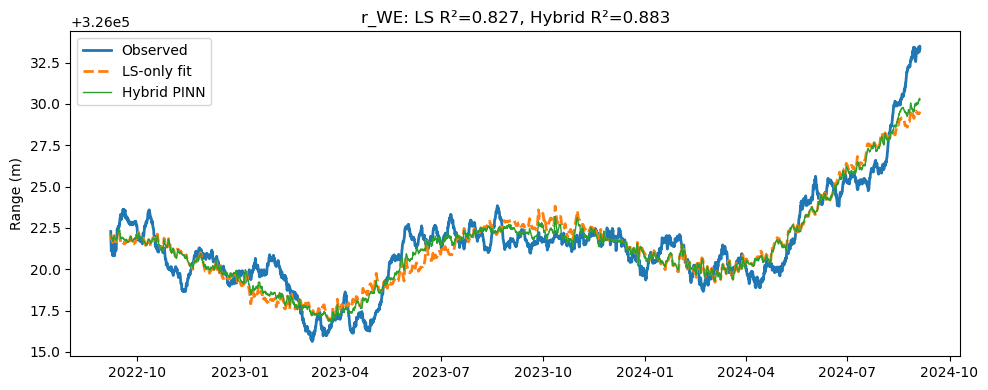

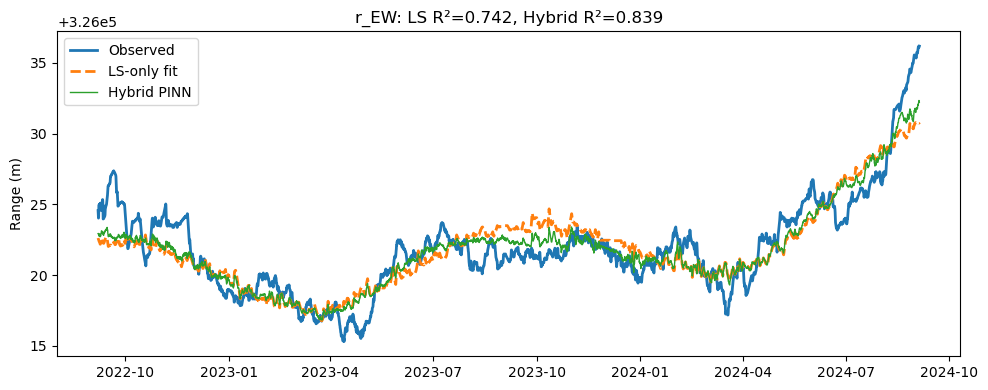

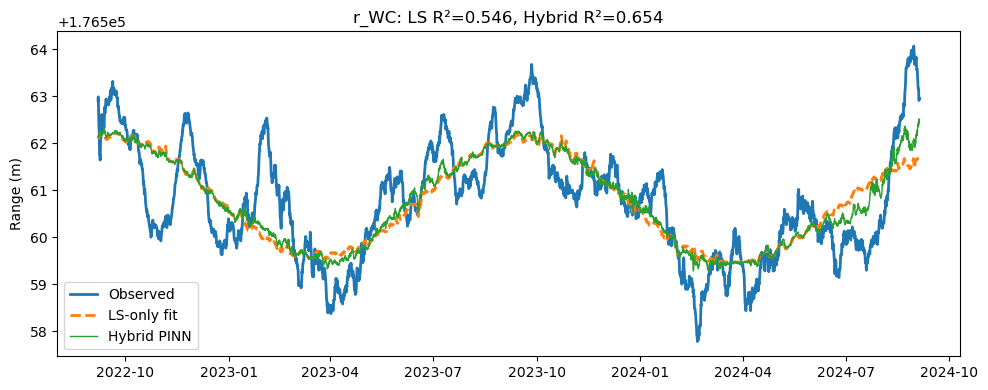

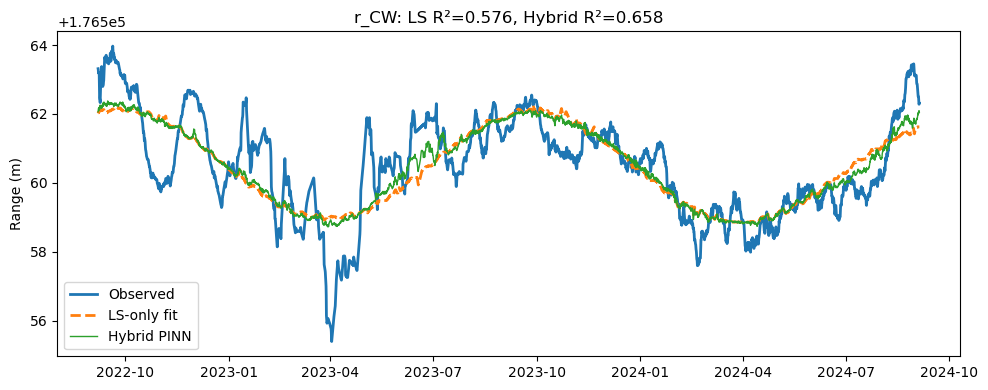

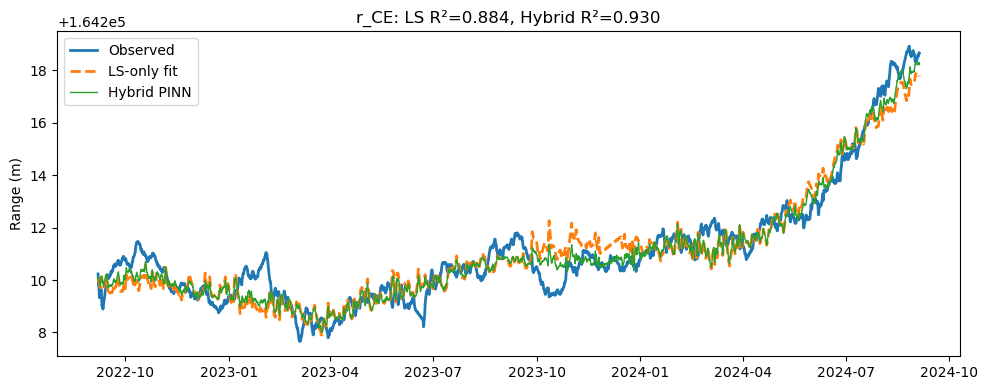

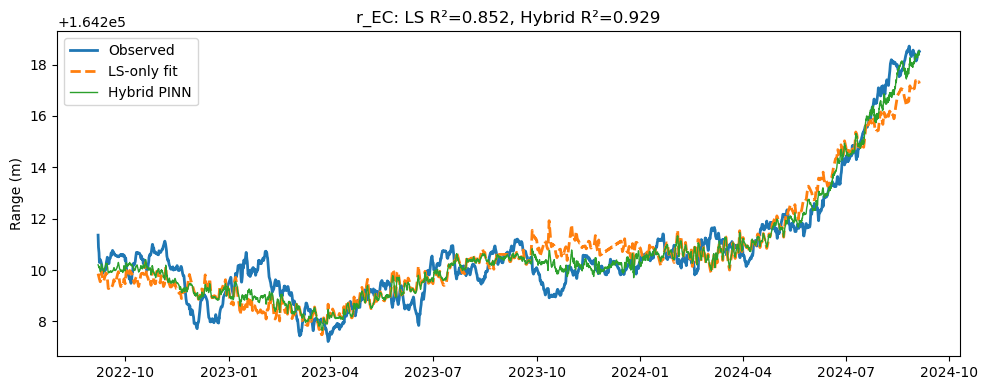

In [77]:
# 10) VISUALIZE
for i,name in enumerate(Y_cols):
    fig, ax = plt.subplots(figsize=(10,4), tight_layout=True)
    ax.plot(times, R_true[:,i],        label='Observed',    lw=2)
    ax.plot(times, R_lin_aligned[:,i], label='LS-only fit', ls='--', lw=2)
    ax.plot(times, R_pred_full[:,i],   label='Hybrid PINN',  lw=1)
    ax.set_title(f"{name}: LS R²={r2_score(R_true[:,i], R_lin_aligned[:,i]):.3f}, "
                 f"Hybrid R²={r2_score(R_true[:,i], R_pred_full[:,i]):.3f}")
    ax.set_ylabel("Range (m)")
    ax.legend()
    plt.show()


In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib, pathlib

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, Model, backend as K, callbacks

# =============================================================================
# THREE-HEAD LS+PINN HYBRID WITH STRICT HINGE LOSS (FULL-SERIES TRAINING)
# =============================================================================

# 0) LOAD, FILTER & CLEAN
df_var = df_var.dropna().reset_index(drop=True)
df_var['Record Time'] = pd.to_datetime(df_var['Record Time'], utc=True)
cutoff = pd.Timestamp(2022, 9, 7, tz='UTC')
df_var = df_var[df_var['Record Time'] >= cutoff].reset_index(drop=True)

# corrected mapping
df = pd.DataFrame({
    'time': df_var['Record Time'],
    'p1':   df_var['p1'],
    'p2':   df_var['p2'],
    'p3':   df_var['p3'],
    'r_WE': df_var['d1'],
    'r_EW': df_var['d2'],
    'r_EC': df_var['d3'],
    'r_CE': df_var['d4'],
    'r_WC': df_var['d5'],
    'r_CW': df_var['d6'],
})
Y_cols = ['r_WE','r_EW','r_WC','r_CW','r_CE','r_EC']

# 1) TIME & SEASONAL FEATURES
t0     = df['time'].min()
df['t_days'] = (df['time'] - t0).dt.total_seconds() / 86400.0
ω      = 2 * np.pi / 365.25
df['sin1'] = np.sin(ω * df['t_days'])
df['cos1'] = np.cos(ω * df['t_days'])

# standardize pressures for LS block
p1_std = (df['p1'] - df['p1'].mean()) / df['p1'].std()
p2_std = (df['p2'] - df['p2'].mean()) / df['p2'].std()

sin_t  = df['sin1'].values
cos_t  = df['cos1'].values

# 2) LEAST-SQUARES BLOCKS
A_CE = np.column_stack([np.ones_like(p2_std), p2_std, sin_t, cos_t])
x_CE, *_ = np.linalg.lstsq(A_CE, df['r_CE'], rcond=None)
x_EC, *_ = np.linalg.lstsq(A_CE, df['r_EC'], rcond=None)
r_CE_lin = A_CE @ x_CE
r_EC_lin = A_CE @ x_EC

A_CW = np.column_stack([np.ones_like(p1_std), p1_std, sin_t, cos_t])
x_CW, *_ = np.linalg.lstsq(A_CW, df['r_CW'], rcond=None)
x_WC, *_ = np.linalg.lstsq(A_CW, df['r_WC'], rcond=None)
r_CW_lin = A_CW @ x_CW
r_WC_lin = A_CW @ x_WC

A_EW = np.column_stack([np.ones_like(p1_std), p1_std, p2_std, sin_t, cos_t])
x_EW, *_ = np.linalg.lstsq(A_EW, df['r_EW'], rcond=None)
x_WE, *_ = np.linalg.lstsq(A_EW, df['r_WE'], rcond=None)
r_EW_lin = A_EW @ x_EW
r_WE_lin = A_EW @ x_WE

R_lin = np.column_stack([
    r_WE_lin, r_EW_lin, r_WC_lin,
    r_CW_lin, r_CE_lin, r_EC_lin
]).astype('float32')

# 3) TRUE RESIDUALS
R_obs   = df[Y_cols].values.astype('float32')
R_resid = (R_obs - R_lin).astype('float32')

# 4) FEATURES + LAGS + LS FIT inputs
df_feat = df[['p1','p2','p3','t_days','sin1','cos1']].copy()
for lag in (1,2,3):
    df_feat[f'p1_l{lag}'] = df['p1'].shift(lag)
    df_feat[f'p2_l{lag}'] = df['p2'].shift(lag)
    df_feat[f'p3_l{lag}'] = df['p3'].shift(lag)
# add LS fits
for name, arr in zip(['r_WE_lin','r_EW_lin','r_WC_lin','r_CW_lin','r_CE_lin','r_EC_lin'],
                     [r_WE_lin, r_EW_lin, r_WC_lin, r_CW_lin, r_CE_lin, r_EC_lin]):
    df_feat[name] = arr

df_feat.dropna(inplace=True)
df_feat.reset_index(drop=True, inplace=True)

idx           = df_feat.index.values
X_raw         = df_feat.values.astype('float32')
R_resid_true  = R_resid[idx]
R_lin_aligned = R_lin[idx]
R_true        = R_obs[idx]
times         = df['time'].values[idx]

# 5) SCALE
scaler_X      = StandardScaler().fit(X_raw)
Xs            = scaler_X.transform(X_raw)
scaler_R      = StandardScaler().fit(R_resid_true)
Rs_scaled     = scaler_R.transform(R_resid_true)
mean_R        = K.constant(scaler_R.mean_.reshape((1,6)), dtype='float32')
scale_R       = K.constant(scaler_R.scale_.reshape((1,6)), dtype='float32')

# 6) BUILD 3-HEAD RESIDUAL PINN
inp = layers.Input(shape=(Xs.shape[1],))
shared = layers.Dense(64, activation='relu')(inp)
shared = layers.Dense(64, activation='relu')(shared)

cols = df_feat.columns.tolist()
east_idx = [cols.index('r_CE_lin'), cols.index('r_EC_lin')]
west_idx = [cols.index('r_CW_lin'), cols.index('r_WC_lin')]
mid_idx  = [cols.index('r_WE_lin'), cols.index('r_EW_lin')]

def gather(idx):
    return layers.Lambda(lambda x: tf.gather(x, idx, axis=1))

# East head
e = gather(east_idx)(inp)
eh= layers.Concatenate()([shared, e])
eh= layers.Dense(32, activation='relu')(eh)
r_CE_p = layers.Dense(1)(eh); r_EC_p = layers.Dense(1)(eh)

# West head
w = gather(west_idx)(inp)
wh= layers.Concatenate()([shared, w])
wh= layers.Dense(32, activation='relu')(wh)
r_CW_p = layers.Dense(1)(wh); r_WC_p = layers.Dense(1)(wh)

# Mid head
m = gather(mid_idx)(inp)
mh= layers.Concatenate()([shared, m])
mh= layers.Dense(32, activation='relu')(mh)
r_WE_p = layers.Dense(1)(mh); r_EW_p = layers.Dense(1)(mh)

resid_out = layers.Concatenate()([r_WE_p, r_EW_p, r_WC_p, r_CW_p, r_CE_p, r_EC_p])
res_model = Model(inp, resid_out, name='residual_PINN')

# custom strict hinge loss
def pinn_loss_strict(r_true_s, r_pred_s):
    r_true_m = r_true_s * scale_R + mean_R
    r_pred_m = r_pred_s * scale_R + mean_R
    L_mse    = K.mean(K.square(r_true_s - r_pred_s))
    CE, EC   = r_pred_s[:,4], r_pred_s[:,5]
    CW, WC   = r_pred_s[:,3], r_pred_s[:,2]
    L_sym    = K.mean(K.square(CE-EC)+K.square(CW-WC))
    dCE      = CE[1:]-CE[:-1]; dCW = CW[1:]-CW[:-1]
    dEW      = r_pred_s[1:,1]-r_pred_s[:-1,1]
    L_clo    = K.mean(K.square(dCE + dCW - dEW))
    delta    = K.square(r_true_m - r_pred_m) - K.square(r_true_m)
    L_bound  = K.mean(K.maximum(delta, 0.0))
    return 1.0*L_mse + 0.1*L_sym + 0.1*L_clo + 10.0*L_bound

res_model.compile(optimizer='adam', loss=pinn_loss_strict)

# 7) TRAIN on full series
es = callbacks.EarlyStopping(monitor='loss', patience=30, restore_best_weights=True)
res_model.fit(Xs, Rs_scaled, epochs=300, batch_size=len(Xs), callbacks=[es], verbose=1)

# 8) PREDICT & RECONSTRUCT
Rs_pred_s   = res_model.predict(Xs)
Rs_pred     = scaler_R.inverse_transform(Rs_pred_s)
R_pred_full = R_lin_aligned + Rs_pred

# 9) EVALUATE
print("LS-only metrics:")
for i,name in enumerate(Y_cols):
    r2_lin = r2_score(R_true[:,i], R_lin_aligned[:,i])
    rmse_lin = mean_squared_error(R_true[:,i], R_lin_aligned[:,i], squared=False)
    print(f"{name}: R²={r2_lin:.3f}, RMSE={rmse_lin:.3f} m")

print("\nHybrid 3-head PINN metrics:")
for i,name in enumerate(Y_cols):
    r2_h = r2_score(R_true[:,i], R_pred_full[:,i])
    rmse_h = mean_squared_error(R_true[:,i], R_pred_full[:,i], squared=False)
    print(f"{name}: R²={r2_h:.3f}, RMSE={rmse_h:.3f} m")



Epoch 1/300
1/1 [==============================] - 1s 1s/step - loss: 4.4326
Epoch 2/300
1/1 [==============================] - 0s 8ms/step - loss: 3.4193
Epoch 3/300
1/1 [==============================] - 0s 9ms/step - loss: 2.6648
Epoch 4/300
1/1 [==============================] - 0s 8ms/step - loss: 2.2078
Epoch 5/300
1/1 [==============================] - 0s 8ms/step - loss: 1.9612
Epoch 6/300
1/1 [==============================] - 0s 8ms/step - loss: 1.8548
Epoch 7/300
1/1 [==============================] - 0s 8ms/step - loss: 1.7617
Epoch 8/300
1/1 [==============================] - 0s 8ms/step - loss: 1.6796
Epoch 9/300
1/1 [==============================] - 0s 8ms/step - loss: 1.6319
Epoch 10/300
1/1 [==============================] - 0s 8ms/step - loss: 1.5960
Epoch 11/300
1/1 [==============================] - 0s 8ms/step - loss: 1.5652
Epoch 12/300
1/1 [==============================] - 0s 8ms/step - loss: 1.5215
Epoch 13/300
1/1 [==============================] - 0s 8ms/ste

1/1 [==============================] - 0s 8ms/step - loss: 0.8938
Epoch 105/300
1/1 [==============================] - 0s 8ms/step - loss: 0.8924
Epoch 106/300
1/1 [==============================] - 0s 8ms/step - loss: 0.8908
Epoch 107/300
1/1 [==============================] - 0s 8ms/step - loss: 0.8891
Epoch 108/300
1/1 [==============================] - 0s 8ms/step - loss: 0.8877
Epoch 109/300
1/1 [==============================] - 0s 8ms/step - loss: 0.8861
Epoch 110/300
1/1 [==============================] - 0s 7ms/step - loss: 0.8845
Epoch 111/300
1/1 [==============================] - 0s 11ms/step - loss: 0.8829
Epoch 112/300
1/1 [==============================] - 0s 8ms/step - loss: 0.8814
Epoch 113/300
1/1 [==============================] - 0s 8ms/step - loss: 0.8798
Epoch 114/300
1/1 [==============================] - 0s 8ms/step - loss: 0.8782
Epoch 115/300
1/1 [==============================] - 0s 8ms/step - loss: 0.8765
Epoch 116/300
1/1 [==============================] - 

1/1 [==============================] - 0s 8ms/step - loss: 0.7241
Epoch 207/300
1/1 [==============================] - 0s 8ms/step - loss: 0.7222
Epoch 208/300
1/1 [==============================] - 0s 7ms/step - loss: 0.7209
Epoch 209/300
1/1 [==============================] - 0s 8ms/step - loss: 0.7197
Epoch 210/300
1/1 [==============================] - 0s 7ms/step - loss: 0.7182
Epoch 211/300
1/1 [==============================] - 0s 8ms/step - loss: 0.7161
Epoch 212/300
1/1 [==============================] - 0s 8ms/step - loss: 0.7138
Epoch 213/300
1/1 [==============================] - 0s 8ms/step - loss: 0.7125
Epoch 214/300
1/1 [==============================] - 0s 8ms/step - loss: 0.7116
Epoch 215/300
1/1 [==============================] - 0s 8ms/step - loss: 0.7094
Epoch 216/300
1/1 [==============================] - 0s 8ms/step - loss: 0.7085
Epoch 217/300
1/1 [==============================] - 0s 8ms/step - loss: 0.7068
Epoch 218/300
1/1 [==============================] - 0

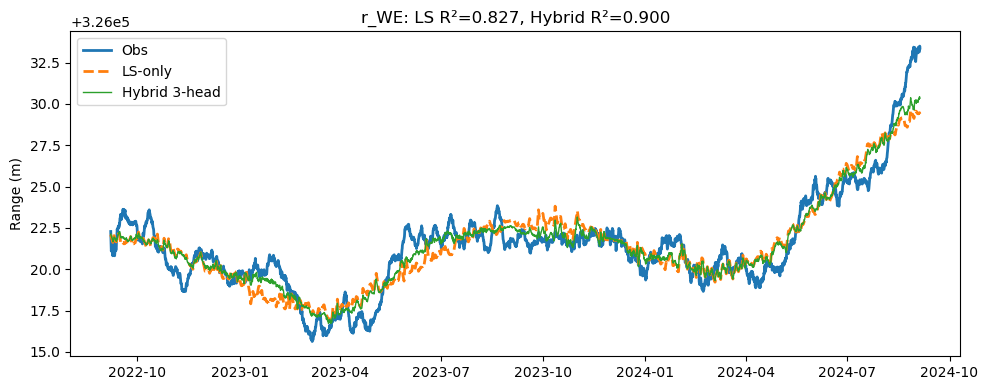

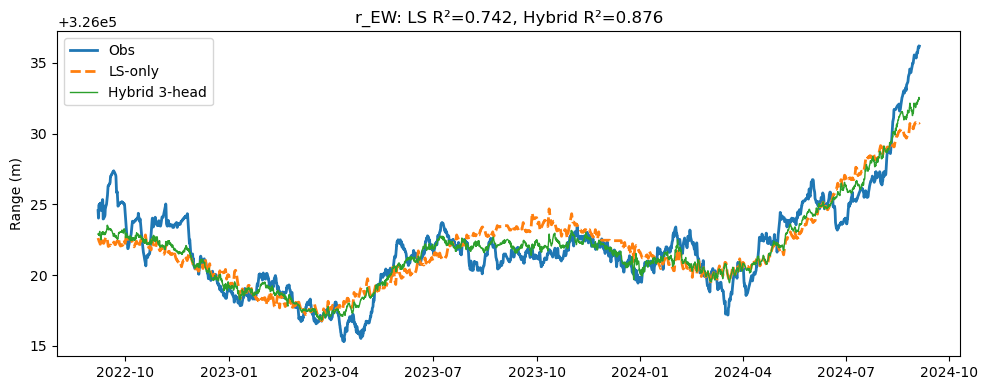

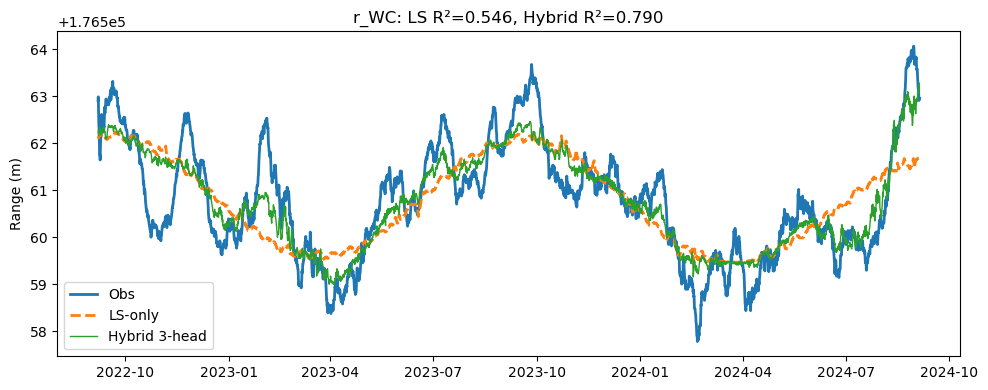

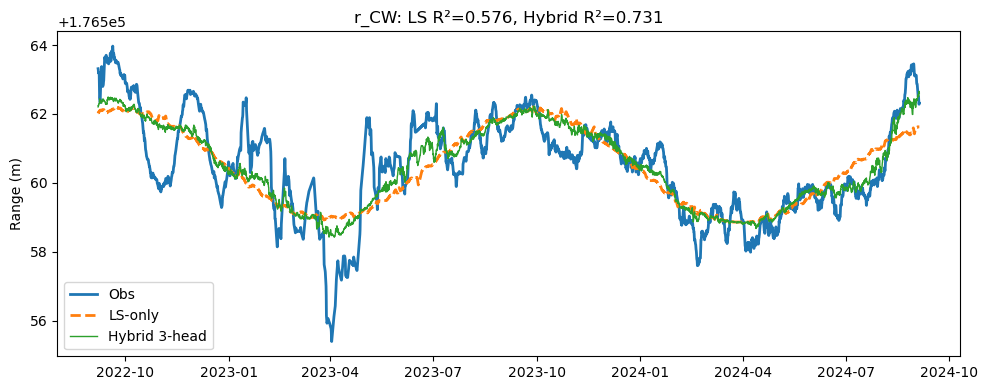

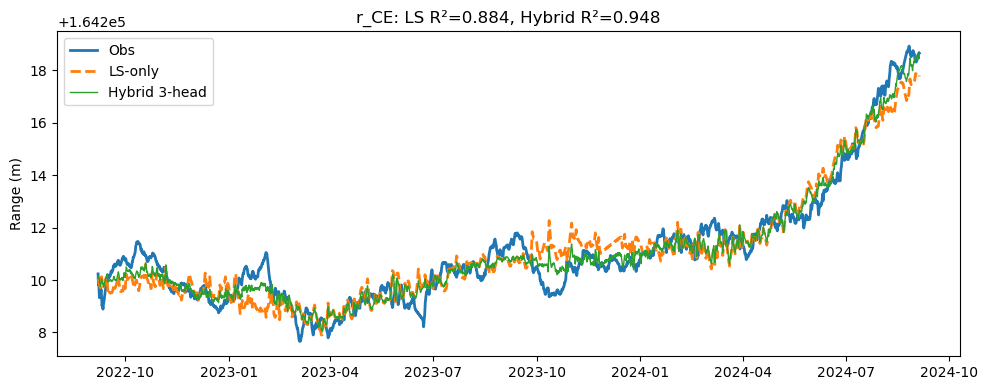

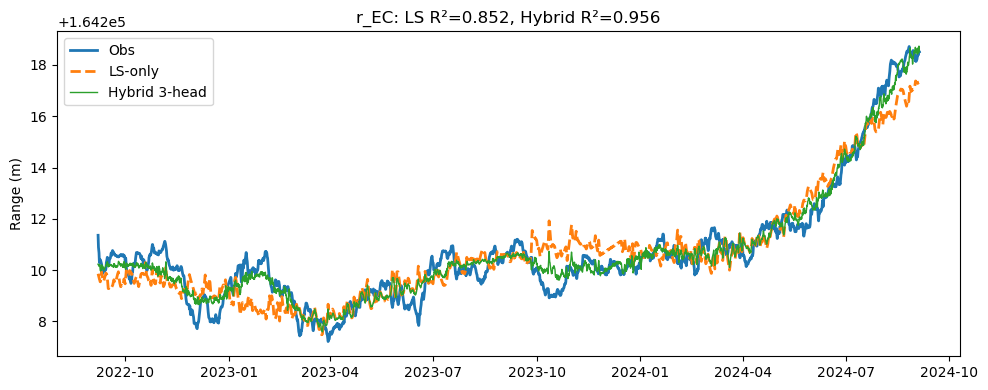

In [79]:
# 10) PLOT with LS and Hybrid
for i,name in enumerate(Y_cols):
    fig, ax = plt.subplots(figsize=(10,4), tight_layout=True)
    ax.plot(times, R_true[:,i], label='Obs', lw=2)
    ax.plot(times, R_lin_aligned[:,i], label='LS-only', ls='--', lw=2)
    ax.plot(times, R_pred_full[:,i], label='Hybrid 3-head', lw=1)
    ax.set_title(f"{name}: LS R²={r2_score(R_true[:,i], R_lin_aligned[:,i]):.3f}, "
                 f"Hybrid R²={r2_score(R_true[:,i], R_pred_full[:,i]):.3f}")
    ax.legend(); ax.set_ylabel("Range (m)")
    plt.show()

